Graphical Neural Network

**TEMPORAL EDGE**

**GCN**

In [ ]:
"""
gcn_clinical_bh_detector_ws20.py
══════════════════════════════════════════════════════════════════════════════
Definitive Clinical Graph Convolutional Network (GCN) for Breath-Hold prediction.
Dataset  : BH_DB_Features_WS20.csv  (window size = 20 s, step = 1 s, FS = 250 Hz)
Protocol : Leave-One-Subject-Out (LOSO) cross-validation

Architectural Upgrades:
  1. Temporal Edge Graph Construction: Time-series converted to PyG graphs.
  2. Balanced Batching: NeighborLoader + WeightedRandomSampler handles imbalance.
  3. Graph Convolution (GCNConv): Native message passing replaces median filters.
  4. Mandatory Scaling: Features are standard-scaled per fold.
  
Clinical Filters (Carried over):
  1. Optimized 8-Feature List (Zero Multicollinearity / VIF < 5)
  2. Feature winsorising at training P1–P99 per fold (No leakage)
  3. Clinical Minimum Duration Enforcement (BH ≥ 5s, DB ≥ 3s)
══════════════════════════════════════════════════════════════════════════════
"""

import os
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from torch.nn import Linear, CrossEntropyLoss
from torch.utils.data import WeightedRandomSampler
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GCNConv
from torch_geometric.loader import NeighborLoader

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    accuracy_score, confusion_matrix, roc_auc_score,
    average_precision_score,
)

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# ❶  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV    = "BH_DB_Features_WS20.csv"
RANDOM_SEED  = 42

# Ensure reproducibility across PyTorch operations
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

CLASS_MAP   = {"NB": 0, "BH": 1, "DB": 2}
CLASSES     = [0, 1, 2]
CLASS_NAMES = {0: "NB", 1: "BH", 2: "DB"}

# The WS20 Optimized Feature List
G_LIST = [
    "pNN50_Ratio", "pNN50_Delta", "HF_Ratio",                
    "RMSSD_Ratio", "Mean_RR_Ratio", "Shannon_Entropy_Ratio",   
    "EDR_Std_Amp_Ratio", "EDR_Mean_Amp_Delta"       
]

# GCN Hyperparameters
HIDDEN_DIM   = 64
EPOCHS       = 40
BATCH_SIZE   = 256
LEARNING_RATE= 0.005
WEIGHT_DECAY = 1e-4
K_NEIGHBORS  = 2     # Receptive field width (t ± 2)

WINSORISE  = True  
WINSOR_LO  = 0.01
WINSOR_HI  = 0.99

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# ─────────────────────────────────────────────────────────────────────────────
# ❷  DATA & GRAPH HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def winsorise_fold(X_tr: np.ndarray, X_te: np.ndarray, lo: float, hi: float):
    lo_vals = np.percentile(X_tr, lo * 100, axis=0)
    hi_vals = np.percentile(X_tr, hi * 100, axis=0)
    X_tr_c = np.clip(X_tr, lo_vals, hi_vals)
    X_te_c = np.clip(X_te, lo_vals, hi_vals)
    return X_tr_c, X_te_c

def enforce_minimum_duration(preds: np.ndarray, target_class: int, min_length: int) -> np.ndarray:
    filtered_preds = preds.copy()
    in_event = False
    start_idx = 0
    for i in range(len(filtered_preds)):
        if filtered_preds[i] == target_class and not in_event:
            in_event = True
            start_idx = i
        elif filtered_preds[i] != target_class and in_event:
            in_event = False
            if (i - start_idx) < min_length:
                filtered_preds[start_idx:i] = 0 
    if in_event and (len(filtered_preds) - start_idx) < min_length:
        filtered_preds[start_idx:] = 0
    return filtered_preds

def build_temporal_subject_graph(subject_df: pd.DataFrame, features: list, scaler: StandardScaler, is_train: bool = True) -> Data:
    """
    Converts a single subject's time-series into a PyTorch Geometric Graph.
    Connects window `t` to `t - k` and `t + k`.
    """
    df_sorted = subject_df.sort_values("Timestamp_Sec").reset_index(drop=True)
    
    X_raw = df_sorted[features].fillna(0).values
    
    # Fit/Transform the scaler ONLY if it's training data. Otherwise, just transform.
    if is_train:
        X_scaled = scaler.fit_transform(X_raw)
    else:
        X_scaled = scaler.transform(X_raw)
        
    X = torch.tensor(X_scaled, dtype=torch.float)
    y = torch.tensor(df_sorted["y"].values, dtype=torch.long)
    
    num_nodes = len(df_sorted)
    edge_sources = []
    edge_targets = []
    
    for i in range(num_nodes):
        start_idx = max(0, i - K_NEIGHBORS)
        end_idx = min(num_nodes, i + K_NEIGHBORS + 1)
        
        for j in range(start_idx, end_idx):
            if i != j:  
                edge_sources.append(i)
                edge_targets.append(j)
                
    edge_index = torch.tensor([edge_sources, edge_targets], dtype=torch.long)
    
    return Data(x=X, y=y, edge_index=edge_index)


def create_balanced_loader(train_graphs: list, batch_size: int) -> NeighborLoader:
    """
    Creates a PyG NeighborLoader using a WeightedRandomSampler to guarantee
    that every mini-batch has an equal representation of NB, BH, and DB nodes.
    """
    train_data = Batch.from_data_list(train_graphs)
    
    class_counts = torch.bincount(train_data.y)
    class_weights = 1.0 / class_counts.float()
    sample_weights = class_weights[train_data.y]
    
    sampler = WeightedRandomSampler(
        weights=sample_weights, 
        num_samples=len(train_data.y), 
        replacement=True
    )
    balanced_node_indices = torch.tensor(list(sampler), dtype=torch.long)
    
    loader = NeighborLoader(
        train_data,
        num_neighbors=[10, 10], # Sample up to 10 neighbors per hop (2 hops)
        batch_size=batch_size,
        input_nodes=balanced_node_indices,
        shuffle=False # Cannot shuffle when using a custom sampler
    )
    
    return loader


# ─────────────────────────────────────────────────────────────────────────────
# ❸  NETWORK ARCHITECTURE
# ─────────────────────────────────────────────────────────────────────────────

class ClinicalTemporalGCN(torch.nn.Module):
    def __init__(self, num_features: int, hidden_dim: int, num_classes: int):
        super().__init__()
        # Two message passing layers allow information to flow across t ± k
        self.conv1 = GCNConv(num_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        
        self.classifier = Linear(hidden_dim, num_classes)
        self.dropout = torch.nn.Dropout(p=0.3)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        out = self.classifier(x)
        return out


# ─────────────────────────────────────────────────────────────────────────────
# ❹  LOSO EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

def run_clinical_gcn_loso(df: pd.DataFrame, features: list) -> None:
    subjects = sorted(df["Subject"].unique())

    all_y_true, all_y_prob, all_y_pred = [], [], []

    print("\n" + "═" * 115)
    print(f"  CLINICAL LOSO EVALUATION: TEMPORAL GCN (k={K_NEIGHBORS}) | DEVICE: {DEVICE}")
    print("  Balanced NeighborLoader Batching + CrossEntropy Loss")
    print("═" * 115)

    header = (
        f"  {'Sub':6s} | {'N_NB':>5} | {'N_BH':>5} | {'N_DB':>5} | "
        f"{'Acc':>5} | {'Mac_P':>5} | {'Mac_R':>5} | {'Mac_F1':>6} | "
        f"{'BH_Rec':>6} | {'BH_Pre':>6} | {'BH_F1':>6}"
    )
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:

        tr_df = df[df["Subject"] != test_sub].copy()
        te_df = df[df["Subject"] == test_sub].copy()

        # ── 1. Winsorise ──
        if WINSORISE:
            X_tr_raw = tr_df[features].values
            X_te_raw = te_df[features].values
            X_tr_w, X_te_w = winsorise_fold(X_tr_raw, X_te_raw, WINSOR_LO, WINSOR_HI)
            tr_df.loc[:, features] = X_tr_w
            te_df.loc[:, features] = X_te_w

        # ── 2. Graph Construction ──
        scaler = StandardScaler()
        
        train_graphs = []
        for sub in tr_df["Subject"].unique():
            sub_df = tr_df[tr_df["Subject"] == sub]
            # First subject fits the scaler, rest transform
            is_first = (sub == tr_df["Subject"].unique()[0])
            train_graphs.append(build_temporal_subject_graph(sub_df, features, scaler, is_train=is_first))
            
        # Test graph uses the pre-fitted scaler
        test_graph = build_temporal_subject_graph(te_df, features, scaler, is_train=False).to(DEVICE)

        # ── 3. Balanced Dataloader ──
        train_loader = create_balanced_loader(train_graphs, BATCH_SIZE)

        # ── 4. Initialize GCN ──
        model = ClinicalTemporalGCN(num_features=len(features), hidden_dim=HIDDEN_DIM, num_classes=3).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        
        # Loss is unweighted because the WeightedRandomSampler guarantees balanced batches
        criterion = CrossEntropyLoss()

        # ── 5. Training Loop ──
        model.train()
        for epoch in range(EPOCHS):
            for batch in train_loader:
                batch = batch.to(DEVICE)
                optimizer.zero_grad()
                out = model(batch.x, batch.edge_index)
                
                # Only calculate loss on the target nodes (ignoring the pulled neighbors)
                loss = criterion(out[:batch.batch_size], batch.y[:batch.batch_size])
                loss.backward()
                optimizer.step()

        # ── 6. Evaluation ──
        model.eval()
        with torch.no_grad():
            out = model(test_graph.x, test_graph.edge_index)
            # Convert raw logits to probabilities
            probs = F.softmax(out, dim=1).cpu().numpy()
            raw_preds = np.argmax(probs, axis=1)

        # ── 7. Clinical Minimum Duration Filter ──
        # GCN natively smooths, so we skip the Median filter and only apply physical limits
        pred_cal = enforce_minimum_duration(raw_preds, target_class=1, min_length=5)
        pred_cal = enforce_minimum_duration(pred_cal, target_class=2, min_length=3)

        y_te = test_graph.y.cpu().numpy()

        # ── 8. Per-subject metrics ──
        n_nb = int((y_te == 0).sum())
        n_bh = int((y_te == 1).sum())
        n_db = int((y_te == 2).sum())

        acc     = accuracy_score(y_te, pred_cal)
        mac_p   = precision_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_r   = recall_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_f1  = f1_score(y_te, pred_cal, average="macro", zero_division=0)

        bh_rec  = recall_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_pre  = precision_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_f1   = f1_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]

        print(
            f"  {test_sub:6s} | {n_nb:5d} | {n_bh:5d} | {n_db:5d} | "
            f"{acc:5.3f} | {mac_p:5.3f} | {mac_r:5.3f} | {mac_f1:6.3f} | "
            f"{bh_rec:6.3f} | {bh_pre:6.3f} | {bh_f1:6.3f}"
        )

        all_y_true.extend(y_te.tolist())
        all_y_prob.extend(probs.tolist())
        all_y_pred.extend(pred_cal.tolist())

    # ── Overall metrics ───────────────────────────────────────────────────────
    print("  " + "─" * (len(header) - 2))

    y_true = np.array(all_y_true)
    y_prob = np.array(all_y_prob)
    y_pred = np.array(all_y_pred)

    y_bin = label_binarize(y_true, classes=CLASSES)

    auroc = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    auprc = average_precision_score(y_bin, y_prob, average="macro")

    acc     = accuracy_score(y_true, y_pred)
    mac_p   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    mac_r   = recall_score(y_true, y_pred, average="macro", zero_division=0)
    mac_f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)

    bh_rec  = recall_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_pre  = precision_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_f1   = f1_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]

    db_rec  = recall_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_pre  = precision_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_f1   = f1_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]

    nb_rec  = recall_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]
    nb_pre  = precision_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]

    print()
    print("  ── GCN OVERALL RESULTS (MACRO AVERAGED) ──")
    print(f"     AUROC (OVR)     = {auroc:.4f}")
    print(f"     AUPRC           = {auprc:.4f}")
    print(f"     Accuracy        = {acc:.4f}")
    print(f"     Macro Precision = {mac_p:.4f}")
    print(f"     Macro Recall    = {mac_r:.4f}")
    print(f"     Macro F1        = {mac_f1:.4f}")
    print()
    print("  ── PER-CLASS BREAKDOWN ──")
    print(f"     NB  : Recall={nb_rec:.3f}  Precision={nb_pre:.3f}")
    print(f"     BH  : Recall={bh_rec:.3f}  Precision={bh_pre:.3f}  F1={bh_f1:.3f}")
    print(f"     DB  : Recall={db_rec:.3f}  Precision={db_pre:.3f}  F1={db_f1:.3f}")

    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    print()
    print("  ── OVERALL CONFUSION MATRIX ──")
    print(f"  {'':20s}  {'Pred NB':>10}  {'Pred BH':>10}  {'Pred DB':>10}")
    for i, name in CLASS_NAMES.items():
        row = cm[i]
        print(f"  Actual {name} ({i})         {row[0]:>10}  {row[1]:>10}  {row[2]:>10}")
    print("═" * 115)


# ─────────────────────────────────────────────────────────────────────────────
# ❺  MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main() -> None:
    print("═" * 80)
    print("  CLINICAL TEMPORAL GCN PIPELINE: BH/DB PREDICTION (WS20)")
    print("═" * 80)

    if not os.path.exists(INPUT_CSV):
        raise FileNotFoundError(f"Dataset not found: {INPUT_CSV}")

    df = pd.read_csv(INPUT_CSV)
    df["y"] = df["Category"].map(CLASS_MAP)
    features = G_LIST

    total   = len(df)
    n_nb    = (df["y"] == 0).sum()
    n_bh    = (df["y"] == 1).sum()
    n_db    = (df["y"] == 2).sum()
    n_sub   = df["Subject"].nunique()

    print(f"\n  [+] Dataset overview : {total:,} windows | {n_sub} subjects")
    print(f"      NB = {n_nb:,} ({n_nb/total*100:.1f}%)")
    print(f"      BH = {n_bh:,} ({n_bh/total*100:.1f}%)")
    print(f"      DB = {n_db:,} ({n_db/total*100:.1f}%)")
    
    print(f"\n  [+] GCN Architecture Specifications:")
    print(f"      Features Locked      : {len(features)} (VIF Optimized G_LIST)")
    print(f"      Model Topology       : 2x GCNConv Layers (Hidden Dim = {HIDDEN_DIM})")
    print(f"      Graph Construction   : Temporal Edges (t ± {K_NEIGHBORS})")
    print(f"      Handling Imbalance   : NeighborLoader + WeightedRandomSampler")
    print(f"      Mandatory Scaling    : StandardScaler applied per-fold")

    # Execute
    run_clinical_gcn_loso(df, features)


if __name__ == "__main__":
    main()

c:\Users\ejisg\anaconda3\envs\ecg\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


════════════════════════════════════════════════════════════════════════════════
  CLINICAL TEMPORAL GCN PIPELINE: BH/DB PREDICTION (WS20)
════════════════════════════════════════════════════════════════════════════════

  [+] Dataset overview : 28,090 windows | 41 subjects
      NB = 21,529 (76.6%)
      BH = 3,505 (12.5%)
      DB = 3,056 (10.9%)

  [+] GCN Architecture Specifications:
      Features Locked      : 8 (VIF Optimized G_LIST)
      Model Topology       : 2x GCNConv Layers (Hidden Dim = 64)
      Graph Construction   : Temporal Edges (t ± 2)
      Handling Imbalance   : NeighborLoader + WeightedRandomSampler
      Mandatory Scaling    : StandardScaler applied per-fold

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  CLINICAL LOSO EVALUATION: TEMPORAL GCN (k=2) | DEVICE: cuda
  Balanced NeighborLoader Batching + CrossEntropy Loss
═══════════════════════════════════════════════════════════════════════════

In [ ]:
"""
gcn_clinical_bh_detector_ws20_tversky.py
══════════════════════════════════════════════════════════════════════════════
Definitive Clinical Graph Convolutional Network (GCN) for Breath-Hold prediction.
Dataset  : BH_DB_Features_WS20.csv  (window size = 20 s, step = 1 s, FS = 250 Hz)
Protocol : Leave-One-Subject-Out (LOSO) cross-validation

Architectural Upgrades:
  1. Temporal Edge Graph Construction: Time-series converted to PyG graphs.
  2. Balanced Batching: NeighborLoader + WeightedRandomSampler handles imbalance.
  3. Focal Tversky Loss (FTL): Replaces standard Cross-Entropy to heavily 
     penalize False Negatives (missed BH events) and focus on hard boundaries.
  4. Graph Convolution (GCNConv): Native message passing replaces median filters.
══════════════════════════════════════════════════════════════════════════════
"""

import os
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.nn import Linear
from torch.utils.data import WeightedRandomSampler
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GCNConv
from torch_geometric.loader import NeighborLoader

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    accuracy_score, confusion_matrix, roc_auc_score,
    average_precision_score,
)

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# ❶  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV    = "BH_DB_Features_WS20.csv"
RANDOM_SEED  = 42

# Ensure reproducibility across PyTorch operations
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

CLASS_MAP   = {"NB": 0, "BH": 1, "DB": 2}
CLASSES     = [0, 1, 2]
CLASS_NAMES = {0: "NB", 1: "BH", 2: "DB"}

# The WS20 Optimized Feature List
G_LIST = [
    "pNN50_Ratio", "pNN50_Delta", "HF_Ratio",                
    "RMSSD_Ratio", "Mean_RR_Ratio", "Shannon_Entropy_Ratio",   
    "EDR_Std_Amp_Ratio", "EDR_Mean_Amp_Delta"       
]

# GCN Hyperparameters
HIDDEN_DIM   = 64
EPOCHS       = 40
BATCH_SIZE   = 256
LEARNING_RATE= 0.005
WEIGHT_DECAY = 1e-4
K_NEIGHBORS  = 2     # Receptive field width (t ± 2)

# Focal Tversky Hyperparameters
FTL_ALPHA    = 0.3   # Lower penalty for False Positives
FTL_BETA     = 0.7   # Higher penalty for False Negatives (Missed BH)
FTL_GAMMA    = 1.3   # Focal parameter to suppress easy examples

WINSORISE  = True  
WINSOR_LO  = 0.01
WINSOR_HI  = 0.99

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# ─────────────────────────────────────────────────────────────────────────────
# ❷  CUSTOM FOCAL TVERSKY LOSS
# ─────────────────────────────────────────────────────────────────────────────

class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha: float, beta: float, gamma: float, smooth: float = 1e-6):
        super(FocalTverskyLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        num_classes = logits.shape[1]
        targets_one_hot = F.one_hot(targets, num_classes=num_classes).float()
        
        total_loss = 0.0
        
        for c in range(num_classes):
            prob_c = probs[:, c]
            target_c = targets_one_hot[:, c]
            
            TP = (prob_c * target_c).sum()
            FP = ((1 - target_c) * prob_c).sum()
            FN = (target_c * (1 - prob_c)).sum()
            
            Tversky = (TP + self.smooth) / (TP + self.alpha * FP + self.beta * FN + self.smooth)
            FocalTversky = (1 - Tversky) ** self.gamma
            total_loss += FocalTversky
            
        return total_loss / num_classes


# ─────────────────────────────────────────────────────────────────────────────
# ❸  DATA & GRAPH HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def winsorise_fold(X_tr: np.ndarray, X_te: np.ndarray, lo: float, hi: float):
    lo_vals = np.percentile(X_tr, lo * 100, axis=0)
    hi_vals = np.percentile(X_tr, hi * 100, axis=0)
    X_tr_c = np.clip(X_tr, lo_vals, hi_vals)
    X_te_c = np.clip(X_te, lo_vals, hi_vals)
    return X_tr_c, X_te_c

def enforce_minimum_duration(preds: np.ndarray, target_class: int, min_length: int) -> np.ndarray:
    filtered_preds = preds.copy()
    in_event = False
    start_idx = 0
    for i in range(len(filtered_preds)):
        if filtered_preds[i] == target_class and not in_event:
            in_event = True
            start_idx = i
        elif filtered_preds[i] != target_class and in_event:
            in_event = False
            if (i - start_idx) < min_length:
                filtered_preds[start_idx:i] = 0 
    if in_event and (len(filtered_preds) - start_idx) < min_length:
        filtered_preds[start_idx:] = 0
    return filtered_preds

def build_temporal_subject_graph(subject_df: pd.DataFrame, features: list, scaler: StandardScaler, is_train: bool = True) -> Data:
    df_sorted = subject_df.sort_values("Timestamp_Sec").reset_index(drop=True)
    
    X_raw = df_sorted[features].fillna(0).values
    
    if is_train:
        X_scaled = scaler.fit_transform(X_raw)
    else:
        X_scaled = scaler.transform(X_raw)
        
    X = torch.tensor(X_scaled, dtype=torch.float)
    y = torch.tensor(df_sorted["y"].values, dtype=torch.long)
    
    num_nodes = len(df_sorted)
    edge_sources = []
    edge_targets = []
    
    for i in range(num_nodes):
        start_idx = max(0, i - K_NEIGHBORS)
        end_idx = min(num_nodes, i + K_NEIGHBORS + 1)
        for j in range(start_idx, end_idx):
            if i != j:  
                edge_sources.append(i)
                edge_targets.append(j)
                
    edge_index = torch.tensor([edge_sources, edge_targets], dtype=torch.long)
    return Data(x=X, y=y, edge_index=edge_index)


def create_balanced_loader(train_graphs: list, batch_size: int) -> NeighborLoader:
    train_data = Batch.from_data_list(train_graphs)
    
    class_counts = torch.bincount(train_data.y)
    class_weights = 1.0 / class_counts.float()
    sample_weights = class_weights[train_data.y]
    
    sampler = WeightedRandomSampler(
        weights=sample_weights, 
        num_samples=len(train_data.y), 
        replacement=True
    )
    balanced_node_indices = torch.tensor(list(sampler), dtype=torch.long)
    
    loader = NeighborLoader(
        train_data,
        num_neighbors=[10, 10], 
        batch_size=batch_size,
        input_nodes=balanced_node_indices,
        shuffle=False
    )
    return loader


# ─────────────────────────────────────────────────────────────────────────────
# ❹  NETWORK ARCHITECTURE
# ─────────────────────────────────────────────────────────────────────────────

class ClinicalTemporalGCN(torch.nn.Module):
    def __init__(self, num_features: int, hidden_dim: int, num_classes: int):
        super().__init__()
        self.conv1 = GCNConv(num_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.classifier = Linear(hidden_dim, num_classes)
        self.dropout = torch.nn.Dropout(p=0.3)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        out = self.classifier(x)
        return out


# ─────────────────────────────────────────────────────────────────────────────
# ❺  LOSO EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

def run_clinical_gcn_loso(df: pd.DataFrame, features: list) -> None:
    subjects = sorted(df["Subject"].unique())
    all_y_true, all_y_prob, all_y_pred = [], [], []

    print("\n" + "═" * 115)
    print(f"  CLINICAL LOSO EVALUATION: TEMPORAL GCN (k={K_NEIGHBORS}) | DEVICE: {DEVICE}")
    print(f"  Balanced NeighborLoader Batching + Focal Tversky Loss (\u03B1={FTL_ALPHA}, \u03B2={FTL_BETA}, \u03B3={FTL_GAMMA})")
    print("═" * 115)

    header = (
        f"  {'Sub':6s} | {'N_NB':>5} | {'N_BH':>5} | {'N_DB':>5} | "
        f"{'Acc':>5} | {'Mac_P':>5} | {'Mac_R':>5} | {'Mac_F1':>6} | "
        f"{'BH_Rec':>6} | {'BH_Pre':>6} | {'BH_F1':>6}"
    )
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:

        tr_df = df[df["Subject"] != test_sub].copy()
        te_df = df[df["Subject"] == test_sub].copy()

        # ── 1. Winsorise ──
        if WINSORISE:
            X_tr_raw = tr_df[features].values
            X_te_raw = te_df[features].values
            X_tr_w, X_te_w = winsorise_fold(X_tr_raw, X_te_raw, WINSOR_LO, WINSOR_HI)
            tr_df.loc[:, features] = X_tr_w
            te_df.loc[:, features] = X_te_w

        # ── 2. Graph Construction ──
        scaler = StandardScaler()
        
        train_graphs = []
        for sub in tr_df["Subject"].unique():
            sub_df = tr_df[tr_df["Subject"] == sub]
            is_first = (sub == tr_df["Subject"].unique()[0])
            train_graphs.append(build_temporal_subject_graph(sub_df, features, scaler, is_train=is_first))
            
        test_graph = build_temporal_subject_graph(te_df, features, scaler, is_train=False).to(DEVICE)

        # ── 3. Balanced Dataloader ──
        train_loader = create_balanced_loader(train_graphs, BATCH_SIZE)

        # ── 4. Initialize GCN & Focal Tversky Loss ──
        model = ClinicalTemporalGCN(num_features=len(features), hidden_dim=HIDDEN_DIM, num_classes=3).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        
        criterion = FocalTverskyLoss(alpha=FTL_ALPHA, beta=FTL_BETA, gamma=FTL_GAMMA).to(DEVICE)

        # ── 5. Training Loop ──
        model.train()
        for epoch in range(EPOCHS):
            for batch in train_loader:
                batch = batch.to(DEVICE)
                optimizer.zero_grad()
                out = model(batch.x, batch.edge_index)
                
                # Calculate FTL only on the target nodes
                loss = criterion(out[:batch.batch_size], batch.y[:batch.batch_size])
                loss.backward()
                optimizer.step()

        # ── 6. Evaluation ──
        model.eval()
        with torch.no_grad():
            out = model(test_graph.x, test_graph.edge_index)
            probs = F.softmax(out, dim=1).cpu().numpy()
            raw_preds = np.argmax(probs, axis=1)

        # ── 7. Clinical Minimum Duration Filter ──
        pred_cal = enforce_minimum_duration(raw_preds, target_class=1, min_length=5)
        pred_cal = enforce_minimum_duration(pred_cal, target_class=2, min_length=3)

        y_te = test_graph.y.cpu().numpy()

        # ── 8. Per-subject metrics ──
        n_nb = int((y_te == 0).sum())
        n_bh = int((y_te == 1).sum())
        n_db = int((y_te == 2).sum())

        acc     = accuracy_score(y_te, pred_cal)
        mac_p   = precision_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_r   = recall_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_f1  = f1_score(y_te, pred_cal, average="macro", zero_division=0)

        bh_rec  = recall_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_pre  = precision_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_f1   = f1_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]

        print(
            f"  {test_sub:6s} | {n_nb:5d} | {n_bh:5d} | {n_db:5d} | "
            f"{acc:5.3f} | {mac_p:5.3f} | {mac_r:5.3f} | {mac_f1:6.3f} | "
            f"{bh_rec:6.3f} | {bh_pre:6.3f} | {bh_f1:6.3f}"
        )

        all_y_true.extend(y_te.tolist())
        all_y_prob.extend(probs.tolist())
        all_y_pred.extend(pred_cal.tolist())

    # ── Overall metrics ───────────────────────────────────────────────────────
    print("  " + "─" * (len(header) - 2))

    y_true = np.array(all_y_true)
    y_prob = np.array(all_y_prob)
    y_pred = np.array(all_y_pred)

    y_bin = label_binarize(y_true, classes=CLASSES)

    auroc = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    auprc = average_precision_score(y_bin, y_prob, average="macro")

    acc     = accuracy_score(y_true, y_pred)
    mac_p   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    mac_r   = recall_score(y_true, y_pred, average="macro", zero_division=0)
    mac_f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)

    bh_rec  = recall_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_pre  = precision_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_f1   = f1_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]

    db_rec  = recall_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_pre  = precision_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_f1   = f1_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]

    nb_rec  = recall_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]
    nb_pre  = precision_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]

    print()
    print("  ── GCN OVERALL RESULTS (MACRO AVERAGED) ──")
    print(f"     AUROC (OVR)     = {auroc:.4f}")
    print(f"     AUPRC           = {auprc:.4f}")
    print(f"     Accuracy        = {acc:.4f}")
    print(f"     Macro Precision = {mac_p:.4f}")
    print(f"     Macro Recall    = {mac_r:.4f}")
    print(f"     Macro F1        = {mac_f1:.4f}")
    print()
    print("  ── PER-CLASS BREAKDOWN ──")
    print(f"     NB  : Recall={nb_rec:.3f}  Precision={nb_pre:.3f}")
    print(f"     BH  : Recall={bh_rec:.3f}  Precision={bh_pre:.3f}  F1={bh_f1:.3f}")
    print(f"     DB  : Recall={db_rec:.3f}  Precision={db_pre:.3f}  F1={db_f1:.3f}")

    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    print()
    print("  ── OVERALL CONFUSION MATRIX ──")
    print(f"  {'':20s}  {'Pred NB':>10}  {'Pred BH':>10}  {'Pred DB':>10}")
    for i, name in CLASS_NAMES.items():
        row = cm[i]
        print(f"  Actual {name} ({i})         {row[0]:>10}  {row[1]:>10}  {row[2]:>10}")
    print("═" * 115)


# ─────────────────────────────────────────────────────────────────────────────
# ❻  MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main() -> None:
    print("═" * 80)
    print("  CLINICAL TEMPORAL GCN PIPELINE: BH/DB PREDICTION (WS20)")
    print("═" * 80)

    if not os.path.exists(INPUT_CSV):
        raise FileNotFoundError(f"Dataset not found: {INPUT_CSV}")

    df = pd.read_csv(INPUT_CSV)
    df["y"] = df["Category"].map(CLASS_MAP)
    features = G_LIST

    total   = len(df)
    n_nb    = (df["y"] == 0).sum()
    n_bh    = (df["y"] == 1).sum()
    n_db    = (df["y"] == 2).sum()
    n_sub   = df["Subject"].nunique()

    print(f"\n  [+] Dataset overview : {total:,} windows | {n_sub} subjects")
    print(f"      NB = {n_nb:,} ({n_nb/total*100:.1f}%)")
    print(f"      BH = {n_bh:,} ({n_bh/total*100:.1f}%)")
    print(f"      DB = {n_db:,} ({n_db/total*100:.1f}%)")
    
    print(f"\n  [+] GCN Architecture Specifications:")
    print(f"      Features Locked      : {len(features)} (VIF Optimized G_LIST)")
    print(f"      Model Topology       : 2x GCNConv Layers (Hidden Dim = {HIDDEN_DIM})")
    print(f"      Graph Construction   : Temporal Edges (t ± {K_NEIGHBORS})")
    print(f"      Handling Imbalance   : NeighborLoader + WeightedRandomSampler")
    print(f"      Loss Function        : Focal Tversky (\u03B1={FTL_ALPHA}, \u03B2={FTL_BETA}, \u03B3={FTL_GAMMA})")
    print(f"      Mandatory Scaling    : StandardScaler applied per-fold")

    # Execute
    run_clinical_gcn_loso(df, features)


if __name__ == "__main__":
    main()

════════════════════════════════════════════════════════════════════════════════
  CLINICAL TEMPORAL GCN PIPELINE: BH/DB PREDICTION (WS20)
════════════════════════════════════════════════════════════════════════════════

  [+] Dataset overview : 28,090 windows | 41 subjects
      NB = 21,529 (76.6%)
      BH = 3,505 (12.5%)
      DB = 3,056 (10.9%)

  [+] GCN Architecture Specifications:
      Features Locked      : 8 (VIF Optimized G_LIST)
      Model Topology       : 2x GCNConv Layers (Hidden Dim = 64)
      Graph Construction   : Temporal Edges (t ± 2)
      Handling Imbalance   : NeighborLoader + WeightedRandomSampler
      Loss Function        : Focal Tversky (α=0.3, β=0.7, γ=1.3)
      Mandatory Scaling    : StandardScaler applied per-fold

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  CLINICAL LOSO EVALUATION: TEMPORAL GCN (k=2) | DEVICE: cuda
  Balanced NeighborLoader Batching + Focal Tversky Loss (α=0.3, β

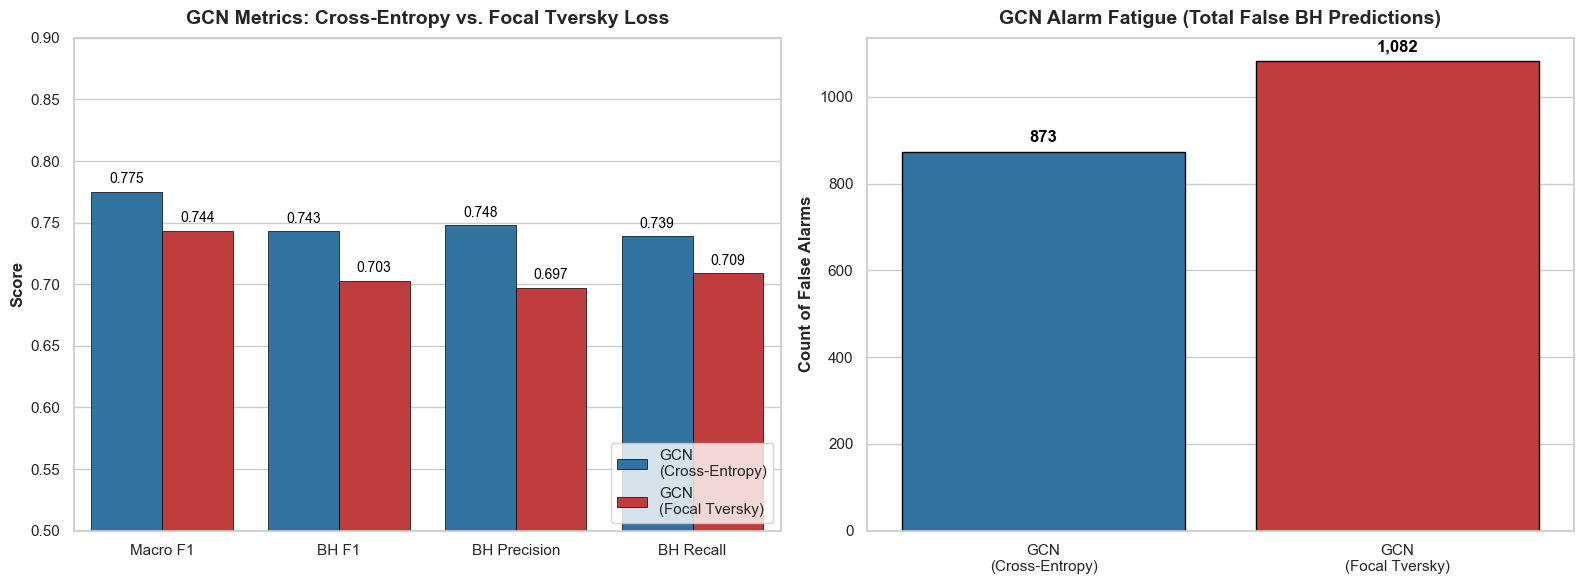

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_gcn_loss_comparison():
    # Data extracted exactly from your provided GCN logs
    data = {
        'Model': ['GCN\n(Cross-Entropy)', 'GCN\n(Focal Tversky)'],
        'Accuracy': [0.8661, 0.8431],
        'Macro F1': [0.7750, 0.7435],
        'BH Precision': [0.748, 0.697],
        'BH Recall': [0.739, 0.709],
        'BH F1': [0.743, 0.703],
        'False Alarms': [873, 1082] # (NB->BH + DB->BH) -> (692+181) vs (838+244)
    }

    df = pd.DataFrame(data)

    # Set plotting style
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(16, 6))

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 1: Predictive Metrics Comparison
    # ─────────────────────────────────────────────────────────────────────────────
    ax1 = plt.subplot(1, 2, 1)
    df_metrics = df[['Model', 'Macro F1', 'BH F1', 'BH Precision', 'BH Recall']].melt(id_vars='Model', var_name='Metric', value_name='Score')
    sns.barplot(data=df_metrics, x='Metric', y='Score', hue='Model', palette=['#1f77b4', '#d62728'], ax=ax1, edgecolor='black', linewidth=0.5)

    ax1.set_title('GCN Metrics: Cross-Entropy vs. Focal Tversky Loss', fontsize=14, fontweight='bold', pad=10)
    ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax1.set_xlabel('')
    ax1.set_ylim(0.50, 0.90)

    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 4), textcoords='offset points')
    ax1.legend(loc='lower right')

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 2: Alarm Fatigue (False Alarms)
    # ─────────────────────────────────────────────────────────────────────────────
    ax2 = plt.subplot(1, 2, 2)
    sns.barplot(data=df, x='Model', y='False Alarms', palette=['#1f77b4', '#d62728'], ax=ax2, edgecolor='black', linewidth=1)

    ax2.set_title('GCN Alarm Fatigue (Total False BH Predictions)', fontsize=14, fontweight='bold', pad=10)
    ax2.set_ylabel('Count of False Alarms', fontsize=12, fontweight='bold')
    ax2.set_xlabel('')

    for p in ax2.patches:
        ax2.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_gcn_loss_comparison()

In [ ]:
"""
gcn_clinical_bh_detector_ws20_combo.py
══════════════════════════════════════════════════════════════════════════════
Definitive Clinical Graph Convolutional Network (GCN) for Breath-Hold prediction.
Dataset  : BH_DB_Features_WS20.csv  (window size = 20 s, step = 1 s, FS = 250 Hz)
Protocol : Leave-One-Subject-Out (LOSO) cross-validation

Architectural Upgrades:
  1. Combo Loss (CE + FTL): Combines Cross-Entropy for overall accuracy and 
     Focal Tversky Loss to optimize temporal overlap and penalize False Negatives.
  2. Temporal Edge Graph Construction: Time-series converted to PyG graphs.
  3. Balanced Batching: NeighborLoader + WeightedRandomSampler handles imbalance.
  4. Graph Convolution (GCNConv): Native message passing replaces median filters.
══════════════════════════════════════════════════════════════════════════════
"""

import os
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.nn import Linear
from torch.utils.data import WeightedRandomSampler
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GCNConv
from torch_geometric.loader import NeighborLoader

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    accuracy_score, confusion_matrix, roc_auc_score,
    average_precision_score,
)

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# ❶  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV    = "BH_DB_Features_WS20.csv"
RANDOM_SEED  = 42

torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

CLASS_MAP   = {"NB": 0, "BH": 1, "DB": 2}
CLASSES     = [0, 1, 2]
CLASS_NAMES = {0: "NB", 1: "BH", 2: "DB"}

G_LIST = [
    "pNN50_Ratio", "pNN50_Delta", "HF_Ratio",                
    "RMSSD_Ratio", "Mean_RR_Ratio", "Shannon_Entropy_Ratio",   
    "EDR_Std_Amp_Ratio", "EDR_Mean_Amp_Delta"       
]

# GCN Hyperparameters
HIDDEN_DIM   = 64
EPOCHS       = 40
BATCH_SIZE   = 256
LEARNING_RATE= 0.005
WEIGHT_DECAY = 1e-4
K_NEIGHBORS  = 2     # Receptive field width (t ± 2)

# Combo Loss Hyperparameters
COMBO_ALPHA  = 0.5   # 50% CE, 50% FTL
FTL_ALPHA    = 0.3   # Penalty for False Positives
FTL_BETA     = 0.7   # Heavy penalty for False Negatives (Missed BH)
FTL_GAMMA    = 1.3   # Focal parameter

WINSORISE  = True  
WINSOR_LO  = 0.01
WINSOR_HI  = 0.99

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# ─────────────────────────────────────────────────────────────────────────────
# ❷  CUSTOM COMBO LOSS (CE + FTL)
# ─────────────────────────────────────────────────────────────────────────────

class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha: float, beta: float, gamma: float, smooth: float = 1e-6):
        super(FocalTverskyLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        num_classes = logits.shape[1]
        targets_one_hot = F.one_hot(targets, num_classes=num_classes).float()
        
        total_loss = 0.0
        for c in range(num_classes):
            prob_c = probs[:, c]
            target_c = targets_one_hot[:, c]
            
            TP = (prob_c * target_c).sum()
            FP = ((1 - target_c) * prob_c).sum()
            FN = (target_c * (1 - prob_c)).sum()
            
            Tversky = (TP + self.smooth) / (TP + self.alpha * FP + self.beta * FN + self.smooth)
            FocalTversky = (1 - Tversky) ** self.gamma
            total_loss += FocalTversky
            
        return total_loss / num_classes


class ComboLoss(nn.Module):
    """Combines Cross Entropy with Focal Tversky Loss"""
    def __init__(self, combo_alpha=0.5, ftl_alpha=0.3, ftl_beta=0.7, ftl_gamma=1.3):
        super(ComboLoss, self).__init__()
        self.combo_alpha = combo_alpha
        self.ce = nn.CrossEntropyLoss()
        self.ftl = FocalTverskyLoss(alpha=ftl_alpha, beta=ftl_beta, gamma=ftl_gamma)

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        ftl_loss = self.ftl(logits, targets)
        return (self.combo_alpha * ce_loss) + ((1 - self.combo_alpha) * ftl_loss)


# ─────────────────────────────────────────────────────────────────────────────
# ❸  DATA & GRAPH HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def winsorise_fold(X_tr: np.ndarray, X_te: np.ndarray, lo: float, hi: float):
    lo_vals = np.percentile(X_tr, lo * 100, axis=0)
    hi_vals = np.percentile(X_tr, hi * 100, axis=0)
    X_tr_c = np.clip(X_tr, lo_vals, hi_vals)
    X_te_c = np.clip(X_te, lo_vals, hi_vals)
    return X_tr_c, X_te_c

def enforce_minimum_duration(preds: np.ndarray, target_class: int, min_length: int) -> np.ndarray:
    filtered_preds = preds.copy()
    in_event = False
    start_idx = 0
    for i in range(len(filtered_preds)):
        if filtered_preds[i] == target_class and not in_event:
            in_event = True
            start_idx = i
        elif filtered_preds[i] != target_class and in_event:
            in_event = False
            if (i - start_idx) < min_length:
                filtered_preds[start_idx:i] = 0 
    if in_event and (len(filtered_preds) - start_idx) < min_length:
        filtered_preds[start_idx:] = 0
    return filtered_preds

def build_temporal_subject_graph(subject_df: pd.DataFrame, features: list, scaler: StandardScaler, is_train: bool = True) -> Data:
    df_sorted = subject_df.sort_values("Timestamp_Sec").reset_index(drop=True)
    X_raw = df_sorted[features].fillna(0).values
    
    if is_train:
        X_scaled = scaler.fit_transform(X_raw)
    else:
        X_scaled = scaler.transform(X_raw)
        
    X = torch.tensor(X_scaled, dtype=torch.float)
    y = torch.tensor(df_sorted["y"].values, dtype=torch.long)
    
    num_nodes = len(df_sorted)
    edge_sources = []
    edge_targets = []
    
    for i in range(num_nodes):
        start_idx = max(0, i - K_NEIGHBORS)
        end_idx = min(num_nodes, i + K_NEIGHBORS + 1)
        for j in range(start_idx, end_idx):
            if i != j:  
                edge_sources.append(i)
                edge_targets.append(j)
                
    edge_index = torch.tensor([edge_sources, edge_targets], dtype=torch.long)
    return Data(x=X, y=y, edge_index=edge_index)


def create_balanced_loader(train_graphs: list, batch_size: int) -> NeighborLoader:
    train_data = Batch.from_data_list(train_graphs)
    
    class_counts = torch.bincount(train_data.y)
    class_weights = 1.0 / class_counts.float()
    sample_weights = class_weights[train_data.y]
    
    sampler = WeightedRandomSampler(
        weights=sample_weights, 
        num_samples=len(train_data.y), 
        replacement=True
    )
    balanced_node_indices = torch.tensor(list(sampler), dtype=torch.long)
    
    loader = NeighborLoader(
        train_data,
        num_neighbors=[10, 10], 
        batch_size=batch_size,
        input_nodes=balanced_node_indices,
        shuffle=False 
    )
    
    return loader


# ─────────────────────────────────────────────────────────────────────────────
# ❹  NETWORK ARCHITECTURE
# ─────────────────────────────────────────────────────────────────────────────

class ClinicalTemporalGCN(torch.nn.Module):
    def __init__(self, num_features: int, hidden_dim: int, num_classes: int):
        super().__init__()
        self.conv1 = GCNConv(num_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        
        self.classifier = Linear(hidden_dim, num_classes)
        self.dropout = torch.nn.Dropout(p=0.3)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        out = self.classifier(x)
        return out


# ─────────────────────────────────────────────────────────────────────────────
# ❺  LOSO EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

def run_clinical_gcn_loso(df: pd.DataFrame, features: list) -> None:
    subjects = sorted(df["Subject"].unique())
    all_y_true, all_y_prob, all_y_pred = [], [], []

    print("\n" + "═" * 115)
    print(f"  CLINICAL LOSO EVALUATION: TEMPORAL GCN (k={K_NEIGHBORS}) | DEVICE: {DEVICE}")
    print(f"  Balanced NeighborLoader + Combo Loss ({int(COMBO_ALPHA*100)}% CE, {int((1-COMBO_ALPHA)*100)}% FTL)")
    print("═" * 115)

    header = (
        f"  {'Sub':6s} | {'N_NB':>5} | {'N_BH':>5} | {'N_DB':>5} | "
        f"{'Acc':>5} | {'Mac_P':>5} | {'Mac_R':>5} | {'Mac_F1':>6} | "
        f"{'BH_Rec':>6} | {'BH_Pre':>6} | {'BH_F1':>6}"
    )
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:
        tr_df = df[df["Subject"] != test_sub].copy()
        te_df = df[df["Subject"] == test_sub].copy()

        if WINSORISE:
            X_tr_raw = tr_df[features].values
            X_te_raw = te_df[features].values
            X_tr_w, X_te_w = winsorise_fold(X_tr_raw, X_te_raw, WINSOR_LO, WINSOR_HI)
            tr_df.loc[:, features] = X_tr_w
            te_df.loc[:, features] = X_te_w

        scaler = StandardScaler()
        
        train_graphs = []
        for sub in tr_df["Subject"].unique():
            sub_df = tr_df[tr_df["Subject"] == sub]
            is_first = (sub == tr_df["Subject"].unique()[0])
            train_graphs.append(build_temporal_subject_graph(sub_df, features, scaler, is_train=is_first))
            
        test_graph = build_temporal_subject_graph(te_df, features, scaler, is_train=False).to(DEVICE)
        train_loader = create_balanced_loader(train_graphs, BATCH_SIZE)

        model = ClinicalTemporalGCN(num_features=len(features), hidden_dim=HIDDEN_DIM, num_classes=3).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        
        # ── Utilize Combo Loss ──
        criterion = ComboLoss(
            combo_alpha=COMBO_ALPHA, 
            ftl_alpha=FTL_ALPHA, 
            ftl_beta=FTL_BETA, 
            ftl_gamma=FTL_GAMMA
        ).to(DEVICE)

        model.train()
        for epoch in range(EPOCHS):
            for batch in train_loader:
                batch = batch.to(DEVICE)
                optimizer.zero_grad()
                out = model(batch.x, batch.edge_index)
                
                loss = criterion(out[:batch.batch_size], batch.y[:batch.batch_size])
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            out = model(test_graph.x, test_graph.edge_index)
            probs = F.softmax(out, dim=1).cpu().numpy()
            raw_preds = np.argmax(probs, axis=1)

        pred_cal = enforce_minimum_duration(raw_preds, target_class=1, min_length=5)
        pred_cal = enforce_minimum_duration(pred_cal, target_class=2, min_length=3)

        y_te = test_graph.y.cpu().numpy()

        n_nb = int((y_te == 0).sum())
        n_bh = int((y_te == 1).sum())
        n_db = int((y_te == 2).sum())

        acc     = accuracy_score(y_te, pred_cal)
        mac_p   = precision_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_r   = recall_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_f1  = f1_score(y_te, pred_cal, average="macro", zero_division=0)

        bh_rec  = recall_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_pre  = precision_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_f1   = f1_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]

        print(
            f"  {test_sub:6s} | {n_nb:5d} | {n_bh:5d} | {n_db:5d} | "
            f"{acc:5.3f} | {mac_p:5.3f} | {mac_r:5.3f} | {mac_f1:6.3f} | "
            f"{bh_rec:6.3f} | {bh_pre:6.3f} | {bh_f1:6.3f}"
        )

        all_y_true.extend(y_te.tolist())
        all_y_prob.extend(probs.tolist())
        all_y_pred.extend(pred_cal.tolist())

    print("  " + "─" * (len(header) - 2))

    y_true = np.array(all_y_true)
    y_prob = np.array(all_y_prob)
    y_pred = np.array(all_y_pred)

    y_bin = label_binarize(y_true, classes=CLASSES)

    auroc = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    auprc = average_precision_score(y_bin, y_prob, average="macro")

    acc     = accuracy_score(y_true, y_pred)
    mac_p   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    mac_r   = recall_score(y_true, y_pred, average="macro", zero_division=0)
    mac_f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)

    bh_rec  = recall_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_pre  = precision_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_f1   = f1_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]

    db_rec  = recall_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_pre  = precision_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_f1   = f1_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]

    nb_rec  = recall_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]
    nb_pre  = precision_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]

    print()
    print("  ── GCN OVERALL RESULTS (MACRO AVERAGED) ──")
    print(f"     AUROC (OVR)     = {auroc:.4f}")
    print(f"     AUPRC           = {auprc:.4f}")
    print(f"     Accuracy        = {acc:.4f}")
    print(f"     Macro Precision = {mac_p:.4f}")
    print(f"     Macro Recall    = {mac_r:.4f}")
    print(f"     Macro F1        = {mac_f1:.4f}")
    print()
    print("  ── PER-CLASS BREAKDOWN ──")
    print(f"     NB  : Recall={nb_rec:.3f}  Precision={nb_pre:.3f}")
    print(f"     BH  : Recall={bh_rec:.3f}  Precision={bh_pre:.3f}  F1={bh_f1:.3f}")
    print(f"     DB  : Recall={db_rec:.3f}  Precision={db_pre:.3f}  F1={db_f1:.3f}")

    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    print()
    print("  ── OVERALL CONFUSION MATRIX ──")
    print(f"  {'':20s}  {'Pred NB':>10}  {'Pred BH':>10}  {'Pred DB':>10}")
    for i, name in CLASS_NAMES.items():
        row = cm[i]
        print(f"  Actual {name} ({i})         {row[0]:>10}  {row[1]:>10}  {row[2]:>10}")
    print("═" * 115)


# ─────────────────────────────────────────────────────────────────────────────
# ❻  MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main() -> None:
    print("═" * 80)
    print("  CLINICAL TEMPORAL GCN PIPELINE: BH/DB PREDICTION (WS20)")
    print("═" * 80)

    if not os.path.exists(INPUT_CSV):
        raise FileNotFoundError(f"Dataset not found: {INPUT_CSV}")

    df = pd.read_csv(INPUT_CSV)
    df["y"] = df["Category"].map(CLASS_MAP)
    features = G_LIST

    total   = len(df)
    n_nb    = (df["y"] == 0).sum()
    n_bh    = (df["y"] == 1).sum()
    n_db    = (df["y"] == 2).sum()
    n_sub   = df["Subject"].nunique()

    print(f"\n  [+] Dataset overview : {total:,} windows | {n_sub} subjects")
    print(f"      NB = {n_nb:,} ({n_nb/total*100:.1f}%)")
    print(f"      BH = {n_bh:,} ({n_bh/total*100:.1f}%)")
    print(f"      DB = {n_db:,} ({n_db/total*100:.1f}%)")
    
    print(f"\n  [+] GCN Architecture Specifications:")
    print(f"      Features Locked      : {len(features)} (VIF Optimized G_LIST)")
    print(f"      Model Topology       : 2x GCNConv Layers (Hidden Dim = {HIDDEN_DIM})")
    print(f"      Graph Construction   : Temporal Edges (t ± {K_NEIGHBORS})")
    print(f"      Handling Imbalance   : NeighborLoader + WeightedRandomSampler")
    print(f"      Loss Function        : Combo Loss ({int(COMBO_ALPHA*100)}% CE, {int((1-COMBO_ALPHA)*100)}% FTL)")
    print(f"      Mandatory Scaling    : StandardScaler applied per-fold")

    run_clinical_gcn_loso(df, features)


if __name__ == "__main__":
    main()

════════════════════════════════════════════════════════════════════════════════
  CLINICAL TEMPORAL GCN PIPELINE: BH/DB PREDICTION (WS20)
════════════════════════════════════════════════════════════════════════════════

  [+] Dataset overview : 28,090 windows | 41 subjects
      NB = 21,529 (76.6%)
      BH = 3,505 (12.5%)
      DB = 3,056 (10.9%)

  [+] GCN Architecture Specifications:
      Features Locked      : 8 (VIF Optimized G_LIST)
      Model Topology       : 2x GCNConv Layers (Hidden Dim = 64)
      Graph Construction   : Temporal Edges (t ± 2)
      Handling Imbalance   : NeighborLoader + WeightedRandomSampler
      Loss Function        : Combo Loss (50% CE, 50% FTL)
      Mandatory Scaling    : StandardScaler applied per-fold

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  CLINICAL LOSO EVALUATION: TEMPORAL GCN (k=2) | DEVICE: cuda
  Balanced NeighborLoader + Combo Loss (50% CE, 50% FTL)
═══════════════

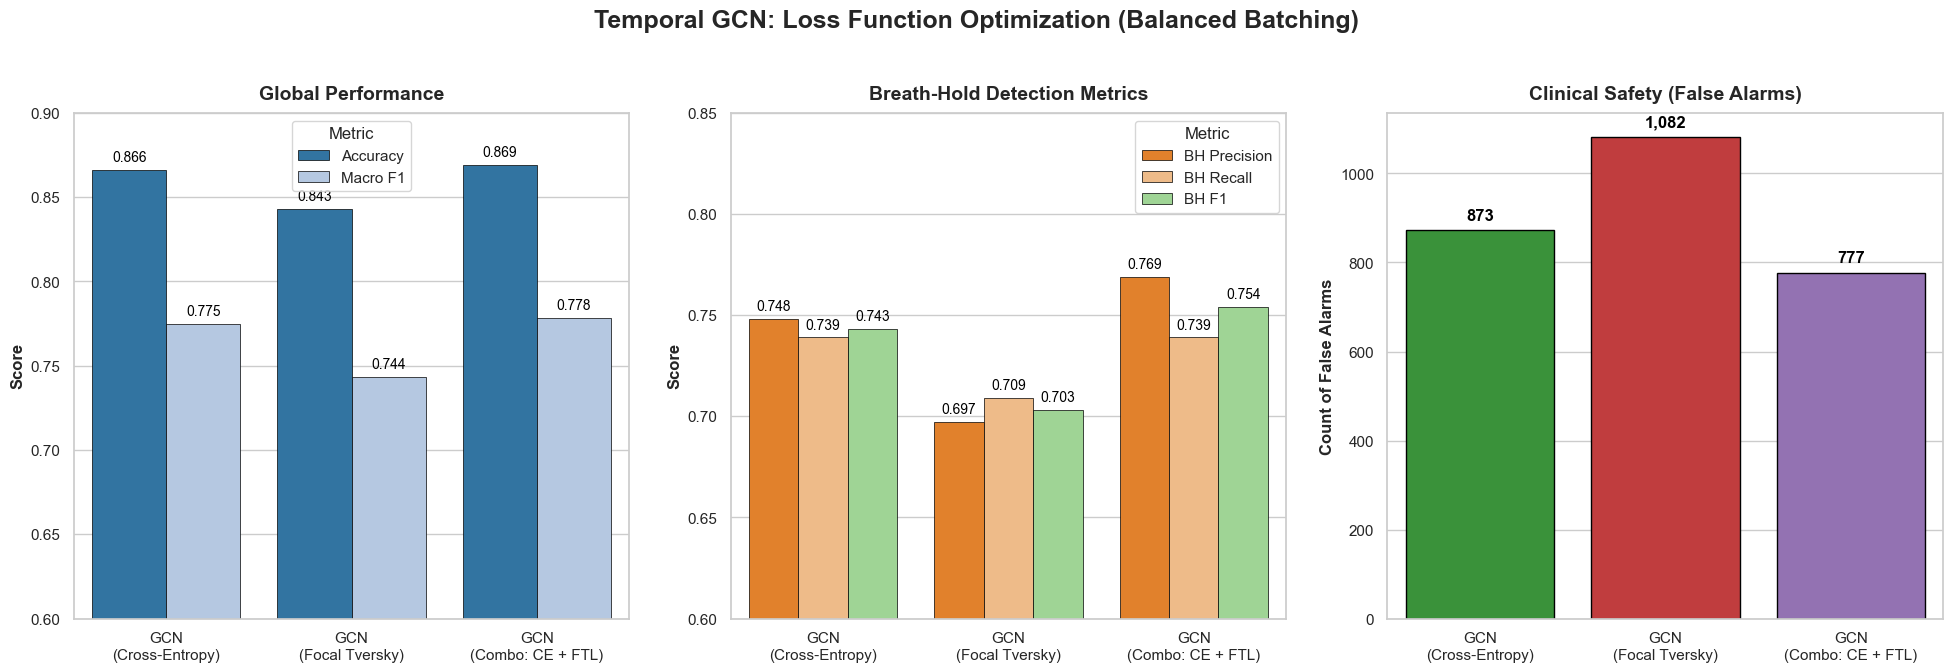

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_gcn_loss_evolution():
    # Data extracted exactly from your three GCN logs
    data = {
        'Model': ['GCN\n(Cross-Entropy)', 'GCN\n(Focal Tversky)', 'GCN\n(Combo: CE + FTL)'],
        'Accuracy': [0.8661, 0.8431, 0.8690],
        'Macro F1': [0.7750, 0.7435, 0.7784],
        'BH Precision': [0.748, 0.697, 0.769],
        'BH Recall': [0.739, 0.709, 0.739],
        'BH F1': [0.743, 0.703, 0.754],
        'False Alarms': [873, 1082, 777] # Calculated from (Actual NB -> Pred BH) + (Actual DB -> Pred BH)
    }

    df = pd.DataFrame(data)

    # Set plotting style
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(20, 7))
    plt.suptitle('Temporal GCN: Loss Function Optimization (Balanced Batching)', fontsize=18, fontweight='bold', y=0.98)

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 1: Overall Performance (Macro F1 & Accuracy)
    # ─────────────────────────────────────────────────────────────────────────────
    ax1 = plt.subplot(1, 3, 1)
    df_global = df[['Model', 'Accuracy', 'Macro F1']].melt(id_vars='Model', var_name='Metric', value_name='Score')
    sns.barplot(data=df_global, x='Model', y='Score', hue='Metric', palette=['#1f77b4', '#aec7e8'], ax=ax1, edgecolor='black', linewidth=0.5)
    
    ax1.set_title('Global Performance', fontsize=14, fontweight='bold', pad=10)
    ax1.set_ylim(0.60, 0.90)
    ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax1.set_xlabel('')
    
    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 4), textcoords='offset points')

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 2: Breath-Hold Detection Power
    # ─────────────────────────────────────────────────────────────────────────────
    ax2 = plt.subplot(1, 3, 2)
    df_bh = df[['Model', 'BH Precision', 'BH Recall', 'BH F1']].melt(id_vars='Model', var_name='Metric', value_name='Score')
    sns.barplot(data=df_bh, x='Model', y='Score', hue='Metric', palette=['#ff7f0e', '#ffbb78', '#98df8a'], ax=ax2, edgecolor='black', linewidth=0.5)
    
    ax2.set_title('Breath-Hold Detection Metrics', fontsize=14, fontweight='bold', pad=10)
    ax2.set_ylim(0.60, 0.85)
    ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax2.set_xlabel('')
    
    for p in ax2.patches:
        ax2.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 4), textcoords='offset points')

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 3: Alarm Fatigue (False Positives)
    # ─────────────────────────────────────────────────────────────────────────────
    ax3 = plt.subplot(1, 3, 3)
    sns.barplot(data=df, x='Model', y='False Alarms', palette=['#2ca02c', '#d62728', '#9467bd'], ax=ax3, edgecolor='black', linewidth=1)
    
    ax3.set_title('Clinical Safety (False Alarms)', fontsize=14, fontweight='bold', pad=10)
    ax3.set_ylabel('Count of False Alarms', fontsize=12, fontweight='bold')
    ax3.set_xlabel('')
    
    for p in ax3.patches:
        ax3.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

    plt.tight_layout(pad=2.0)
    plt.show()

if __name__ == "__main__":
    plot_gcn_loss_evolution()

**GIN**

In [ ]:
"""
gin_clinical_bh_detector_ws20.py
══════════════════════════════════════════════════════════════════════════════
Definitive Clinical Graph Isomorphism Network (GIN) for Breath-Hold prediction.
Dataset  : BH_DB_Features_WS20.csv  (window size = 20 s, step = 1 s, FS = 250 Hz)
Protocol : Leave-One-Subject-Out (LOSO) cross-validation

Architectural Upgrades:
  1. Graph Isomorphism Network (GIN): Replaces GCNConv with GINConv, utilizing 
     an MLP for message aggregation to maximize theoretical expressive power.
  2. Temporal Edge Graph Construction: Time-series converted to PyG graphs.
  3. Balanced Batching: NeighborLoader + WeightedRandomSampler handles imbalance.
  4. Standard Cross-Entropy Loss: Optimal for perfectly balanced mini-batches.
══════════════════════════════════════════════════════════════════════════════
"""

import os
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from torch.nn import Linear, Sequential, BatchNorm1d, ReLU, CrossEntropyLoss
from torch.utils.data import WeightedRandomSampler
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GINConv
from torch_geometric.loader import NeighborLoader

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    accuracy_score, confusion_matrix, roc_auc_score,
    average_precision_score,
)

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# ❶  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV    = "BH_DB_Features_WS20.csv"
RANDOM_SEED  = 42

torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

CLASS_MAP   = {"NB": 0, "BH": 1, "DB": 2}
CLASSES     = [0, 1, 2]
CLASS_NAMES = {0: "NB", 1: "BH", 2: "DB"}

# The WS20 Optimized Feature List
G_LIST = [
    "pNN50_Ratio", "pNN50_Delta", "HF_Ratio",                
    "RMSSD_Ratio", "Mean_RR_Ratio", "Shannon_Entropy_Ratio",   
    "EDR_Std_Amp_Ratio", "EDR_Mean_Amp_Delta"       
]

# GIN Hyperparameters
HIDDEN_DIM   = 64
EPOCHS       = 40
BATCH_SIZE   = 256
LEARNING_RATE= 0.005
WEIGHT_DECAY = 1e-4
K_NEIGHBORS  = 2     

WINSORISE  = True  
WINSOR_LO  = 0.01
WINSOR_HI  = 0.99

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# ─────────────────────────────────────────────────────────────────────────────
# ❷  DATA & GRAPH HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def winsorise_fold(X_tr: np.ndarray, X_te: np.ndarray, lo: float, hi: float):
    lo_vals = np.percentile(X_tr, lo * 100, axis=0)
    hi_vals = np.percentile(X_tr, hi * 100, axis=0)
    X_tr_c = np.clip(X_tr, lo_vals, hi_vals)
    X_te_c = np.clip(X_te, lo_vals, hi_vals)
    return X_tr_c, X_te_c

def enforce_minimum_duration(preds: np.ndarray, target_class: int, min_length: int) -> np.ndarray:
    filtered_preds = preds.copy()
    in_event = False
    start_idx = 0
    for i in range(len(filtered_preds)):
        if filtered_preds[i] == target_class and not in_event:
            in_event = True
            start_idx = i
        elif filtered_preds[i] != target_class and in_event:
            in_event = False
            if (i - start_idx) < min_length:
                filtered_preds[start_idx:i] = 0 
    if in_event and (len(filtered_preds) - start_idx) < min_length:
        filtered_preds[start_idx:] = 0
    return filtered_preds

def build_temporal_subject_graph(subject_df: pd.DataFrame, features: list, scaler: StandardScaler, is_train: bool = True) -> Data:
    df_sorted = subject_df.sort_values("Timestamp_Sec").reset_index(drop=True)
    X_raw = df_sorted[features].fillna(0).values
    
    if is_train: X_scaled = scaler.fit_transform(X_raw)
    else: X_scaled = scaler.transform(X_raw)
        
    X = torch.tensor(X_scaled, dtype=torch.float)
    y = torch.tensor(df_sorted["y"].values, dtype=torch.long)
    
    num_nodes = len(df_sorted)
    edge_sources = []
    edge_targets = []
    
    for i in range(num_nodes):
        start_idx = max(0, i - K_NEIGHBORS)
        end_idx = min(num_nodes, i + K_NEIGHBORS + 1)
        for j in range(start_idx, end_idx):
            if i != j:  
                edge_sources.append(i)
                edge_targets.append(j)
                
    edge_index = torch.tensor([edge_sources, edge_targets], dtype=torch.long)
    return Data(x=X, y=y, edge_index=edge_index)

def create_balanced_loader(train_graphs: list, batch_size: int) -> NeighborLoader:
    train_data = Batch.from_data_list(train_graphs)
    
    class_counts = torch.bincount(train_data.y)
    class_weights = 1.0 / class_counts.float()
    sample_weights = class_weights[train_data.y]
    
    sampler = WeightedRandomSampler(
        weights=sample_weights, 
        num_samples=len(train_data.y), 
        replacement=True
    )
    balanced_node_indices = torch.tensor(list(sampler), dtype=torch.long)
    
    loader = NeighborLoader(
        train_data,
        num_neighbors=[10, 10], 
        batch_size=batch_size,
        input_nodes=balanced_node_indices,
        shuffle=False 
    )
    return loader


# ─────────────────────────────────────────────────────────────────────────────
# ❸  NETWORK ARCHITECTURE (GRAPH ISOMORPHISM NETWORK - GIN)
# ─────────────────────────────────────────────────────────────────────────────

class ClinicalTemporalGIN(torch.nn.Module):
    def __init__(self, num_features: int, hidden_dim: int, num_classes: int):
        super().__init__()
        
        # GIN requires an MLP to aggregate neighbor features to achieve maximum expressive power
        mlp1 = Sequential(
            Linear(num_features, hidden_dim),
            BatchNorm1d(hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim),
            ReLU()
        )
        self.conv1 = GINConv(mlp1, train_eps=True)

        mlp2 = Sequential(
            Linear(hidden_dim, hidden_dim),
            BatchNorm1d(hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim),
            ReLU()
        )
        self.conv2 = GINConv(mlp2, train_eps=True)
        
        self.classifier = Linear(hidden_dim, num_classes)
        self.dropout = torch.nn.Dropout(p=0.3)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.dropout(x)
        
        x = self.conv2(x, edge_index)
        x = self.dropout(x)
        
        out = self.classifier(x)
        return out


# ─────────────────────────────────────────────────────────────────────────────
# ❹  LOSO EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

def run_clinical_gin_loso(df: pd.DataFrame, features: list) -> None:
    subjects = sorted(df["Subject"].unique())
    all_y_true, all_y_prob, all_y_pred = [], [], []

    print("\n" + "═" * 115)
    print(f"  CLINICAL LOSO EVALUATION: TEMPORAL GIN (k={K_NEIGHBORS}) | DEVICE: {DEVICE}")
    print(f"  Balanced NeighborLoader + Cross-Entropy Loss")
    print("═" * 115)

    header = (
        f"  {'Sub':6s} | {'N_NB':>5} | {'N_BH':>5} | {'N_DB':>5} | "
        f"{'Acc':>5} | {'Mac_P':>5} | {'Mac_R':>5} | {'Mac_F1':>6} | "
        f"{'BH_Rec':>6} | {'BH_Pre':>6} | {'BH_F1':>6}"
    )
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:
        tr_df = df[df["Subject"] != test_sub].copy()
        te_df = df[df["Subject"] == test_sub].copy()

        if WINSORISE:
            X_tr_raw = tr_df[features].values
            X_te_raw = te_df[features].values
            X_tr_w, X_te_w = winsorise_fold(X_tr_raw, X_te_raw, WINSOR_LO, WINSOR_HI)
            tr_df.loc[:, features] = X_tr_w
            te_df.loc[:, features] = X_te_w

        scaler = StandardScaler()
        
        train_graphs = []
        for sub in tr_df["Subject"].unique():
            sub_df = tr_df[tr_df["Subject"] == sub]
            is_first = (sub == tr_df["Subject"].unique()[0])
            train_graphs.append(build_temporal_subject_graph(sub_df, features, scaler, is_train=is_first))
            
        test_graph = build_temporal_subject_graph(te_df, features, scaler, is_train=False).to(DEVICE)
        train_loader = create_balanced_loader(train_graphs, BATCH_SIZE)

        # Initialize GIN
        model = ClinicalTemporalGIN(num_features=len(features), hidden_dim=HIDDEN_DIM, num_classes=3).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        
        # Initialize Cross-Entropy Loss
        criterion = CrossEntropyLoss().to(DEVICE)

        model.train()
        for epoch in range(EPOCHS):
            for batch in train_loader:
                batch = batch.to(DEVICE)
                optimizer.zero_grad()
                out = model(batch.x, batch.edge_index)
                
                # Calculate loss only on the perfectly balanced target nodes
                loss = criterion(out[:batch.batch_size], batch.y[:batch.batch_size])
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            out = model(test_graph.x, test_graph.edge_index)
            probs = F.softmax(out, dim=1).cpu().numpy()
            raw_preds = np.argmax(probs, axis=1)

        pred_cal = enforce_minimum_duration(raw_preds, target_class=1, min_length=5)
        pred_cal = enforce_minimum_duration(pred_cal, target_class=2, min_length=3)

        y_te = test_graph.y.cpu().numpy()

        n_nb = int((y_te == 0).sum())
        n_bh = int((y_te == 1).sum())
        n_db = int((y_te == 2).sum())

        acc     = accuracy_score(y_te, pred_cal)
        mac_p   = precision_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_r   = recall_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_f1  = f1_score(y_te, pred_cal, average="macro", zero_division=0)

        bh_rec  = recall_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_pre  = precision_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_f1   = f1_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]

        print(
            f"  {test_sub:6s} | {n_nb:5d} | {n_bh:5d} | {n_db:5d} | "
            f"{acc:5.3f} | {mac_p:5.3f} | {mac_r:5.3f} | {mac_f1:6.3f} | "
            f"{bh_rec:6.3f} | {bh_pre:6.3f} | {bh_f1:6.3f}"
        )

        all_y_true.extend(y_te.tolist())
        all_y_prob.extend(probs.tolist())
        all_y_pred.extend(pred_cal.tolist())

    print("  " + "─" * (len(header) - 2))

    y_true = np.array(all_y_true)
    y_prob = np.array(all_y_prob)
    y_pred = np.array(all_y_pred)

    y_bin = label_binarize(y_true, classes=CLASSES)

    auroc = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    auprc = average_precision_score(y_bin, y_prob, average="macro")

    acc     = accuracy_score(y_true, y_pred)
    mac_p   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    mac_r   = recall_score(y_true, y_pred, average="macro", zero_division=0)
    mac_f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)

    bh_rec  = recall_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_pre  = precision_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_f1   = f1_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]

    db_rec  = recall_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_pre  = precision_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_f1   = f1_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]

    nb_rec  = recall_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]
    nb_pre  = precision_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]

    print()
    print("  ── GIN OVERALL RESULTS (MACRO AVERAGED) ──")
    print(f"     AUROC (OVR)     = {auroc:.4f}")
    print(f"     AUPRC           = {auprc:.4f}")
    print(f"     Accuracy        = {acc:.4f}")
    print(f"     Macro Precision = {mac_p:.4f}")
    print(f"     Macro Recall    = {mac_r:.4f}")
    print(f"     Macro F1        = {mac_f1:.4f}")
    print()
    print("  ── PER-CLASS BREAKDOWN ──")
    print(f"     NB  : Recall={nb_rec:.3f}  Precision={nb_pre:.3f}")
    print(f"     BH  : Recall={bh_rec:.3f}  Precision={bh_pre:.3f}  F1={bh_f1:.3f}")
    print(f"     DB  : Recall={db_rec:.3f}  Precision={db_pre:.3f}  F1={db_f1:.3f}")

    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    print()
    print("  ── OVERALL CONFUSION MATRIX ──")
    print(f"  {'':20s}  {'Pred NB':>10}  {'Pred BH':>10}  {'Pred DB':>10}")
    for i, name in CLASS_NAMES.items():
        row = cm[i]
        print(f"  Actual {name} ({i})         {row[0]:>10}  {row[1]:>10}  {row[2]:>10}")
    print("═" * 115)


# ─────────────────────────────────────────────────────────────────────────────
# ❻  MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main() -> None:
    print("═" * 80)
    print("  CLINICAL TEMPORAL GIN PIPELINE: BH/DB PREDICTION (WS20)")
    print("═" * 80)

    if not os.path.exists(INPUT_CSV):
        raise FileNotFoundError(f"Dataset not found: {INPUT_CSV}")

    df = pd.read_csv(INPUT_CSV)
    df["y"] = df["Category"].map(CLASS_MAP)
    features = G_LIST

    total   = len(df)
    n_nb    = (df["y"] == 0).sum()
    n_bh    = (df["y"] == 1).sum()
    n_db    = (df["y"] == 2).sum()
    n_sub   = df["Subject"].nunique()

    print(f"\n  [+] Dataset overview : {total:,} windows | {n_sub} subjects")
    print(f"      NB = {n_nb:,} ({n_nb/total*100:.1f}%)")
    print(f"      BH = {n_bh:,} ({n_bh/total*100:.1f}%)")
    print(f"      DB = {n_db:,} ({n_db/total*100:.1f}%)")
    
    print(f"\n  [+] GIN Architecture Specifications:")
    print(f"      Features Locked      : {len(features)} (VIF Optimized G_LIST)")
    print(f"      Model Topology       : 2x GINConv Layers (MLP Aggregation, Hidden Dim = {HIDDEN_DIM})")
    print(f"      Graph Construction   : Temporal Edges (t ± {K_NEIGHBORS})")
    print(f"      Handling Imbalance   : NeighborLoader + WeightedRandomSampler")
    print(f"      Loss Function        : Standard Cross-Entropy")
    print(f"      Mandatory Scaling    : StandardScaler applied per-fold")

    run_clinical_gin_loso(df, features)


if __name__ == "__main__":
    main()

════════════════════════════════════════════════════════════════════════════════
  CLINICAL TEMPORAL GIN PIPELINE: BH/DB PREDICTION (WS20)
════════════════════════════════════════════════════════════════════════════════

  [+] Dataset overview : 28,090 windows | 41 subjects
      NB = 21,529 (76.6%)
      BH = 3,505 (12.5%)
      DB = 3,056 (10.9%)

  [+] GIN Architecture Specifications:
      Features Locked      : 8 (VIF Optimized G_LIST)
      Model Topology       : 2x GINConv Layers (MLP Aggregation, Hidden Dim = 64)
      Graph Construction   : Temporal Edges (t ± 2)
      Handling Imbalance   : NeighborLoader + WeightedRandomSampler
      Loss Function        : Standard Cross-Entropy
      Mandatory Scaling    : StandardScaler applied per-fold

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  CLINICAL LOSO EVALUATION: TEMPORAL GIN (k=2) | DEVICE: cuda
  Balanced NeighborLoader + Cross-Entropy Loss
══════════════

In [ ]:
"""
gin_clinical_bh_detector_ws20_tversky.py
══════════════════════════════════════════════════════════════════════════════
Definitive Clinical Graph Isomorphism Network (GIN) for Breath-Hold prediction.
Dataset  : BH_DB_Features_WS20.csv  (window size = 20 s, step = 1 s, FS = 250 Hz)
Protocol : Leave-One-Subject-Out (LOSO) cross-validation

Architectural Upgrades:
  1. Graph Isomorphism Network (GIN): Replaces GCNConv with GINConv, utilizing 
     an MLP for message aggregation to maximize theoretical expressive power.
  2. Temporal Edge Graph Construction: Time-series converted to PyG graphs.
  3. Balanced Batching: NeighborLoader + WeightedRandomSampler handles imbalance.
  4. Focal Tversky Loss (FTL): Replaces standard Cross-Entropy to heavily 
     penalize False Negatives (missed BH events) and focus on hard boundaries.
══════════════════════════════════════════════════════════════════════════════
"""

import os
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.nn import Linear, Sequential, BatchNorm1d, ReLU
from torch.utils.data import WeightedRandomSampler
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GINConv
from torch_geometric.loader import NeighborLoader

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    accuracy_score, confusion_matrix, roc_auc_score,
    average_precision_score,
)

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# ❶  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV    = "BH_DB_Features_WS20.csv"
RANDOM_SEED  = 42

# Ensure reproducibility across PyTorch operations
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

CLASS_MAP   = {"NB": 0, "BH": 1, "DB": 2}
CLASSES     = [0, 1, 2]
CLASS_NAMES = {0: "NB", 1: "BH", 2: "DB"}

# The WS20 Optimized Feature List
G_LIST = [
    "pNN50_Ratio", "pNN50_Delta", "HF_Ratio",                
    "RMSSD_Ratio", "Mean_RR_Ratio", "Shannon_Entropy_Ratio",   
    "EDR_Std_Amp_Ratio", "EDR_Mean_Amp_Delta"       
]

# GIN Hyperparameters
HIDDEN_DIM   = 64
EPOCHS       = 40
BATCH_SIZE   = 256
LEARNING_RATE= 0.005
WEIGHT_DECAY = 1e-4
K_NEIGHBORS  = 2     # Receptive field width (t ± 2)

# Focal Tversky Hyperparameters
FTL_ALPHA    = 0.3   # Lower penalty for False Positives
FTL_BETA     = 0.7   # Higher penalty for False Negatives (Missed BH)
FTL_GAMMA    = 1.3   # Focal parameter to suppress easy examples

WINSORISE  = True  
WINSOR_LO  = 0.01
WINSOR_HI  = 0.99

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# ─────────────────────────────────────────────────────────────────────────────
# ❷  CUSTOM FOCAL TVERSKY LOSS
# ─────────────────────────────────────────────────────────────────────────────

class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha: float, beta: float, gamma: float, smooth: float = 1e-6):
        super(FocalTverskyLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        num_classes = logits.shape[1]
        targets_one_hot = F.one_hot(targets, num_classes=num_classes).float()
        
        total_loss = 0.0
        
        for c in range(num_classes):
            prob_c = probs[:, c]
            target_c = targets_one_hot[:, c]
            
            TP = (prob_c * target_c).sum()
            FP = ((1 - target_c) * prob_c).sum()
            FN = (target_c * (1 - prob_c)).sum()
            
            Tversky = (TP + self.smooth) / (TP + self.alpha * FP + self.beta * FN + self.smooth)
            FocalTversky = (1 - Tversky) ** self.gamma
            total_loss += FocalTversky
            
        return total_loss / num_classes


# ─────────────────────────────────────────────────────────────────────────────
# ❸  DATA & GRAPH HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def winsorise_fold(X_tr: np.ndarray, X_te: np.ndarray, lo: float, hi: float):
    lo_vals = np.percentile(X_tr, lo * 100, axis=0)
    hi_vals = np.percentile(X_tr, hi * 100, axis=0)
    X_tr_c = np.clip(X_tr, lo_vals, hi_vals)
    X_te_c = np.clip(X_te, lo_vals, hi_vals)
    return X_tr_c, X_te_c

def enforce_minimum_duration(preds: np.ndarray, target_class: int, min_length: int) -> np.ndarray:
    filtered_preds = preds.copy()
    in_event = False
    start_idx = 0
    for i in range(len(filtered_preds)):
        if filtered_preds[i] == target_class and not in_event:
            in_event = True
            start_idx = i
        elif filtered_preds[i] != target_class and in_event:
            in_event = False
            if (i - start_idx) < min_length:
                filtered_preds[start_idx:i] = 0 
    if in_event and (len(filtered_preds) - start_idx) < min_length:
        filtered_preds[start_idx:] = 0
    return filtered_preds

def build_temporal_subject_graph(subject_df: pd.DataFrame, features: list, scaler: StandardScaler, is_train: bool = True) -> Data:
    df_sorted = subject_df.sort_values("Timestamp_Sec").reset_index(drop=True)
    
    X_raw = df_sorted[features].fillna(0).values
    
    if is_train:
        X_scaled = scaler.fit_transform(X_raw)
    else:
        X_scaled = scaler.transform(X_raw)
        
    X = torch.tensor(X_scaled, dtype=torch.float)
    y = torch.tensor(df_sorted["y"].values, dtype=torch.long)
    
    num_nodes = len(df_sorted)
    edge_sources = []
    edge_targets = []
    
    for i in range(num_nodes):
        start_idx = max(0, i - K_NEIGHBORS)
        end_idx = min(num_nodes, i + K_NEIGHBORS + 1)
        
        for j in range(start_idx, end_idx):
            if i != j:  
                edge_sources.append(i)
                edge_targets.append(j)
                
    edge_index = torch.tensor([edge_sources, edge_targets], dtype=torch.long)
    
    return Data(x=X, y=y, edge_index=edge_index)


def create_balanced_loader(train_graphs: list, batch_size: int) -> NeighborLoader:
    train_data = Batch.from_data_list(train_graphs)
    
    class_counts = torch.bincount(train_data.y)
    class_weights = 1.0 / class_counts.float()
    sample_weights = class_weights[train_data.y]
    
    sampler = WeightedRandomSampler(
        weights=sample_weights, 
        num_samples=len(train_data.y), 
        replacement=True
    )
    balanced_node_indices = torch.tensor(list(sampler), dtype=torch.long)
    
    loader = NeighborLoader(
        train_data,
        num_neighbors=[10, 10], 
        batch_size=batch_size,
        input_nodes=balanced_node_indices,
        shuffle=False 
    )
    
    return loader


# ─────────────────────────────────────────────────────────────────────────────
# ❹  NETWORK ARCHITECTURE (GRAPH ISOMORPHISM NETWORK - GIN)
# ─────────────────────────────────────────────────────────────────────────────

class ClinicalTemporalGIN(torch.nn.Module):
    def __init__(self, num_features: int, hidden_dim: int, num_classes: int):
        super().__init__()
        
        mlp1 = Sequential(
            Linear(num_features, hidden_dim),
            BatchNorm1d(hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim),
            ReLU()
        )
        self.conv1 = GINConv(mlp1, train_eps=True)

        mlp2 = Sequential(
            Linear(hidden_dim, hidden_dim),
            BatchNorm1d(hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim),
            ReLU()
        )
        self.conv2 = GINConv(mlp2, train_eps=True)
        
        self.classifier = Linear(hidden_dim, num_classes)
        self.dropout = torch.nn.Dropout(p=0.3)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.dropout(x)
        
        x = self.conv2(x, edge_index)
        x = self.dropout(x)
        
        out = self.classifier(x)
        return out


# ─────────────────────────────────────────────────────────────────────────────
# ❺  LOSO EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

def run_clinical_gin_loso(df: pd.DataFrame, features: list) -> None:
    subjects = sorted(df["Subject"].unique())
    all_y_true, all_y_prob, all_y_pred = [], [], []

    print("\n" + "═" * 115)
    print(f"  CLINICAL LOSO EVALUATION: TEMPORAL GIN (k={K_NEIGHBORS}) | DEVICE: {DEVICE}")
    print(f"  Balanced NeighborLoader Batching + Focal Tversky Loss (\u03B1={FTL_ALPHA}, \u03B2={FTL_BETA}, \u03B3={FTL_GAMMA})")
    print("═" * 115)

    header = (
        f"  {'Sub':6s} | {'N_NB':>5} | {'N_BH':>5} | {'N_DB':>5} | "
        f"{'Acc':>5} | {'Mac_P':>5} | {'Mac_R':>5} | {'Mac_F1':>6} | "
        f"{'BH_Rec':>6} | {'BH_Pre':>6} | {'BH_F1':>6}"
    )
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:

        tr_df = df[df["Subject"] != test_sub].copy()
        te_df = df[df["Subject"] == test_sub].copy()

        # ── 1. Winsorise ──
        if WINSORISE:
            X_tr_raw = tr_df[features].values
            X_te_raw = te_df[features].values
            X_tr_w, X_te_w = winsorise_fold(X_tr_raw, X_te_raw, WINSOR_LO, WINSOR_HI)
            tr_df.loc[:, features] = X_tr_w
            te_df.loc[:, features] = X_te_w

        # ── 2. Graph Construction ──
        scaler = StandardScaler()
        
        train_graphs = []
        for sub in tr_df["Subject"].unique():
            sub_df = tr_df[tr_df["Subject"] == sub]
            is_first = (sub == tr_df["Subject"].unique()[0])
            train_graphs.append(build_temporal_subject_graph(sub_df, features, scaler, is_train=is_first))
            
        test_graph = build_temporal_subject_graph(te_df, features, scaler, is_train=False).to(DEVICE)

        # ── 3. Balanced Dataloader ──
        train_loader = create_balanced_loader(train_graphs, BATCH_SIZE)

        # ── 4. Initialize GIN & Focal Tversky Loss ──
        model = ClinicalTemporalGIN(num_features=len(features), hidden_dim=HIDDEN_DIM, num_classes=3).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        
        criterion = FocalTverskyLoss(alpha=FTL_ALPHA, beta=FTL_BETA, gamma=FTL_GAMMA).to(DEVICE)

        # ── 5. Training Loop ──
        model.train()
        for epoch in range(EPOCHS):
            for batch in train_loader:
                batch = batch.to(DEVICE)
                optimizer.zero_grad()
                out = model(batch.x, batch.edge_index)
                
                # Calculate FTL only on the target nodes
                loss = criterion(out[:batch.batch_size], batch.y[:batch.batch_size])
                loss.backward()
                optimizer.step()

        # ── 6. Evaluation ──
        model.eval()
        with torch.no_grad():
            out = model(test_graph.x, test_graph.edge_index)
            probs = F.softmax(out, dim=1).cpu().numpy()
            raw_preds = np.argmax(probs, axis=1)

        # ── 7. Clinical Minimum Duration Filter ──
        pred_cal = enforce_minimum_duration(raw_preds, target_class=1, min_length=5)
        pred_cal = enforce_minimum_duration(pred_cal, target_class=2, min_length=3)

        y_te = test_graph.y.cpu().numpy()

        # ── 8. Per-subject metrics ──
        n_nb = int((y_te == 0).sum())
        n_bh = int((y_te == 1).sum())
        n_db = int((y_te == 2).sum())

        acc     = accuracy_score(y_te, pred_cal)
        mac_p   = precision_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_r   = recall_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_f1  = f1_score(y_te, pred_cal, average="macro", zero_division=0)

        bh_rec  = recall_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_pre  = precision_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_f1   = f1_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]

        print(
            f"  {test_sub:6s} | {n_nb:5d} | {n_bh:5d} | {n_db:5d} | "
            f"{acc:5.3f} | {mac_p:5.3f} | {mac_r:5.3f} | {mac_f1:6.3f} | "
            f"{bh_rec:6.3f} | {bh_pre:6.3f} | {bh_f1:6.3f}"
        )

        all_y_true.extend(y_te.tolist())
        all_y_prob.extend(probs.tolist())
        all_y_pred.extend(pred_cal.tolist())

    # ── Overall metrics ───────────────────────────────────────────────────────
    print("  " + "─" * (len(header) - 2))

    y_true = np.array(all_y_true)
    y_prob = np.array(all_y_prob)
    y_pred = np.array(all_y_pred)

    y_bin = label_binarize(y_true, classes=CLASSES)

    auroc = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    auprc = average_precision_score(y_bin, y_prob, average="macro")

    acc     = accuracy_score(y_true, y_pred)
    mac_p   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    mac_r   = recall_score(y_true, y_pred, average="macro", zero_division=0)
    mac_f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)

    bh_rec  = recall_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_pre  = precision_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_f1   = f1_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]

    db_rec  = recall_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_pre  = precision_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_f1   = f1_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]

    nb_rec  = recall_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]
    nb_pre  = precision_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]

    print()
    print("  ── GIN OVERALL RESULTS (MACRO AVERAGED) ──")
    print(f"     AUROC (OVR)     = {auroc:.4f}")
    print(f"     AUPRC           = {auprc:.4f}")
    print(f"     Accuracy        = {acc:.4f}")
    print(f"     Macro Precision = {mac_p:.4f}")
    print(f"     Macro Recall    = {mac_r:.4f}")
    print(f"     Macro F1        = {mac_f1:.4f}")
    print()
    print("  ── PER-CLASS BREAKDOWN ──")
    print(f"     NB  : Recall={nb_rec:.3f}  Precision={nb_pre:.3f}")
    print(f"     BH  : Recall={bh_rec:.3f}  Precision={bh_pre:.3f}  F1={bh_f1:.3f}")
    print(f"     DB  : Recall={db_rec:.3f}  Precision={db_pre:.3f}  F1={db_f1:.3f}")

    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    print()
    print("  ── OVERALL CONFUSION MATRIX ──")
    print(f"  {'':20s}  {'Pred NB':>10}  {'Pred BH':>10}  {'Pred DB':>10}")
    for i, name in CLASS_NAMES.items():
        row = cm[i]
        print(f"  Actual {name} ({i})         {row[0]:>10}  {row[1]:>10}  {row[2]:>10}")
    print("═" * 115)


# ─────────────────────────────────────────────────────────────────────────────
# ❻  MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main() -> None:
    print("═" * 80)
    print("  CLINICAL TEMPORAL GIN PIPELINE: BH/DB PREDICTION (WS20)")
    print("═" * 80)

    if not os.path.exists(INPUT_CSV):
        raise FileNotFoundError(f"Dataset not found: {INPUT_CSV}")

    df = pd.read_csv(INPUT_CSV)
    df["y"] = df["Category"].map(CLASS_MAP)
    features = G_LIST

    total   = len(df)
    n_nb    = (df["y"] == 0).sum()
    n_bh    = (df["y"] == 1).sum()
    n_db    = (df["y"] == 2).sum()
    n_sub   = df["Subject"].nunique()

    print(f"\n  [+] Dataset overview : {total:,} windows | {n_sub} subjects")
    print(f"      NB = {n_nb:,} ({n_nb/total*100:.1f}%)")
    print(f"      BH = {n_bh:,} ({n_bh/total*100:.1f}%)")
    print(f"      DB = {n_db:,} ({n_db/total*100:.1f}%)")
    
    print(f"\n  [+] GIN Architecture Specifications:")
    print(f"      Features Locked      : {len(features)} (VIF Optimized G_LIST)")
    print(f"      Model Topology       : 2x GINConv Layers (MLP Aggregation, Hidden Dim = {HIDDEN_DIM})")
    print(f"      Graph Construction   : Temporal Edges (t ± {K_NEIGHBORS})")
    print(f"      Handling Imbalance   : NeighborLoader + WeightedRandomSampler")
    print(f"      Loss Function        : Focal Tversky (\u03B1={FTL_ALPHA}, \u03B2={FTL_BETA}, \u03B3={FTL_GAMMA})")
    print(f"      Mandatory Scaling    : StandardScaler applied per-fold")

    # Execute
    run_clinical_gin_loso(df, features)


if __name__ == "__main__":
    main()

════════════════════════════════════════════════════════════════════════════════
  CLINICAL TEMPORAL GIN PIPELINE: BH/DB PREDICTION (WS20)
════════════════════════════════════════════════════════════════════════════════

  [+] Dataset overview : 28,090 windows | 41 subjects
      NB = 21,529 (76.6%)
      BH = 3,505 (12.5%)
      DB = 3,056 (10.9%)

  [+] GIN Architecture Specifications:
      Features Locked      : 8 (VIF Optimized G_LIST)
      Model Topology       : 2x GINConv Layers (MLP Aggregation, Hidden Dim = 64)
      Graph Construction   : Temporal Edges (t ± 2)
      Handling Imbalance   : NeighborLoader + WeightedRandomSampler
      Loss Function        : Focal Tversky (α=0.3, β=0.7, γ=1.3)
      Mandatory Scaling    : StandardScaler applied per-fold

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  CLINICAL LOSO EVALUATION: TEMPORAL GIN (k=2) | DEVICE: cuda
  Balanced NeighborLoader Batching + Focal Tvers

C:\Users\ejisg\AppData\Local\Temp\ipykernel_16104\2953931492.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Model', y='False Alarms', palette=['#1f77b4', '#d62728'], ax=ax2, edgecolor='black', linewidth=1)


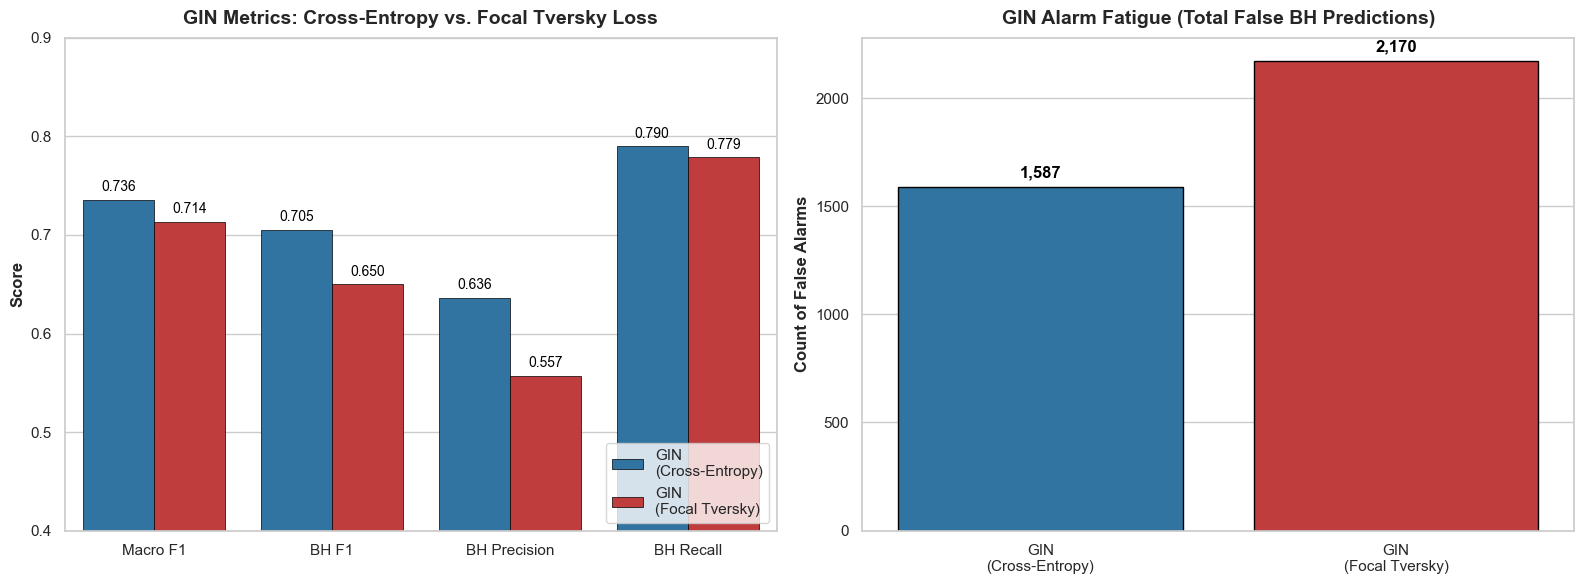

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_gin_loss_comparison():
    # Data extracted exactly from your provided GIN logs
    data = {
        'Model': ['GIN\n(Cross-Entropy)', 'GIN\n(Focal Tversky)'],
        'Accuracy': [0.8330, 0.8080],
        'Macro F1': [0.7355, 0.7135],
        'BH Precision': [0.636, 0.557],
        'BH Recall': [0.790, 0.779],
        'BH F1': [0.705, 0.650],
        'False Alarms': [1587, 2170] # Calculated from (Actual NB -> Pred BH) + (Actual DB -> Pred BH)
    }

    df = pd.DataFrame(data)

    # Set plotting style
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(16, 6))

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 1: Predictive Metrics Comparison
    # ─────────────────────────────────────────────────────────────────────────────
    ax1 = plt.subplot(1, 2, 1)
    df_metrics = df[['Model', 'Macro F1', 'BH F1', 'BH Precision', 'BH Recall']].melt(id_vars='Model', var_name='Metric', value_name='Score')
    sns.barplot(data=df_metrics, x='Metric', y='Score', hue='Model', palette=['#1f77b4', '#d62728'], ax=ax1, edgecolor='black', linewidth=0.5)

    ax1.set_title('GIN Metrics: Cross-Entropy vs. Focal Tversky Loss', fontsize=14, fontweight='bold', pad=10)
    ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax1.set_xlabel('')
    ax1.set_ylim(0.40, 0.90)

    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 4), textcoords='offset points')
    ax1.legend(loc='lower right')

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 2: Alarm Fatigue (False Alarms)
    # ─────────────────────────────────────────────────────────────────────────────
    ax2 = plt.subplot(1, 2, 2)
    sns.barplot(data=df, x='Model', y='False Alarms', palette=['#1f77b4', '#d62728'], ax=ax2, edgecolor='black', linewidth=1)

    ax2.set_title('GIN Alarm Fatigue (Total False BH Predictions)', fontsize=14, fontweight='bold', pad=10)
    ax2.set_ylabel('Count of False Alarms', fontsize=12, fontweight='bold')
    ax2.set_xlabel('')

    for p in ax2.patches:
        ax2.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_gin_loss_comparison()

In [ ]:
"""
gin_clinical_bh_detector_ws20_combo.py
══════════════════════════════════════════════════════════════════════════════
Definitive Clinical Graph Isomorphism Network (GIN) for Breath-Hold prediction.
Dataset  : BH_DB_Features_WS20.csv  (window size = 20 s, step = 1 s, FS = 250 Hz)
Protocol : Leave-One-Subject-Out (LOSO) cross-validation

Architectural Upgrades:
  1. Graph Isomorphism Network (GIN): Replaces GCNConv with GINConv, utilizing 
     an MLP for message aggregation to maximize theoretical expressive power.
  2. Combo Loss (CE + FTL): Combines Cross-Entropy for overall accuracy and 
     Focal Tversky Loss to optimize temporal overlap and penalize False Negatives.
  3. Temporal Edge Graph Construction: Time-series converted to PyG graphs.
  4. Balanced Batching: NeighborLoader + WeightedRandomSampler handles imbalance.
══════════════════════════════════════════════════════════════════════════════
"""

import os
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.nn import Linear, Sequential, BatchNorm1d, ReLU
from torch.utils.data import WeightedRandomSampler
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GINConv
from torch_geometric.loader import NeighborLoader

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    accuracy_score, confusion_matrix, roc_auc_score,
    average_precision_score,
)

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# ❶  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV    = "BH_DB_Features_WS20.csv"
RANDOM_SEED  = 42

torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

CLASS_MAP   = {"NB": 0, "BH": 1, "DB": 2}
CLASSES     = [0, 1, 2]
CLASS_NAMES = {0: "NB", 1: "BH", 2: "DB"}

G_LIST = [
    "pNN50_Ratio", "pNN50_Delta", "HF_Ratio",                
    "RMSSD_Ratio", "Mean_RR_Ratio", "Shannon_Entropy_Ratio",   
    "EDR_Std_Amp_Ratio", "EDR_Mean_Amp_Delta"       
]

# GIN Hyperparameters
HIDDEN_DIM   = 64
EPOCHS       = 40
BATCH_SIZE   = 256
LEARNING_RATE= 0.005
WEIGHT_DECAY = 1e-4
K_NEIGHBORS  = 2     # Receptive field width (t ± 2)

# Combo Loss Hyperparameters
COMBO_ALPHA  = 0.5   # 50% CE, 50% FTL
FTL_ALPHA    = 0.3   # Penalty for False Positives
FTL_BETA     = 0.7   # Heavy penalty for False Negatives (Missed BH)
FTL_GAMMA    = 1.3   # Focal parameter

WINSORISE  = True  
WINSOR_LO  = 0.01
WINSOR_HI  = 0.99

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# ─────────────────────────────────────────────────────────────────────────────
# ❷  CUSTOM COMBO LOSS (CE + FTL)
# ─────────────────────────────────────────────────────────────────────────────

class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha: float, beta: float, gamma: float, smooth: float = 1e-6):
        super(FocalTverskyLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        num_classes = logits.shape[1]
        targets_one_hot = F.one_hot(targets, num_classes=num_classes).float()
        
        total_loss = 0.0
        for c in range(num_classes):
            prob_c = probs[:, c]
            target_c = targets_one_hot[:, c]
            
            TP = (prob_c * target_c).sum()
            FP = ((1 - target_c) * prob_c).sum()
            FN = (target_c * (1 - prob_c)).sum()
            
            Tversky = (TP + self.smooth) / (TP + self.alpha * FP + self.beta * FN + self.smooth)
            FocalTversky = (1 - Tversky) ** self.gamma
            total_loss += FocalTversky
            
        return total_loss / num_classes


class ComboLoss(nn.Module):
    """Combines Cross Entropy with Focal Tversky Loss"""
    def __init__(self, combo_alpha=0.5, ftl_alpha=0.3, ftl_beta=0.7, ftl_gamma=1.3):
        super(ComboLoss, self).__init__()
        self.combo_alpha = combo_alpha
        self.ce = nn.CrossEntropyLoss()
        self.ftl = FocalTverskyLoss(alpha=ftl_alpha, beta=ftl_beta, gamma=ftl_gamma)

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        ftl_loss = self.ftl(logits, targets)
        return (self.combo_alpha * ce_loss) + ((1 - self.combo_alpha) * ftl_loss)


# ─────────────────────────────────────────────────────────────────────────────
# ❸  DATA & GRAPH HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def winsorise_fold(X_tr: np.ndarray, X_te: np.ndarray, lo: float, hi: float):
    lo_vals = np.percentile(X_tr, lo * 100, axis=0)
    hi_vals = np.percentile(X_tr, hi * 100, axis=0)
    X_tr_c = np.clip(X_tr, lo_vals, hi_vals)
    X_te_c = np.clip(X_te, lo_vals, hi_vals)
    return X_tr_c, X_te_c

def enforce_minimum_duration(preds: np.ndarray, target_class: int, min_length: int) -> np.ndarray:
    filtered_preds = preds.copy()
    in_event = False
    start_idx = 0
    for i in range(len(filtered_preds)):
        if filtered_preds[i] == target_class and not in_event:
            in_event = True
            start_idx = i
        elif filtered_preds[i] != target_class and in_event:
            in_event = False
            if (i - start_idx) < min_length:
                filtered_preds[start_idx:i] = 0 
    if in_event and (len(filtered_preds) - start_idx) < min_length:
        filtered_preds[start_idx:] = 0
    return filtered_preds

def build_temporal_subject_graph(subject_df: pd.DataFrame, features: list, scaler: StandardScaler, is_train: bool = True) -> Data:
    df_sorted = subject_df.sort_values("Timestamp_Sec").reset_index(drop=True)
    X_raw = df_sorted[features].fillna(0).values
    
    if is_train:
        X_scaled = scaler.fit_transform(X_raw)
    else:
        X_scaled = scaler.transform(X_raw)
        
    X = torch.tensor(X_scaled, dtype=torch.float)
    y = torch.tensor(df_sorted["y"].values, dtype=torch.long)
    
    num_nodes = len(df_sorted)
    edge_sources = []
    edge_targets = []
    
    for i in range(num_nodes):
        start_idx = max(0, i - K_NEIGHBORS)
        end_idx = min(num_nodes, i + K_NEIGHBORS + 1)
        for j in range(start_idx, end_idx):
            if i != j:  
                edge_sources.append(i)
                edge_targets.append(j)
                
    edge_index = torch.tensor([edge_sources, edge_targets], dtype=torch.long)
    return Data(x=X, y=y, edge_index=edge_index)


def create_balanced_loader(train_graphs: list, batch_size: int) -> NeighborLoader:
    train_data = Batch.from_data_list(train_graphs)
    
    class_counts = torch.bincount(train_data.y)
    class_weights = 1.0 / class_counts.float()
    sample_weights = class_weights[train_data.y]
    
    sampler = WeightedRandomSampler(
        weights=sample_weights, 
        num_samples=len(train_data.y), 
        replacement=True
    )
    balanced_node_indices = torch.tensor(list(sampler), dtype=torch.long)
    
    loader = NeighborLoader(
        train_data,
        num_neighbors=[10, 10], 
        batch_size=batch_size,
        input_nodes=balanced_node_indices,
        shuffle=False 
    )
    
    return loader


# ─────────────────────────────────────────────────────────────────────────────
# ❹  NETWORK ARCHITECTURE (GRAPH ISOMORPHISM NETWORK - GIN)
# ─────────────────────────────────────────────────────────────────────────────

class ClinicalTemporalGIN(torch.nn.Module):
    def __init__(self, num_features: int, hidden_dim: int, num_classes: int):
        super().__init__()
        
        mlp1 = Sequential(
            Linear(num_features, hidden_dim),
            BatchNorm1d(hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim),
            ReLU()
        )
        self.conv1 = GINConv(mlp1, train_eps=True)

        mlp2 = Sequential(
            Linear(hidden_dim, hidden_dim),
            BatchNorm1d(hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim),
            ReLU()
        )
        self.conv2 = GINConv(mlp2, train_eps=True)
        
        self.classifier = Linear(hidden_dim, num_classes)
        self.dropout = torch.nn.Dropout(p=0.3)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.dropout(x)
        
        x = self.conv2(x, edge_index)
        x = self.dropout(x)
        
        out = self.classifier(x)
        return out


# ─────────────────────────────────────────────────────────────────────────────
# ❺  LOSO EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

def run_clinical_gin_loso(df: pd.DataFrame, features: list) -> None:
    subjects = sorted(df["Subject"].unique())
    all_y_true, all_y_prob, all_y_pred = [], [], []

    print("\n" + "═" * 115)
    print(f"  CLINICAL LOSO EVALUATION: TEMPORAL GIN (k={K_NEIGHBORS}) | DEVICE: {DEVICE}")
    print(f"  Balanced NeighborLoader + Combo Loss ({int(COMBO_ALPHA*100)}% CE, {int((1-COMBO_ALPHA)*100)}% FTL)")
    print("═" * 115)

    header = (
        f"  {'Sub':6s} | {'N_NB':>5} | {'N_BH':>5} | {'N_DB':>5} | "
        f"{'Acc':>5} | {'Mac_P':>5} | {'Mac_R':>5} | {'Mac_F1':>6} | "
        f"{'BH_Rec':>6} | {'BH_Pre':>6} | {'BH_F1':>6}"
    )
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:
        tr_df = df[df["Subject"] != test_sub].copy()
        te_df = df[df["Subject"] == test_sub].copy()

        if WINSORISE:
            X_tr_raw = tr_df[features].values
            X_te_raw = te_df[features].values
            X_tr_w, X_te_w = winsorise_fold(X_tr_raw, X_te_raw, WINSOR_LO, WINSOR_HI)
            tr_df.loc[:, features] = X_tr_w
            te_df.loc[:, features] = X_te_w

        scaler = StandardScaler()
        
        train_graphs = []
        for sub in tr_df["Subject"].unique():
            sub_df = tr_df[tr_df["Subject"] == sub]
            is_first = (sub == tr_df["Subject"].unique()[0])
            train_graphs.append(build_temporal_subject_graph(sub_df, features, scaler, is_train=is_first))
            
        test_graph = build_temporal_subject_graph(te_df, features, scaler, is_train=False).to(DEVICE)
        train_loader = create_balanced_loader(train_graphs, BATCH_SIZE)

        model = ClinicalTemporalGIN(num_features=len(features), hidden_dim=HIDDEN_DIM, num_classes=3).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        
        # ── Utilize Combo Loss ──
        criterion = ComboLoss(
            combo_alpha=COMBO_ALPHA, 
            ftl_alpha=FTL_ALPHA, 
            ftl_beta=FTL_BETA, 
            ftl_gamma=FTL_GAMMA
        ).to(DEVICE)

        model.train()
        for epoch in range(EPOCHS):
            for batch in train_loader:
                batch = batch.to(DEVICE)
                optimizer.zero_grad()
                out = model(batch.x, batch.edge_index)
                
                loss = criterion(out[:batch.batch_size], batch.y[:batch.batch_size])
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            out = model(test_graph.x, test_graph.edge_index)
            probs = F.softmax(out, dim=1).cpu().numpy()
            raw_preds = np.argmax(probs, axis=1)

        pred_cal = enforce_minimum_duration(raw_preds, target_class=1, min_length=5)
        pred_cal = enforce_minimum_duration(pred_cal, target_class=2, min_length=3)

        y_te = test_graph.y.cpu().numpy()

        n_nb = int((y_te == 0).sum())
        n_bh = int((y_te == 1).sum())
        n_db = int((y_te == 2).sum())

        acc     = accuracy_score(y_te, pred_cal)
        mac_p   = precision_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_r   = recall_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_f1  = f1_score(y_te, pred_cal, average="macro", zero_division=0)

        bh_rec  = recall_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_pre  = precision_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_f1   = f1_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]

        print(
            f"  {test_sub:6s} | {n_nb:5d} | {n_bh:5d} | {n_db:5d} | "
            f"{acc:5.3f} | {mac_p:5.3f} | {mac_r:5.3f} | {mac_f1:6.3f} | "
            f"{bh_rec:6.3f} | {bh_pre:6.3f} | {bh_f1:6.3f}"
        )

        all_y_true.extend(y_te.tolist())
        all_y_prob.extend(probs.tolist())
        all_y_pred.extend(pred_cal.tolist())

    print("  " + "─" * (len(header) - 2))

    y_true = np.array(all_y_true)
    y_prob = np.array(all_y_prob)
    y_pred = np.array(all_y_pred)

    y_bin = label_binarize(y_true, classes=CLASSES)

    auroc = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    auprc = average_precision_score(y_bin, y_prob, average="macro")

    acc     = accuracy_score(y_true, y_pred)
    mac_p   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    mac_r   = recall_score(y_true, y_pred, average="macro", zero_division=0)
    mac_f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)

    bh_rec  = recall_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_pre  = precision_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_f1   = f1_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]

    db_rec  = recall_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_pre  = precision_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_f1   = f1_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]

    nb_rec  = recall_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]
    nb_pre  = precision_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]

    print()
    print("  ── GIN OVERALL RESULTS (MACRO AVERAGED) ──")
    print(f"     AUROC (OVR)     = {auroc:.4f}")
    print(f"     AUPRC           = {auprc:.4f}")
    print(f"     Accuracy        = {acc:.4f}")
    print(f"     Macro Precision = {mac_p:.4f}")
    print(f"     Macro Recall    = {mac_r:.4f}")
    print(f"     Macro F1        = {mac_f1:.4f}")
    print()
    print("  ── PER-CLASS BREAKDOWN ──")
    print(f"     NB  : Recall={nb_rec:.3f}  Precision={nb_pre:.3f}")
    print(f"     BH  : Recall={bh_rec:.3f}  Precision={bh_pre:.3f}  F1={bh_f1:.3f}")
    print(f"     DB  : Recall={db_rec:.3f}  Precision={db_pre:.3f}  F1={db_f1:.3f}")

    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    print()
    print("  ── OVERALL CONFUSION MATRIX ──")
    print(f"  {'':20s}  {'Pred NB':>10}  {'Pred BH':>10}  {'Pred DB':>10}")
    for i, name in CLASS_NAMES.items():
        row = cm[i]
        print(f"  Actual {name} ({i})         {row[0]:>10}  {row[1]:>10}  {row[2]:>10}")
    print("═" * 115)


# ─────────────────────────────────────────────────────────────────────────────
# ❻  MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main() -> None:
    print("═" * 80)
    print("  CLINICAL TEMPORAL GIN PIPELINE: BH/DB PREDICTION (WS20)")
    print("═" * 80)

    if not os.path.exists(INPUT_CSV):
        raise FileNotFoundError(f"Dataset not found: {INPUT_CSV}")

    df = pd.read_csv(INPUT_CSV)
    df["y"] = df["Category"].map(CLASS_MAP)
    features = G_LIST

    total   = len(df)
    n_nb    = (df["y"] == 0).sum()
    n_bh    = (df["y"] == 1).sum()
    n_db    = (df["y"] == 2).sum()
    n_sub   = df["Subject"].nunique()

    print(f"\n  [+] Dataset overview : {total:,} windows | {n_sub} subjects")
    print(f"      NB = {n_nb:,} ({n_nb/total*100:.1f}%)")
    print(f"      BH = {n_bh:,} ({n_bh/total*100:.1f}%)")
    print(f"      DB = {n_db:,} ({n_db/total*100:.1f}%)")
    
    print(f"\n  [+] GIN Architecture Specifications:")
    print(f"      Features Locked      : {len(features)} (VIF Optimized G_LIST)")
    print(f"      Model Topology       : 2x GINConv Layers (MLP Aggregation, Hidden Dim = {HIDDEN_DIM})")
    print(f"      Graph Construction   : Temporal Edges (t ± {K_NEIGHBORS})")
    print(f"      Handling Imbalance   : NeighborLoader + WeightedRandomSampler")
    print(f"      Loss Function        : Combo Loss ({int(COMBO_ALPHA*100)}% CE, {int((1-COMBO_ALPHA)*100)}% FTL)")
    print(f"      Mandatory Scaling    : StandardScaler applied per-fold")

    run_clinical_gin_loso(df, features)


if __name__ == "__main__":
    main()

════════════════════════════════════════════════════════════════════════════════
  CLINICAL TEMPORAL GIN PIPELINE: BH/DB PREDICTION (WS20)
════════════════════════════════════════════════════════════════════════════════

  [+] Dataset overview : 28,090 windows | 41 subjects
      NB = 21,529 (76.6%)
      BH = 3,505 (12.5%)
      DB = 3,056 (10.9%)

  [+] GIN Architecture Specifications:
      Features Locked      : 8 (VIF Optimized G_LIST)
      Model Topology       : 2x GINConv Layers (MLP Aggregation, Hidden Dim = 64)
      Graph Construction   : Temporal Edges (t ± 2)
      Handling Imbalance   : NeighborLoader + WeightedRandomSampler
      Loss Function        : Combo Loss (50% CE, 50% FTL)
      Mandatory Scaling    : StandardScaler applied per-fold

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  CLINICAL LOSO EVALUATION: TEMPORAL GIN (k=2) | DEVICE: cuda
  Balanced NeighborLoader + Combo Loss (50% CE, 50% FTL

C:\Users\ejisg\AppData\Local\Temp\ipykernel_16104\3383898646.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Model', y='False Alarms', palette=['#2ca02c', '#d62728', '#9467bd'], ax=ax3, edgecolor='black', linewidth=1)


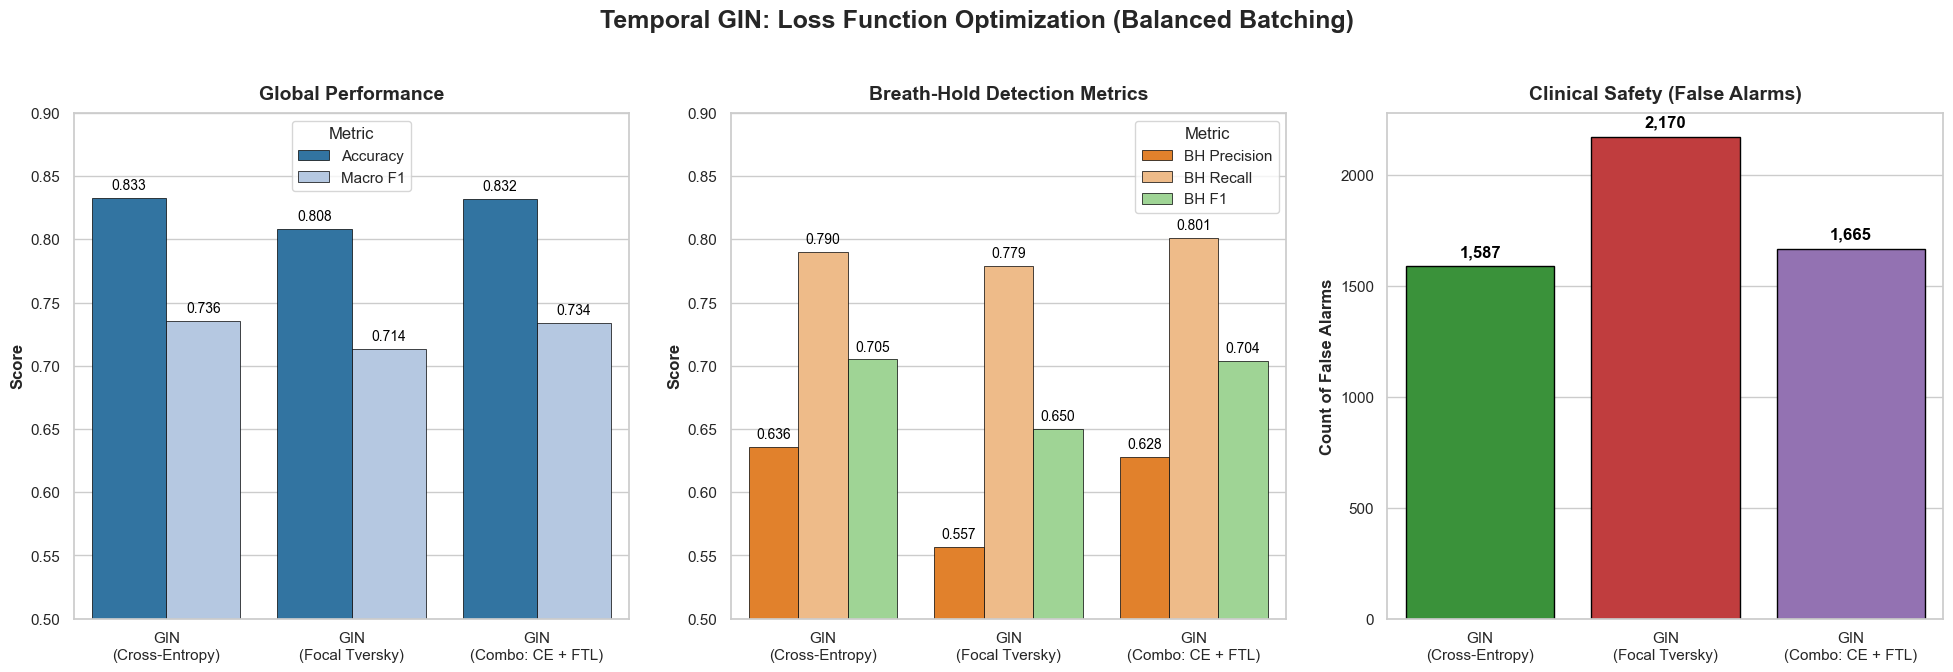

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_gin_comprehensive_comparison():
    # Data extracted exactly from your three GIN logs
    data = {
        'Model': ['GIN\n(Cross-Entropy)', 'GIN\n(Focal Tversky)', 'GIN\n(Combo: CE + FTL)'],
        'Accuracy': [0.8330, 0.8080, 0.8316],
        'Macro F1': [0.7355, 0.7135, 0.7341],
        'BH Precision': [0.636, 0.557, 0.628],
        'BH Recall': [0.790, 0.779, 0.801],
        'BH F1': [0.705, 0.650, 0.704],
        'False Alarms': [1587, 2170, 1665] # Calculated from (Actual NB -> Pred BH) + (Actual DB -> Pred BH)
    }

    df = pd.DataFrame(data)

    # Set plotting style
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(20, 7))
    plt.suptitle('Temporal GIN: Loss Function Optimization (Balanced Batching)', fontsize=18, fontweight='bold', y=0.98)

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 1: Overall Performance (Macro F1 & Accuracy)
    # ─────────────────────────────────────────────────────────────────────────────
    ax1 = plt.subplot(1, 3, 1)
    df_global = df[['Model', 'Accuracy', 'Macro F1']].melt(id_vars='Model', var_name='Metric', value_name='Score')
    sns.barplot(data=df_global, x='Model', y='Score', hue='Metric', palette=['#1f77b4', '#aec7e8'], ax=ax1, edgecolor='black', linewidth=0.5)

    ax1.set_title('Global Performance', fontsize=14, fontweight='bold', pad=10)
    ax1.set_ylim(0.50, 0.90)
    ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax1.set_xlabel('')

    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 4), textcoords='offset points')

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 2: Breath-Hold Detection Power
    # ─────────────────────────────────────────────────────────────────────────────
    ax2 = plt.subplot(1, 3, 2)
    df_bh = df[['Model', 'BH Precision', 'BH Recall', 'BH F1']].melt(id_vars='Model', var_name='Metric', value_name='Score')
    sns.barplot(data=df_bh, x='Model', y='Score', hue='Metric', palette=['#ff7f0e', '#ffbb78', '#98df8a'], ax=ax2, edgecolor='black', linewidth=0.5)

    ax2.set_title('Breath-Hold Detection Metrics', fontsize=14, fontweight='bold', pad=10)
    ax2.set_ylim(0.50, 0.90)
    ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax2.set_xlabel('')

    for p in ax2.patches:
        ax2.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 4), textcoords='offset points')

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 3: Alarm Fatigue (False Alarms)
    # ─────────────────────────────────────────────────────────────────────────────
    ax3 = plt.subplot(1, 3, 3)
    sns.barplot(data=df, x='Model', y='False Alarms', palette=['#2ca02c', '#d62728', '#9467bd'], ax=ax3, edgecolor='black', linewidth=1)

    ax3.set_title('Clinical Safety (False Alarms)', fontsize=14, fontweight='bold', pad=10)
    ax3.set_ylabel('Count of False Alarms', fontsize=12, fontweight='bold')
    ax3.set_xlabel('')

    for p in ax3.patches:
        ax3.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

    plt.tight_layout(pad=2.0)
    plt.show()

if __name__ == "__main__":
    plot_gin_comprehensive_comparison()

**Feature Similarity Graph**

Loading dataset...
Building Feature Similarity Graph for Subject: S_6 (K=5)
Rendering PCA network diagram...
Success! Saved to 'Feature_Similarity_PCA_Graph_S_6.png'


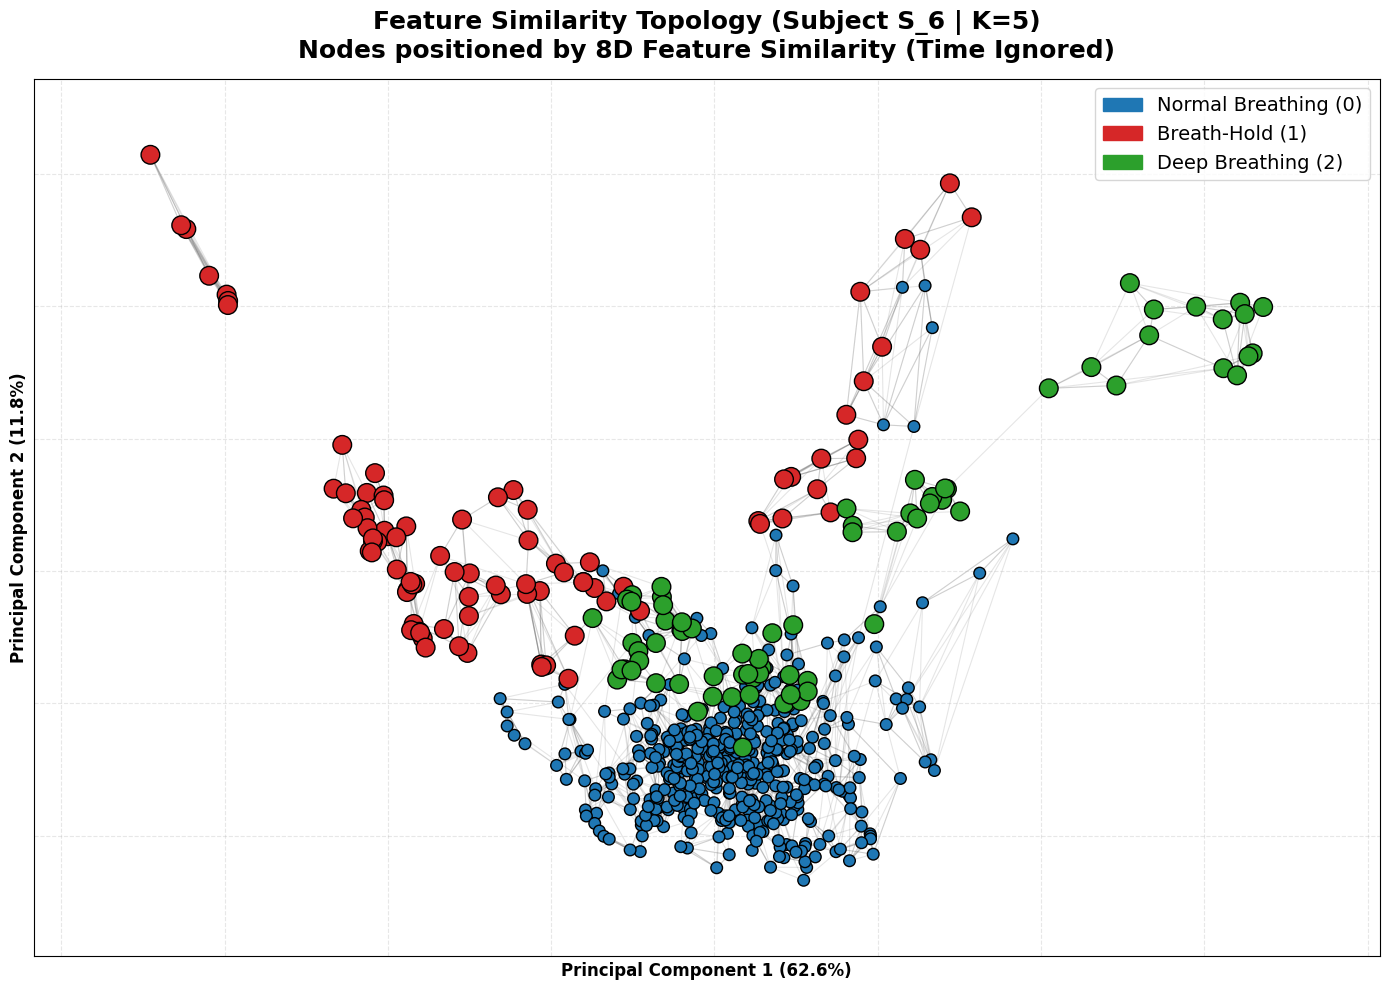

In [ ]:
import pandas as pd
import numpy as np
import torch
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from torch_geometric.data import Data

# ─────────────────────────────────────────────────────────────────────────────
# 1. PURE PYTORCH K-NN IMPLEMENTATION (Bypasses torch-cluster)
# ─────────────────────────────────────────────────────────────────────────────
def custom_knn_graph(x: torch.Tensor, k: int) -> torch.Tensor:
    """
    Computes a k-NN graph using pure PyTorch operations.
    Calculates pairwise Euclidean distance between all nodes in the 8D space.
    """
    # Compute pairwise distance matrix
    dist = torch.cdist(x, x, p=2)
    
    num_nodes = x.size(0)
    edge_sources = []
    edge_targets = []
    
    # For each node, find the 'k' closest neighbors
    for i in range(num_nodes):
        # We use k+1 to account for the distance to itself (which is 0)
        _, indices = torch.topk(dist[i], k=k + 1, largest=False)
        
        for j in indices:
            if i != j: # Ignore self-loops
                edge_sources.append(i)
                edge_targets.append(j.item())
                
    return torch.tensor([edge_sources, edge_targets], dtype=torch.long)


def build_similarity_subject_graph(subject_df: pd.DataFrame, features: list, k_neighbors: int = 5) -> tuple:
    df_sorted = subject_df.sort_values("Timestamp_Sec").reset_index(drop=True)
    
    # Mandatory Scaling (Crucial for Euclidean distance)
    X_raw = df_sorted[features].fillna(0).values
    X_scaled = StandardScaler().fit_transform(X_raw)
        
    X = torch.tensor(X_scaled, dtype=torch.float)
    y = torch.tensor(df_sorted["y"].values, dtype=torch.long)
    
    # Use the custom k-NN builder
    edge_index = custom_knn_graph(X, k=k_neighbors)
    
    return Data(x=X, y=y, edge_index=edge_index), X_scaled


# ─────────────────────────────────────────────────────────────────────────────
# 2. PCA FEATURE SPACE VISUALIZATION SCRIPT
# ─────────────────────────────────────────────────────────────────────────────
def plot_feature_similarity_graph(csv_path="BH_DB_Features_WS20.csv", k_neighbors=5):
    print("Loading dataset...")
    df = pd.read_csv(csv_path)
    class_map = {"NB": 0, "BH": 1, "DB": 2}
    df["y"] = df["Category"].map(class_map)
    
    # The 8 clinical features driving the Euclidean distance
    features = ["pNN50_Ratio", "pNN50_Delta", "HF_Ratio", "RMSSD_Ratio", 
                "Mean_RR_Ratio", "Shannon_Entropy_Ratio", "EDR_Std_Amp_Ratio", "EDR_Mean_Amp_Delta"]

    subject_id = df["Subject"].unique()[0]
    print(f"Building Feature Similarity Graph for Subject: {subject_id} (K={k_neighbors})")
    
    sub_df = df[df["Subject"] == subject_id].copy().reset_index(drop=True)
    
    # Build PyG Graph
    pyg_graph, X_scaled = build_similarity_subject_graph(sub_df, features, k_neighbors=k_neighbors)
    
    num_nodes = pyg_graph.num_nodes
    edges = pyg_graph.edge_index.numpy().T
    y_vals = pyg_graph.y.numpy()
    
    # ── Compress 8D Features to 2D for Visual Plotting (PCA) ──
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    var_explained = sum(pca.explained_variance_ratio_) * 100
    
    # ── Initialize NetworkX ──
    G = nx.DiGraph()
    G.add_nodes_from(range(num_nodes))
    G.add_edges_from(edges)
    
    # Place nodes EXACTLY at their PCA coordinates (Ignoring Time)
    pos = {i: (X_pca[i, 0], X_pca[i, 1]) for i in range(num_nodes)}
    
    color_map = {0: '#1f77b4', 1: '#d62728', 2: '#2ca02c'} # Blue=NB, Red=BH, Green=DB
    node_colors = [color_map[y] for y in y_vals]
    
    # ── Figure Setup ──
    fig, ax = plt.subplots(figsize=(14, 10))
    
    print("Rendering PCA network diagram...")
    
    # Draw Edges (Straight lines, highly visible web)
    nx.draw_networkx_edges(G, pos, edge_color='#555555', alpha=0.15, width=0.8, arrows=False, ax=ax)

    # Draw Nodes (Minority classes drawn larger to highlight their clusters)
    node_sizes = [70 if y == 0 else 180 for y in y_vals]
    
    # Draw layer by layer to ensure Red/Green nodes are on top of the Blue cloud
    for target_class in [0, 1, 2]:
        n_list = [n for n in range(num_nodes) if y_vals[n] == target_class]
        c_list = [node_colors[n] for n in n_list]
        s_list = [node_sizes[n] for n in n_list]
        
        nx.draw_networkx_nodes(G, pos, nodelist=n_list, node_color=c_list, 
                               node_size=s_list, edgecolors='black', linewidths=1.0, ax=ax)

    # Styling
    plt.title(f'Feature Similarity Topology (Subject {subject_id} | K={k_neighbors})\nNodes positioned by 8D Feature Similarity (Time Ignored)', 
              fontsize=18, fontweight='bold', pad=15)
    
    plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12, fontweight='bold')
    plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12, fontweight='bold')
    
    # Legend
    nb_patch = mpatches.Patch(color='#1f77b4', label='Normal Breathing (0)')
    bh_patch = mpatches.Patch(color='#d62728', label='Breath-Hold (1)')
    db_patch = mpatches.Patch(color='#2ca02c', label='Deep Breathing (2)')
    plt.legend(handles=[nb_patch, bh_patch, db_patch], loc='best', fontsize=14)

    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    
    out_file = f'Feature_Similarity_PCA_Graph_{subject_id}.png'
    plt.savefig(out_file, dpi=300, bbox_inches='tight')
    print(f"Success! Saved to '{out_file}'")
    plt.show()

if __name__ == "__main__":
    plot_feature_similarity_graph(k_neighbors=5)

In [ ]:
"""
STEP 1: FEATURE SIMILARITY GRAPH CONSTRUCTION UTILITIES
========================================================

This module provides the core functions to build graphs where edges are determined
by feature similarity (k-NN in 8D space) rather than temporal proximity.

The mathematical foundation:
1. For each node n_i with feature vector x_i ∈ ℝ^8
2. Compute Euclidean distance to all other nodes: d(x_i, x_j) = ||x_i - x_j||_2
3. Connect to the k nearest neighbors with smallest d(x_i, x_j)

This approach: 
- Discovers global respiratory pattern similarities
- Is invariant to recording duration (5-sec vs. 40-sec breath-hold have same features)
- Allows state-based message passing (collect evidence from all similar windows)
"""

import torch
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch_geometric.data import Data


def build_custom_knn_graph(x: torch.Tensor, k: int) -> torch.Tensor:
    """
    Pure PyTorch k-NN graph builder (no torch_cluster dependency).
    
    Inputs:
      x: Node features of shape (num_nodes, num_features=8)
      k: Number of nearest neighbors to connect to each node
      
    Output:
      edge_index: Tensor of shape (2, num_edges) representing directed edges
      
    Algorithm:
      For each node i:
        1. Compute Euclidean distance to all other nodes
        2. Find indices of k closest neighbors (excluding self)
        3. Create directed edges i -> neighbor
    """
    dist = torch.cdist(x, x, p=2)  # Pairwise Euclidean distance
    
    num_nodes = x.size(0)
    edge_sources = []
    edge_targets = []
    
    for i in range(num_nodes):
        # topk finds the k+1 smallest distances (including distance to self = 0)
        _, neighbor_indices = torch.topk(dist[i], k=k + 1, largest=False)
        
        for j in neighbor_indices:
            j_val = j.item()
            if i != j_val:  # Exclude self-loops
                edge_sources.append(i)
                edge_targets.append(j_val)
    
    edge_index = torch.tensor([edge_sources, edge_targets], dtype=torch.long)
    return edge_index


def build_similarity_subject_graph(
    subject_df: pd.DataFrame,
    features: list,
    scaler: StandardScaler,
    is_train: bool = True,
    k_neighbors: int = 5,
    bidirectional: bool = True
) -> Data:
    """
    Constructs a Feature Similarity Graph for single subject.
    
    Inputs:
      subject_df: DataFrame with rows = time windows, columns = features + metadata
      features: List of 8 feature column names to use for distance calculation
      scaler: StandardScaler instance (fitted on training data, transforms test)
      is_train: If True, fits scaler; if False, applies existing scaler
      k_neighbors: Number of nearest neighbors to connect each node to
      bidirectional: If True, adds reverse edges (undirected graph approximation)
      
    Output:
      PyG Data object with:
        .x: Scaled node features (num_nodes, 8)
        .y: Class labels (num_nodes,)  [0=NB, 1=BH, 2=DB]
        .edge_index: Feature similarity edges (2, num_edges)
    """
    # Sort by timestamp to maintain temporal metadata (though edges ignore it)
    df_sorted = subject_df.sort_values("Timestamp_Sec").reset_index(drop=True)
    
    # Extract and scale features
    X_raw = df_sorted[features].fillna(0).values
    
    if is_train:
        X_scaled = scaler.fit_transform(X_raw)
    else:
        X_scaled = scaler.transform(X_raw)
    
    X = torch.tensor(X_scaled, dtype=torch.float)
    y = torch.tensor(df_sorted["y"].values, dtype=torch.long)
    
    # Build the k-NN graph based on Euclidean distance in feature space
    edge_index = build_custom_knn_graph(X, k=k_neighbors)
    
    # Optional: Add reverse edges to make graph undirected
    # (Each original edge i->j gets a reverse j->i)
    if bidirectional and edge_index.shape[1] > 0:
        edge_index_reverse = torch.stack([edge_index[1], edge_index[0]])
        edge_index = torch.cat([edge_index, edge_index_reverse], dim=1)
    
    return Data(x=X, y=y, edge_index=edge_index)


print("✓ Feature Similarity Graph utilities loaded successfully")
print("  - build_custom_knn_graph: Pure PyTorch k-NN implementation")
print("  - build_similarity_subject_graph: Full PyG Data factory function")


c:\Users\ejisg\anaconda3\envs\ecg\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Feature Similarity Graph utilities loaded successfully
  - build_custom_knn_graph: Pure PyTorch k-NN implementation
  - build_similarity_subject_graph: Full PyG Data factory function


In [ ]:
"""
GCN WITH FEATURE SIMILARITY GRAPH + CROSS-ENTROPY LOSS
═══════════════════════════════════════════════════════════════════════════
This implementation replaces temporal edges with feature similarity (k-NN).
Everything else remains identical: GCNConv layers, balanced batching, LOSO eval.
"""

import os
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.nn import Linear, CrossEntropyLoss
from torch.utils.data import WeightedRandomSampler
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GCNConv
from torch_geometric.loader import NeighborLoader
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    accuracy_score, confusion_matrix, roc_auc_score,
    average_precision_score,
)

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
#  CONFIG: GCN Feature Similarity
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV_FS    = "BH_DB_Features_WS20.csv"
RANDOM_SEED_FS  = 42

torch.manual_seed(RANDOM_SEED_FS)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED_FS)

CLASS_MAP_FS   = {"NB": 0, "BH": 1, "DB": 2}
CLASSES_FS     = [0, 1, 2]
CLASS_NAMES_FS = {0: "NB", 1: "BH", 2: "DB"}

G_LIST_FS = [
    "pNN50_Ratio", "pNN50_Delta", "HF_Ratio",                
    "RMSSD_Ratio", "Mean_RR_Ratio", "Shannon_Entropy_Ratio",   
    "EDR_Std_Amp_Ratio", "EDR_Mean_Amp_Delta"       
]

# GCN Hyperparameters
HIDDEN_DIM_FS    = 64
EPOCHS_FS        = 40
BATCH_SIZE_FS    = 256
LEARNING_RATE_FS = 0.005
WEIGHT_DECAY_FS  = 1e-4
K_NEIGHBORS_FS   = 5      # Feature similarity parameter: connect to 5 most similar nodes
BIDIRECTIONAL_FS = True   # Add reverse edges for undirected graph

WINSORISE_FS  = True  
WINSOR_LO_FS  = 0.01
WINSOR_HI_FS  = 0.99

DEVICE_FS = torch.device('cpu')

print(f"GCN Feature Similarity Configuration:")
print(f"  K_NEIGHBORS: {K_NEIGHBORS_FS} (connect each node to {K_NEIGHBORS_FS} most similar)")
print(f"  BIDIRECTIONAL: {BIDIRECTIONAL_FS}")
print(f"  DEVICE: {DEVICE_FS}")


# ─────────────────────────────────────────────────────────────────────────────
#  HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def winsorise_fold_fs(X_tr: np.ndarray, X_te: np.ndarray, lo: float, hi: float):
    lo_vals = np.percentile(X_tr, lo * 100, axis=0)
    hi_vals = np.percentile(X_tr, hi * 100, axis=0)
    X_tr_c = np.clip(X_tr, lo_vals, hi_vals)
    X_te_c = np.clip(X_te, lo_vals, hi_vals)
    return X_tr_c, X_te_c

def enforce_minimum_duration_fs(preds: np.ndarray, target_class: int, min_length: int) -> np.ndarray:
    filtered_preds = preds.copy()
    in_event = False
    start_idx = 0
    for i in range(len(filtered_preds)):
        if filtered_preds[i] == target_class and not in_event:
            in_event = True
            start_idx = i
        elif filtered_preds[i] != target_class and in_event:
            in_event = False
            if (i - start_idx) < min_length:
                filtered_preds[start_idx:i] = 0 
    if in_event and (len(filtered_preds) - start_idx) < min_length:
        filtered_preds[start_idx:] = 0
    return filtered_preds

def create_balanced_loader_fs(train_graphs: list, batch_size: int) -> NeighborLoader:
    train_data = Batch.from_data_list(train_graphs)
    
    class_counts = torch.bincount(train_data.y)
    class_weights = 1.0 / class_counts.float()
    sample_weights = class_weights[train_data.y]
    
    sampler = WeightedRandomSampler(
        weights=sample_weights, 
        num_samples=len(train_data.y), 
        replacement=True
    )
    balanced_node_indices = torch.tensor(list(sampler), dtype=torch.long)
    
    loader = NeighborLoader(
        train_data,
        num_neighbors=[10, 10], 
        batch_size=batch_size,
        input_nodes=balanced_node_indices,
        shuffle=False 
    )
    return loader


# ─────────────────────────────────────────────────────────────────────────────
#  ARCHITECTURE
# ─────────────────────────────────────────────────────────────────────────────

class ClinicalGCNFeatureSimilarity(torch.nn.Module):
    def __init__(self, num_features: int, hidden_dim: int, num_classes: int):
        super().__init__()
        self.conv1 = GCNConv(num_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.classifier = Linear(hidden_dim, num_classes)
        self.dropout = torch.nn.Dropout(p=0.3)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        out = self.classifier(x)
        return out


# ─────────────────────────────────────────────────────────────────────────────
#  LOSO EVALUATION: GCN with Feature Similarity + Cross-Entropy Loss
# ─────────────────────────────────────────────────────────────────────────────

def run_gcn_fs_ce_loso(df: pd.DataFrame, features: list) -> None:
    subjects = sorted(df["Subject"].unique())
    all_y_true, all_y_prob, all_y_pred = [], [], []

    print("\n" + "═" * 115)
    print(f"  CLINICAL LOSO: GCN + FEATURE SIMILARITY GRAPH (k={K_NEIGHBORS_FS}) | DEVICE: {DEVICE_FS}")
    print(f"  Balanced NeighborLoader + Cross-Entropy Loss")
    print("═" * 115)

    header = (
        f"  {'Sub':6s} | {'N_NB':>5} | {'N_BH':>5} | {'N_DB':>5} | "
        f"{'Acc':>5} | {'Mac_P':>5} | {'Mac_R':>5} | {'Mac_F1':>6} | "
        f"{'BH_Rec':>6} | {'BH_Pre':>6} | {'BH_F1':>6}"
    )
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:
        tr_df = df[df["Subject"] != test_sub].copy()
        te_df = df[df["Subject"] == test_sub].copy()

        if WINSORISE_FS:
            X_tr_raw = tr_df[features].values
            X_te_raw = te_df[features].values
            X_tr_w, X_te_w = winsorise_fold_fs(X_tr_raw, X_te_raw, WINSOR_LO_FS, WINSOR_HI_FS)
            tr_df.loc[:, features] = X_tr_w
            te_df.loc[:, features] = X_te_w

        scaler = StandardScaler()
        
        train_graphs = []
        for sub in tr_df["Subject"].unique():
            sub_df = tr_df[tr_df["Subject"] == sub]
            is_first = (sub == tr_df["Subject"].unique()[0])
            train_graphs.append(build_similarity_subject_graph(
                sub_df, features, scaler, is_train=is_first, 
                k_neighbors=K_NEIGHBORS_FS, bidirectional=BIDIRECTIONAL_FS
            ))
            
        test_graph = build_similarity_subject_graph(
            te_df, features, scaler, is_train=False,
            k_neighbors=K_NEIGHBORS_FS, bidirectional=BIDIRECTIONAL_FS
        ).to(DEVICE_FS)
        
        train_loader = create_balanced_loader_fs(train_graphs, BATCH_SIZE_FS)

        model = ClinicalGCNFeatureSimilarity(num_features=len(features), hidden_dim=HIDDEN_DIM_FS, num_classes=3).to(DEVICE_FS)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE_FS, weight_decay=WEIGHT_DECAY_FS)
        criterion = CrossEntropyLoss().to(DEVICE_FS)

        model.train()
        for epoch in range(EPOCHS_FS):
            for batch in train_loader:
                batch = batch.to(DEVICE_FS)
                optimizer.zero_grad()
                out = model(batch.x, batch.edge_index)
                loss = criterion(out[:batch.batch_size], batch.y[:batch.batch_size])
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            out = model(test_graph.x, test_graph.edge_index)
            probs = F.softmax(out, dim=1).cpu().numpy()
            raw_preds = np.argmax(probs, axis=1)

        pred_cal = enforce_minimum_duration_fs(raw_preds, target_class=1, min_length=5)
        pred_cal = enforce_minimum_duration_fs(pred_cal, target_class=2, min_length=3)

        y_te = test_graph.y.cpu().numpy()

        n_nb = int((y_te == 0).sum())
        n_bh = int((y_te == 1).sum())
        n_db = int((y_te == 2).sum())

        acc     = accuracy_score(y_te, pred_cal)
        mac_p   = precision_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_r   = recall_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_f1  = f1_score(y_te, pred_cal, average="macro", zero_division=0)

        bh_rec  = recall_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_pre  = precision_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_f1   = f1_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]

        print(
            f"  {test_sub:6s} | {n_nb:5d} | {n_bh:5d} | {n_db:5d} | "
            f"{acc:5.3f} | {mac_p:5.3f} | {mac_r:5.3f} | {mac_f1:6.3f} | "
            f"{bh_rec:6.3f} | {bh_pre:6.3f} | {bh_f1:6.3f}"
        )

        all_y_true.extend(y_te.tolist())
        all_y_prob.extend(probs.tolist())
        all_y_pred.extend(pred_cal.tolist())

    print("  " + "─" * (len(header) - 2))

    y_true = np.array(all_y_true)
    y_prob = np.array(all_y_prob)
    y_pred = np.array(all_y_pred)

    y_bin = label_binarize(y_true, classes=CLASSES_FS)

    auroc = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    auprc = average_precision_score(y_bin, y_prob, average="macro")

    acc     = accuracy_score(y_true, y_pred)
    mac_p   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    mac_r   = recall_score(y_true, y_pred, average="macro", zero_division=0)
    mac_f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)

    bh_rec  = recall_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_pre  = precision_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_f1   = f1_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]

    db_rec  = recall_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_pre  = precision_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_f1   = f1_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]

    nb_rec  = recall_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]
    nb_pre  = precision_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]

    print()
    print("  ── GCN FEATURE SIMILARITY OVERALL RESULTS ──")
    print(f"     AUROC (OVR)     = {auroc:.4f}")
    print(f"     AUPRC           = {auprc:.4f}")
    print(f"     Accuracy        = {acc:.4f}")
    print(f"     Macro Precision = {mac_p:.4f}")
    print(f"     Macro Recall    = {mac_r:.4f}")
    print(f"     Macro F1        = {mac_f1:.4f}")
    print()
    print("  ── PER-CLASS BREAKDOWN ──")
    print(f"     NB  : Recall={nb_rec:.3f}  Precision={nb_pre:.3f}")
    print(f"     BH  : Recall={bh_rec:.3f}  Precision={bh_pre:.3f}  F1={bh_f1:.3f}")
    print(f"     DB  : Recall={db_rec:.3f}  Precision={db_pre:.3f}  F1={db_f1:.3f}")

    cm = confusion_matrix(y_true, y_pred, labels=CLASSES_FS)
    print()
    print("  ── CONFUSION MATRIX ──")
    print(f"  {'':20s}  {'Pred NB':>10}  {'Pred BH':>10}  {'Pred DB':>10}")
    for i, name in CLASS_NAMES_FS.items():
        row = cm[i]
        print(f"  Actual {name} ({i})         {row[0]:>10}  {row[1]:>10}  {row[2]:>10}")
    print("═" * 115)


# EXECUTE
if __name__ == "__main__":
    if not os.path.exists(INPUT_CSV_FS):
        raise FileNotFoundError(f"Dataset not found: {INPUT_CSV_FS}")

    df = pd.read_csv(INPUT_CSV_FS)
    df["y"] = df["Category"].map(CLASS_MAP_FS)
    features = G_LIST_FS

    print(f"  [+] Running GCN Feature Similarity + Cross-Entropy Loss...")
    run_gcn_fs_ce_loso(df, features)


GCN Feature Similarity Configuration:
  K_NEIGHBORS: 5 (connect each node to 5 most similar)
  BIDIRECTIONAL: True
  DEVICE: cpu
  [+] Running GCN Feature Similarity + Cross-Entropy Loss...

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  CLINICAL LOSO: GCN + FEATURE SIMILARITY GRAPH (k=5) | DEVICE: cpu
  Balanced NeighborLoader + Cross-Entropy Loss
═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Sub    |  N_NB |  N_BH |  N_DB |   Acc | Mac_P | Mac_R | Mac_F1 | BH_Rec | BH_Pre |  BH_F1
  ──────────────────────────────────────────────────────────────────────────────────────────
  S_10   |   469 |    40 |    75 | 0.834 | 0.588 | 0.602 |  0.595 |  0.325 |  0.289 |  0.306
  S_11   |   497 |    90 |    72 | 0.901 | 0.839 | 0.816 |  0.827 |  0.922 |  0.933 |  0.927
  S_14   |   497 |    90 |    79 | 0.875 | 0.810 | 0.809 |  0.804 |  0.856 |  1.000 |  0.9

In [ ]:
"""
GCN WITH FEATURE SIMILARITY GRAPH + FOCAL TVERSKY LOSS
═══════════════════════════════════════════════════════════════════════════
Exact same architecture and graph construction as above, but with FTL loss.
"""

import torch.nn as nn

# ─────────────────────────────────────────────────────────────────────────────
#  CONFIG: GCN Feature Similarity + FTL
# ─────────────────────────────────────────────────────────────────────────────
FTL_ALPHA_FS    = 0.3   
FTL_BETA_FS     = 0.7   
FTL_GAMMA_FS    = 1.3   


# ─────────────────────────────────────────────────────────────────────────────
#  CUSTOM FOCAL TVERSKY LOSS
# ─────────────────────────────────────────────────────────────────────────────

class FocalTverskyLossFS(nn.Module):
    def __init__(self, alpha: float, beta: float, gamma: float, smooth: float = 1e-6):
        super(FocalTverskyLossFS, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        num_classes = logits.shape[1]
        targets_one_hot = F.one_hot(targets, num_classes=num_classes).float()
        
        total_loss = 0.0
        for c in range(num_classes):
            prob_c = probs[:, c]
            target_c = targets_one_hot[:, c]
            
            TP = (prob_c * target_c).sum()
            FP = ((1 - target_c) * prob_c).sum()
            FN = (target_c * (1 - prob_c)).sum()
            
            Tversky = (TP + self.smooth) / (TP + self.alpha * FP + self.beta * FN + self.smooth)
            FocalTversky = (1 - Tversky) ** self.gamma
            total_loss += FocalTversky
            
        return total_loss / num_classes


# ─────────────────────────────────────────────────────────────────────────────
#  LOSO EVALUATION: GCN Feature Similarity + Focal Tversky Loss
# ─────────────────────────────────────────────────────────────────────────────

def run_gcn_fs_ftl_loso(df: pd.DataFrame, features: list) -> None:
    subjects = sorted(df["Subject"].unique())
    all_y_true, all_y_prob, all_y_pred = [], [], []

    print("\n" + "═" * 115)
    print(f"  CLINICAL LOSO: GCN + FEATURE SIMILARITY GRAPH (k={K_NEIGHBORS_FS}) | DEVICE: {DEVICE_FS}")
    print(f"  Balanced NeighborLoader + Focal Tversky Loss (α={FTL_ALPHA_FS}, β={FTL_BETA_FS}, γ={FTL_GAMMA_FS})")
    print("═" * 115)

    header = (
        f"  {'Sub':6s} | {'N_NB':>5} | {'N_BH':>5} | {'N_DB':>5} | "
        f"{'Acc':>5} | {'Mac_P':>5} | {'Mac_R':>5} | {'Mac_F1':>6} | "
        f"{'BH_Rec':>6} | {'BH_Pre':>6} | {'BH_F1':>6}"
    )
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:
        tr_df = df[df["Subject"] != test_sub].copy()
        te_df = df[df["Subject"] == test_sub].copy()

        if WINSORISE_FS:
            X_tr_raw = tr_df[features].values
            X_te_raw = te_df[features].values
            X_tr_w, X_te_w = winsorise_fold_fs(X_tr_raw, X_te_raw, WINSOR_LO_FS, WINSOR_HI_FS)
            tr_df.loc[:, features] = X_tr_w
            te_df.loc[:, features] = X_te_w

        scaler = StandardScaler()
        
        train_graphs = []
        for sub in tr_df["Subject"].unique():
            sub_df = tr_df[tr_df["Subject"] == sub]
            is_first = (sub == tr_df["Subject"].unique()[0])
            train_graphs.append(build_similarity_subject_graph(
                sub_df, features, scaler, is_train=is_first, 
                k_neighbors=K_NEIGHBORS_FS, bidirectional=BIDIRECTIONAL_FS
            ))
            
        test_graph = build_similarity_subject_graph(
            te_df, features, scaler, is_train=False,
            k_neighbors=K_NEIGHBORS_FS, bidirectional=BIDIRECTIONAL_FS
        ).to(DEVICE_FS)
        
        train_loader = create_balanced_loader_fs(train_graphs, BATCH_SIZE_FS)

        model = ClinicalGCNFeatureSimilarity(num_features=len(features), hidden_dim=HIDDEN_DIM_FS, num_classes=3).to(DEVICE_FS)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE_FS, weight_decay=WEIGHT_DECAY_FS)
        criterion = FocalTverskyLossFS(alpha=FTL_ALPHA_FS, beta=FTL_BETA_FS, gamma=FTL_GAMMA_FS).to(DEVICE_FS)

        model.train()
        for epoch in range(EPOCHS_FS):
            for batch in train_loader:
                batch = batch.to(DEVICE_FS)
                optimizer.zero_grad()
                out = model(batch.x, batch.edge_index)
                loss = criterion(out[:batch.batch_size], batch.y[:batch.batch_size])
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            out = model(test_graph.x, test_graph.edge_index)
            probs = F.softmax(out, dim=1).cpu().numpy()
            raw_preds = np.argmax(probs, axis=1)

        pred_cal = enforce_minimum_duration_fs(raw_preds, target_class=1, min_length=5)
        pred_cal = enforce_minimum_duration_fs(pred_cal, target_class=2, min_length=3)

        y_te = test_graph.y.cpu().numpy()

        n_nb = int((y_te == 0).sum())
        n_bh = int((y_te == 1).sum())
        n_db = int((y_te == 2).sum())

        acc     = accuracy_score(y_te, pred_cal)
        mac_p   = precision_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_r   = recall_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_f1  = f1_score(y_te, pred_cal, average="macro", zero_division=0)

        bh_rec  = recall_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_pre  = precision_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_f1   = f1_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]

        print(
            f"  {test_sub:6s} | {n_nb:5d} | {n_bh:5d} | {n_db:5d} | "
            f"{acc:5.3f} | {mac_p:5.3f} | {mac_r:5.3f} | {mac_f1:6.3f} | "
            f"{bh_rec:6.3f} | {bh_pre:6.3f} | {bh_f1:6.3f}"
        )

        all_y_true.extend(y_te.tolist())
        all_y_prob.extend(probs.tolist())
        all_y_pred.extend(pred_cal.tolist())

    print("  " + "─" * (len(header) - 2))

    y_true = np.array(all_y_true)
    y_prob = np.array(all_y_prob)
    y_pred = np.array(all_y_pred)

    y_bin = label_binarize(y_true, classes=CLASSES_FS)

    auroc = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    auprc = average_precision_score(y_bin, y_prob, average="macro")

    acc     = accuracy_score(y_true, y_pred)
    mac_p   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    mac_r   = recall_score(y_true, y_pred, average="macro", zero_division=0)
    mac_f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)

    bh_rec  = recall_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_pre  = precision_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_f1   = f1_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]

    db_rec  = recall_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_pre  = precision_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_f1   = f1_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]

    nb_rec  = recall_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]
    nb_pre  = precision_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]

    print()
    print("  ── GCN FEATURE SIMILARITY + FTL OVERALL RESULTS ──")
    print(f"     AUROC (OVR)     = {auroc:.4f}")
    print(f"     AUPRC           = {auprc:.4f}")
    print(f"     Accuracy        = {acc:.4f}")
    print(f"     Macro Precision = {mac_p:.4f}")
    print(f"     Macro Recall    = {mac_r:.4f}")
    print(f"     Macro F1        = {mac_f1:.4f}")
    print()
    print("  ── PER-CLASS BREAKDOWN ──")
    print(f"     NB  : Recall={nb_rec:.3f}  Precision={nb_pre:.3f}")
    print(f"     BH  : Recall={bh_rec:.3f}  Precision={bh_pre:.3f}  F1={bh_f1:.3f}")
    print(f"     DB  : Recall={db_rec:.3f}  Precision={db_pre:.3f}  F1={db_f1:.3f}")

    cm = confusion_matrix(y_true, y_pred, labels=CLASSES_FS)
    print()
    print("  ── CONFUSION MATRIX ──")
    print(f"  {'':20s}  {'Pred NB':>10}  {'Pred BH':>10}  {'Pred DB':>10}")
    for i, name in CLASS_NAMES_FS.items():
        row = cm[i]
        print(f"  Actual {name} ({i})         {row[0]:>10}  {row[1]:>10}  {row[2]:>10}")
    print("═" * 115)


# EXECUTE
if __name__ == "__main__":
    if not os.path.exists(INPUT_CSV_FS):
        raise FileNotFoundError(f"Dataset not found: {INPUT_CSV_FS}")

    df = pd.read_csv(INPUT_CSV_FS)
    df["y"] = df["Category"].map(CLASS_MAP_FS)
    features = G_LIST_FS

    print(f"  [+] Running GCN Feature Similarity + Focal Tversky Loss...")
    run_gcn_fs_ftl_loso(df, features)


  [+] Running GCN Feature Similarity + Focal Tversky Loss...

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  CLINICAL LOSO: GCN + FEATURE SIMILARITY GRAPH (k=5) | DEVICE: cpu
  Balanced NeighborLoader + Focal Tversky Loss (α=0.3, β=0.7, γ=1.3)
═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Sub    |  N_NB |  N_BH |  N_DB |   Acc | Mac_P | Mac_R | Mac_F1 | BH_Rec | BH_Pre |  BH_F1
  ──────────────────────────────────────────────────────────────────────────────────────────
  S_10   |   469 |    40 |    75 | 0.896 | 0.844 | 0.782 |  0.790 |  0.525 |  0.913 |  0.667
  S_11   |   497 |    90 |    72 | 0.876 | 0.788 | 0.839 |  0.809 |  0.989 |  0.937 |  0.962
  S_14   |   497 |    90 |    79 | 0.853 | 0.789 | 0.659 |  0.708 |  0.656 |  1.000 |  0.792
  S_15   |   512 |    90 |    71 | 0.918 | 0.899 | 0.847 |  0.851 |  0.589 |  1.000 |  0.741
  S_16   | 

C:\Users\ejisg\AppData\Local\Temp\ipykernel_2572\2100513586.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Model', y='False Alarms', palette=['#2ca02c', '#d62728'], ax=ax2, edgecolor='black', linewidth=1)


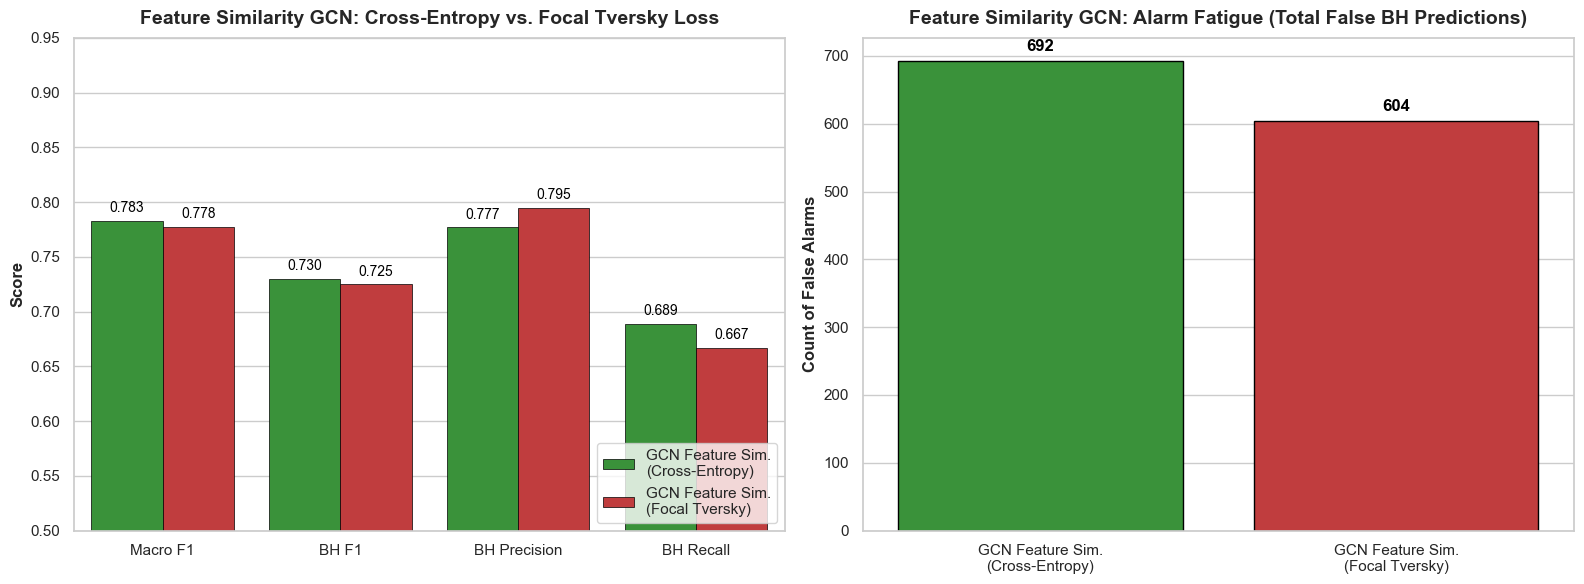

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_gcn_featuresim_comparison():
    # Data extracted from the GCN Feature Similarity logs
    data = {
        'Model': ['GCN Feature Sim.\n(Cross-Entropy)', 'GCN Feature Sim.\n(Focal Tversky)'],
        'Accuracy': [0.8788, 0.8748],
        'Macro F1': [0.7832, 0.7777],
        'BH Precision': [0.777, 0.795],
        'BH Recall': [0.689, 0.667],
        'BH F1': [0.730, 0.725],
        'False Alarms': [692, 604] # Calculated from (NB->BH + DB->BH)
    }

    df = pd.DataFrame(data)

    # Set plotting style
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(16, 6))

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 1: Predictive Metrics Comparison
    # ─────────────────────────────────────────────────────────────────────────────
    ax1 = plt.subplot(1, 2, 1)
    df_metrics = df[['Model', 'Macro F1', 'BH F1', 'BH Precision', 'BH Recall']].melt(id_vars='Model', var_name='Metric', value_name='Score')
    sns.barplot(data=df_metrics, x='Metric', y='Score', hue='Model', palette=['#2ca02c', '#d62728'], ax=ax1, edgecolor='black', linewidth=0.5)

    ax1.set_title('Feature Similarity GCN: Cross-Entropy vs. Focal Tversky Loss', fontsize=14, fontweight='bold', pad=10)
    ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax1.set_xlabel('')
    ax1.set_ylim(0.50, 0.95)

    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 4), textcoords='offset points')
    ax1.legend(loc='lower right')

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 2: Alarm Fatigue (False Alarms)
    # ─────────────────────────────────────────────────────────────────────────────
    ax2 = plt.subplot(1, 2, 2)
    sns.barplot(data=df, x='Model', y='False Alarms', palette=['#2ca02c', '#d62728'], ax=ax2, edgecolor='black', linewidth=1)

    ax2.set_title('Feature Similarity GCN: Alarm Fatigue (Total False BH Predictions)', fontsize=14, fontweight='bold', pad=10)
    ax2.set_ylabel('Count of False Alarms', fontsize=12, fontweight='bold')
    ax2.set_xlabel('')

    for p in ax2.patches:
        ax2.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_gcn_featuresim_comparison()

In [ ]:
"""
GCN WITH FEATURE SIMILARITY GRAPH + COMBO LOSS (CE + FTL)
═══════════════════════════════════════════════════════════════════════════
Combines Cross-Entropy and Focal Tversky Loss for balanced optimization.
"""

# ─────────────────────────────────────────────────────────────────────────────
#  CONFIG: GCN Feature Similarity + Combo Loss
# ─────────────────────────────────────────────────────────────────────────────
COMBO_ALPHA_FS  = 0.5   # 50% CE, 50% FTL


class ComboLossFS(nn.Module):
    """Combines Cross Entropy with Focal Tversky Loss"""
    def __init__(self, combo_alpha=0.5, ftl_alpha=0.3, ftl_beta=0.7, ftl_gamma=1.3):
        super(ComboLossFS, self).__init__()
        self.combo_alpha = combo_alpha
        self.ce = nn.CrossEntropyLoss()
        self.ftl = FocalTverskyLossFS(alpha=ftl_alpha, beta=ftl_beta, gamma=ftl_gamma)

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        ftl_loss = self.ftl(logits, targets)
        return (self.combo_alpha * ce_loss) + ((1 - self.combo_alpha) * ftl_loss)


# ─────────────────────────────────────────────────────────────────────────────
#  LOSO EVALUATION: GCN Feature Similarity + Combo Loss
# ─────────────────────────────────────────────────────────────────────────────

def run_gcn_fs_combo_loso(df: pd.DataFrame, features: list) -> None:
    subjects = sorted(df["Subject"].unique())
    all_y_true, all_y_prob, all_y_pred = [], [], []

    print("\n" + "═" * 115)
    print(f"  CLINICAL LOSO: GCN + FEATURE SIMILARITY GRAPH (k={K_NEIGHBORS_FS}) | DEVICE: {DEVICE_FS}")
    print(f"  Balanced NeighborLoader + Combo Loss ({int(COMBO_ALPHA_FS*100)}% CE, {int((1-COMBO_ALPHA_FS)*100)}% FTL)")
    print("═" * 115)

    header = (
        f"  {'Sub':6s} | {'N_NB':>5} | {'N_BH':>5} | {'N_DB':>5} | "
        f"{'Acc':>5} | {'Mac_P':>5} | {'Mac_R':>5} | {'Mac_F1':>6} | "
        f"{'BH_Rec':>6} | {'BH_Pre':>6} | {'BH_F1':>6}"
    )
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:
        tr_df = df[df["Subject"] != test_sub].copy()
        te_df = df[df["Subject"] == test_sub].copy()

        if WINSORISE_FS:
            X_tr_raw = tr_df[features].values
            X_te_raw = te_df[features].values
            X_tr_w, X_te_w = winsorise_fold_fs(X_tr_raw, X_te_raw, WINSOR_LO_FS, WINSOR_HI_FS)
            tr_df.loc[:, features] = X_tr_w
            te_df.loc[:, features] = X_te_w

        scaler = StandardScaler()
        
        train_graphs = []
        for sub in tr_df["Subject"].unique():
            sub_df = tr_df[tr_df["Subject"] == sub]
            is_first = (sub == tr_df["Subject"].unique()[0])
            train_graphs.append(build_similarity_subject_graph(
                sub_df, features, scaler, is_train=is_first, 
                k_neighbors=K_NEIGHBORS_FS, bidirectional=BIDIRECTIONAL_FS
            ))
            
        test_graph = build_similarity_subject_graph(
            te_df, features, scaler, is_train=False,
            k_neighbors=K_NEIGHBORS_FS, bidirectional=BIDIRECTIONAL_FS
        ).to(DEVICE_FS)
        
        train_loader = create_balanced_loader_fs(train_graphs, BATCH_SIZE_FS)

        model = ClinicalGCNFeatureSimilarity(num_features=len(features), hidden_dim=HIDDEN_DIM_FS, num_classes=3).to(DEVICE_FS)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE_FS, weight_decay=WEIGHT_DECAY_FS)
        criterion = ComboLossFS(
            combo_alpha=COMBO_ALPHA_FS, 
            ftl_alpha=FTL_ALPHA_FS, 
            ftl_beta=FTL_BETA_FS, 
            ftl_gamma=FTL_GAMMA_FS
        ).to(DEVICE_FS)

        model.train()
        for epoch in range(EPOCHS_FS):
            for batch in train_loader:
                batch = batch.to(DEVICE_FS)
                optimizer.zero_grad()
                out = model(batch.x, batch.edge_index)
                loss = criterion(out[:batch.batch_size], batch.y[:batch.batch_size])
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            out = model(test_graph.x, test_graph.edge_index)
            probs = F.softmax(out, dim=1).cpu().numpy()
            raw_preds = np.argmax(probs, axis=1)

        pred_cal = enforce_minimum_duration_fs(raw_preds, target_class=1, min_length=5)
        pred_cal = enforce_minimum_duration_fs(pred_cal, target_class=2, min_length=3)

        y_te = test_graph.y.cpu().numpy()

        n_nb = int((y_te == 0).sum())
        n_bh = int((y_te == 1).sum())
        n_db = int((y_te == 2).sum())

        acc     = accuracy_score(y_te, pred_cal)
        mac_p   = precision_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_r   = recall_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_f1  = f1_score(y_te, pred_cal, average="macro", zero_division=0)

        bh_rec  = recall_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_pre  = precision_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_f1   = f1_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]

        print(
            f"  {test_sub:6s} | {n_nb:5d} | {n_bh:5d} | {n_db:5d} | "
            f"{acc:5.3f} | {mac_p:5.3f} | {mac_r:5.3f} | {mac_f1:6.3f} | "
            f"{bh_rec:6.3f} | {bh_pre:6.3f} | {bh_f1:6.3f}"
        )

        all_y_true.extend(y_te.tolist())
        all_y_prob.extend(probs.tolist())
        all_y_pred.extend(pred_cal.tolist())

    print("  " + "─" * (len(header) - 2))

    y_true = np.array(all_y_true)
    y_prob = np.array(all_y_prob)
    y_pred = np.array(all_y_pred)

    y_bin = label_binarize(y_true, classes=CLASSES_FS)

    auroc = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    auprc = average_precision_score(y_bin, y_prob, average="macro")

    acc     = accuracy_score(y_true, y_pred)
    mac_p   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    mac_r   = recall_score(y_true, y_pred, average="macro", zero_division=0)
    mac_f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)

    bh_rec  = recall_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_pre  = precision_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_f1   = f1_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]

    db_rec  = recall_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_pre  = precision_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_f1   = f1_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]

    nb_rec  = recall_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]
    nb_pre  = precision_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]

    print()
    print("  ── GCN FEATURE SIMILARITY + COMBO OVERALL RESULTS ──")
    print(f"     AUROC (OVR)     = {auroc:.4f}")
    print(f"     AUPRC           = {auprc:.4f}")
    print(f"     Accuracy        = {acc:.4f}")
    print(f"     Macro Precision = {mac_p:.4f}")
    print(f"     Macro Recall    = {mac_r:.4f}")
    print(f"     Macro F1        = {mac_f1:.4f}")
    print()
    print("  ── PER-CLASS BREAKDOWN ──")
    print(f"     NB  : Recall={nb_rec:.3f}  Precision={nb_pre:.3f}")
    print(f"     BH  : Recall={bh_rec:.3f}  Precision={bh_pre:.3f}  F1={bh_f1:.3f}")
    print(f"     DB  : Recall={db_rec:.3f}  Precision={db_pre:.3f}  F1={db_f1:.3f}")

    cm = confusion_matrix(y_true, y_pred, labels=CLASSES_FS)
    print()
    print("  ── CONFUSION MATRIX ──")
    print(f"  {'':20s}  {'Pred NB':>10}  {'Pred BH':>10}  {'Pred DB':>10}")
    for i, name in CLASS_NAMES_FS.items():
        row = cm[i]
        print(f"  Actual {name} ({i})         {row[0]:>10}  {row[1]:>10}  {row[2]:>10}")
    print("═" * 115)


# EXECUTE
if __name__ == "__main__":
    if not os.path.exists(INPUT_CSV_FS):
        raise FileNotFoundError(f"Dataset not found: {INPUT_CSV_FS}")

    df = pd.read_csv(INPUT_CSV_FS)
    df["y"] = df["Category"].map(CLASS_MAP_FS)
    features = G_LIST_FS

    print(f"  [+] Running GCN Feature Similarity + Combo Loss...")
    run_gcn_fs_combo_loso(df, features)


  [+] Running GCN Feature Similarity + Combo Loss...

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  CLINICAL LOSO: GCN + FEATURE SIMILARITY GRAPH (k=5) | DEVICE: cpu
  Balanced NeighborLoader + Combo Loss (50% CE, 50% FTL)
═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Sub    |  N_NB |  N_BH |  N_DB |   Acc | Mac_P | Mac_R | Mac_F1 | BH_Rec | BH_Pre |  BH_F1
  ──────────────────────────────────────────────────────────────────────────────────────────
  S_10   |   469 |    40 |    75 | 0.818 | 0.554 | 0.566 |  0.558 |  0.325 |  0.245 |  0.280
  S_11   |   497 |    90 |    72 | 0.897 | 0.842 | 0.814 |  0.826 |  0.878 |  1.000 |  0.935
  S_14   |   497 |    90 |    79 | 0.931 | 0.909 | 0.863 |  0.885 |  0.911 |  0.988 |  0.948
  S_15   |   512 |    90 |    71 | 0.880 | 0.864 | 0.776 |  0.763 |  0.378 |  1.000 |  0.548
  S_16   |   493 |    90 |    7

C:\Users\ejisg\AppData\Local\Temp\ipykernel_2572\3470009199.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Model', y='False Alarms', palette=['#1f77b4', '#d62728', '#9467bd'], ax=ax3, edgecolor='black', linewidth=1)


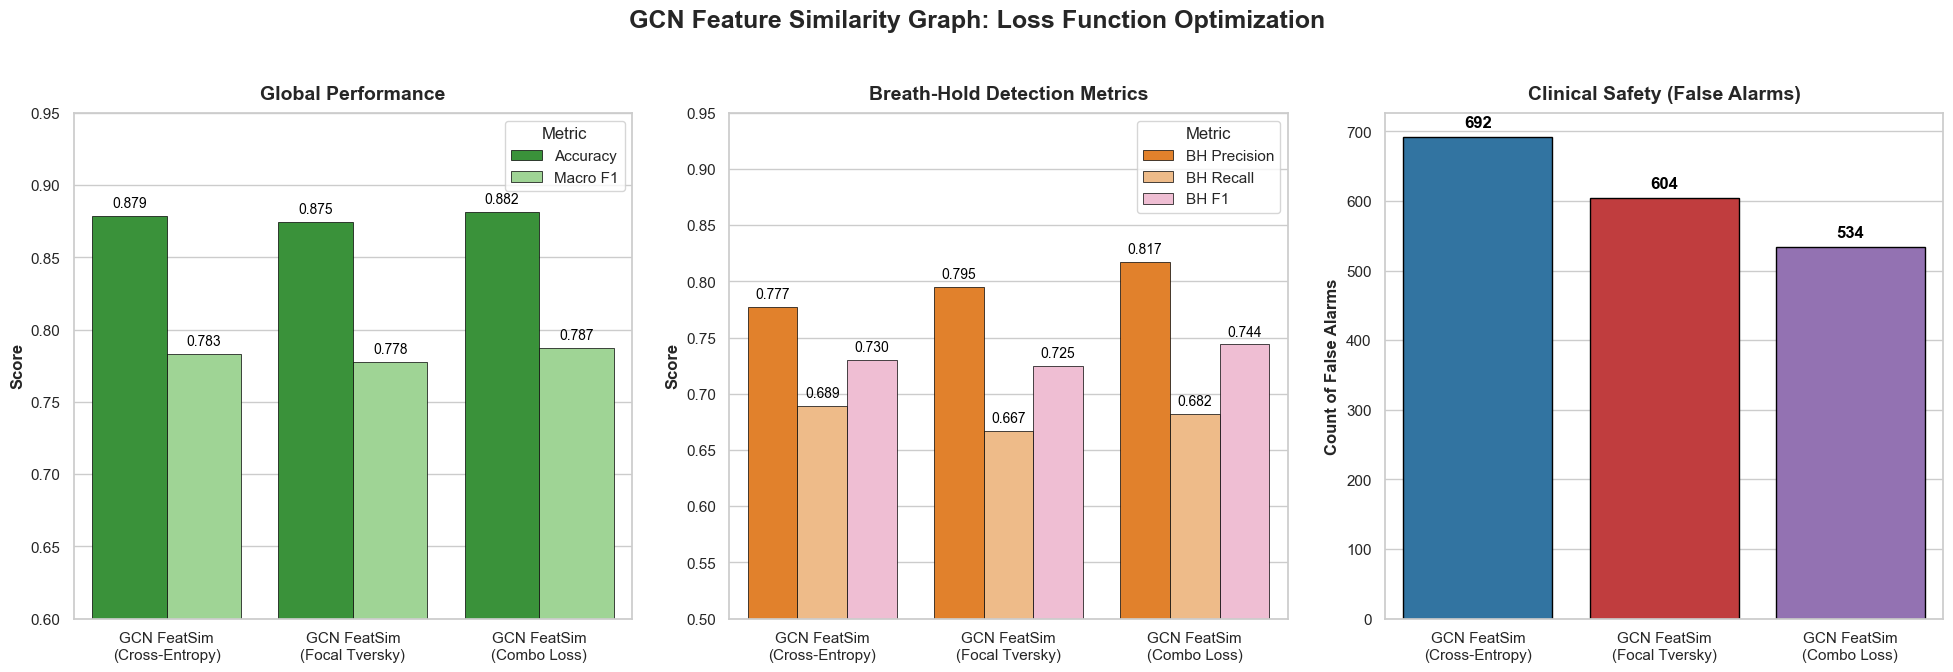

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_gcn_featsim_comprehensive():
    # Data extracted from the three GCN Feature Similarity logs
    data = {
        'Model': ['GCN FeatSim\n(Cross-Entropy)', 'GCN FeatSim\n(Focal Tversky)', 'GCN FeatSim\n(Combo Loss)'],
        'Accuracy': [0.8788, 0.8748, 0.8817],
        'Macro F1': [0.7832, 0.7777, 0.7873],
        'BH Precision': [0.777, 0.795, 0.817],
        'BH Recall': [0.689, 0.667, 0.682],
        'BH F1': [0.730, 0.725, 0.744],
        'False Alarms': [692, 604, 534] # Calculated from (NB->BH + DB->BH)
    }

    df = pd.DataFrame(data)

    # Set plotting style
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(20, 7))
    plt.suptitle('GCN Feature Similarity Graph: Loss Function Optimization', fontsize=18, fontweight='bold', y=0.98)

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 1: Overall Performance (Macro F1 & Accuracy)
    # ─────────────────────────────────────────────────────────────────────────────
    ax1 = plt.subplot(1, 3, 1)
    df_global = df[['Model', 'Accuracy', 'Macro F1']].melt(id_vars='Model', var_name='Metric', value_name='Score')
    sns.barplot(data=df_global, x='Model', y='Score', hue='Metric', palette=['#2ca02c', '#98df8a'], ax=ax1, edgecolor='black', linewidth=0.5)

    ax1.set_title('Global Performance', fontsize=14, fontweight='bold', pad=10)
    ax1.set_ylim(0.60, 0.95)
    ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax1.set_xlabel('')

    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 4), textcoords='offset points')

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 2: Breath-Hold Detection Power
    # ─────────────────────────────────────────────────────────────────────────────
    ax2 = plt.subplot(1, 3, 2)
    df_bh = df[['Model', 'BH Precision', 'BH Recall', 'BH F1']].melt(id_vars='Model', var_name='Metric', value_name='Score')
    sns.barplot(data=df_bh, x='Model', y='Score', hue='Metric', palette=['#ff7f0e', '#ffbb78', '#f7b6d2'], ax=ax2, edgecolor='black', linewidth=0.5)

    ax2.set_title('Breath-Hold Detection Metrics', fontsize=14, fontweight='bold', pad=10)
    ax2.set_ylim(0.50, 0.95)
    ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax2.set_xlabel('')

    for p in ax2.patches:
        ax2.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 4), textcoords='offset points')

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 3: Alarm Fatigue (False Alarms)
    # ─────────────────────────────────────────────────────────────────────────────
    ax3 = plt.subplot(1, 3, 3)
    sns.barplot(data=df, x='Model', y='False Alarms', palette=['#1f77b4', '#d62728', '#9467bd'], ax=ax3, edgecolor='black', linewidth=1)

    ax3.set_title('Clinical Safety (False Alarms)', fontsize=14, fontweight='bold', pad=10)
    ax3.set_ylabel('Count of False Alarms', fontsize=12, fontweight='bold')
    ax3.set_xlabel('')

    for p in ax3.patches:
        ax3.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

    plt.tight_layout(pad=2.0)
    plt.show()

if __name__ == "__main__":
    plot_gcn_featsim_comprehensive()

## GIN WITH FEATURE SIMILARITY GRAPH

Now we replace GCNConv with GINConv (Graph Isomorphism Network) for stronger expressive power with the same feature similarity edges.


In [ ]:
"""
GIN WITH FEATURE SIMILARITY GRAPH + CROSS-ENTROPY LOSS
═══════════════════════════════════════════════════════════════════════════
Graph Isomorphism Network with k-NN feature similarity edges.
Uses MLP for node aggregation (more expressive than GCNConv).
"""

from torch.nn import Sequential, BatchNorm1d, ReLU
from torch_geometric.nn import GINConv


# ─────────────────────────────────────────────────────────────────────────────
#  GIN ARCHITECTURE
# ─────────────────────────────────────────────────────────────────────────────

class ClinicalGINFeatureSimilarity(torch.nn.Module):
    def __init__(self, num_features: int, hidden_dim: int, num_classes: int):
        super().__init__()
        
        # GIN requires an MLP for aggregation (more expressive than GCNConv)
        mlp1 = Sequential(
            Linear(num_features, hidden_dim),
            BatchNorm1d(hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim),
            ReLU()
        )
        self.conv1 = GINConv(mlp1, train_eps=True)

        mlp2 = Sequential(
            Linear(hidden_dim, hidden_dim),
            BatchNorm1d(hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim),
            ReLU()
        )
        self.conv2 = GINConv(mlp2, train_eps=True)
        
        self.classifier = Linear(hidden_dim, num_classes)
        self.dropout = torch.nn.Dropout(p=0.3)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.dropout(x)
        
        x = self.conv2(x, edge_index)
        x = self.dropout(x)
        
        out = self.classifier(x)
        return out


# ─────────────────────────────────────────────────────────────────────────────
#  LOSO EVALUATION: GIN Feature Similarity + Cross-Entropy Loss
# ─────────────────────────────────────────────────────────────────────────────

def run_gin_fs_ce_loso(df: pd.DataFrame, features: list) -> None:
    subjects = sorted(df["Subject"].unique())
    all_y_true, all_y_prob, all_y_pred = [], [], []

    print("\n" + "═" * 115)
    print(f"  CLINICAL LOSO: GIN + FEATURE SIMILARITY GRAPH (k={K_NEIGHBORS_FS}) | DEVICE: {DEVICE_FS}")
    print(f"  Balanced NeighborLoader + Cross-Entropy Loss (GINConv with MLP Aggregation)")
    print("═" * 115)

    header = (
        f"  {'Sub':6s} | {'N_NB':>5} | {'N_BH':>5} | {'N_DB':>5} | "
        f"{'Acc':>5} | {'Mac_P':>5} | {'Mac_R':>5} | {'Mac_F1':>6} | "
        f"{'BH_Rec':>6} | {'BH_Pre':>6} | {'BH_F1':>6}"
    )
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:
        tr_df = df[df["Subject"] != test_sub].copy()
        te_df = df[df["Subject"] == test_sub].copy()

        if WINSORISE_FS:
            X_tr_raw = tr_df[features].values
            X_te_raw = te_df[features].values
            X_tr_w, X_te_w = winsorise_fold_fs(X_tr_raw, X_te_raw, WINSOR_LO_FS, WINSOR_HI_FS)
            tr_df.loc[:, features] = X_tr_w
            te_df.loc[:, features] = X_te_w

        scaler = StandardScaler()
        
        train_graphs = []
        for sub in tr_df["Subject"].unique():
            sub_df = tr_df[tr_df["Subject"] == sub]
            is_first = (sub == tr_df["Subject"].unique()[0])
            train_graphs.append(build_similarity_subject_graph(
                sub_df, features, scaler, is_train=is_first, 
                k_neighbors=K_NEIGHBORS_FS, bidirectional=BIDIRECTIONAL_FS
            ))
            
        test_graph = build_similarity_subject_graph(
            te_df, features, scaler, is_train=False,
            k_neighbors=K_NEIGHBORS_FS, bidirectional=BIDIRECTIONAL_FS
        ).to(DEVICE_FS)
        
        train_loader = create_balanced_loader_fs(train_graphs, BATCH_SIZE_FS)

        model = ClinicalGINFeatureSimilarity(num_features=len(features), hidden_dim=HIDDEN_DIM_FS, num_classes=3).to(DEVICE_FS)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE_FS, weight_decay=WEIGHT_DECAY_FS)
        criterion = CrossEntropyLoss().to(DEVICE_FS)

        model.train()
        for epoch in range(EPOCHS_FS):
            for batch in train_loader:
                batch = batch.to(DEVICE_FS)
                optimizer.zero_grad()
                out = model(batch.x, batch.edge_index)
                loss = criterion(out[:batch.batch_size], batch.y[:batch.batch_size])
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            out = model(test_graph.x, test_graph.edge_index)
            probs = F.softmax(out, dim=1).cpu().numpy()
            raw_preds = np.argmax(probs, axis=1)

        pred_cal = enforce_minimum_duration_fs(raw_preds, target_class=1, min_length=5)
        pred_cal = enforce_minimum_duration_fs(pred_cal, target_class=2, min_length=3)

        y_te = test_graph.y.cpu().numpy()

        n_nb = int((y_te == 0).sum())
        n_bh = int((y_te == 1).sum())
        n_db = int((y_te == 2).sum())

        acc     = accuracy_score(y_te, pred_cal)
        mac_p   = precision_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_r   = recall_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_f1  = f1_score(y_te, pred_cal, average="macro", zero_division=0)

        bh_rec  = recall_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_pre  = precision_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_f1   = f1_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]

        print(
            f"  {test_sub:6s} | {n_nb:5d} | {n_bh:5d} | {n_db:5d} | "
            f"{acc:5.3f} | {mac_p:5.3f} | {mac_r:5.3f} | {mac_f1:6.3f} | "
            f"{bh_rec:6.3f} | {bh_pre:6.3f} | {bh_f1:6.3f}"
        )

        all_y_true.extend(y_te.tolist())
        all_y_prob.extend(probs.tolist())
        all_y_pred.extend(pred_cal.tolist())

    print("  " + "─" * (len(header) - 2))

    y_true = np.array(all_y_true)
    y_prob = np.array(all_y_prob)
    y_pred = np.array(all_y_pred)

    y_bin = label_binarize(y_true, classes=CLASSES_FS)

    auroc = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    auprc = average_precision_score(y_bin, y_prob, average="macro")

    acc     = accuracy_score(y_true, y_pred)
    mac_p   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    mac_r   = recall_score(y_true, y_pred, average="macro", zero_division=0)
    mac_f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)

    bh_rec  = recall_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_pre  = precision_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_f1   = f1_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]

    db_rec  = recall_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_pre  = precision_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_f1   = f1_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]

    nb_rec  = recall_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]
    nb_pre  = precision_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]

    print()
    print("  ── GIN FEATURE SIMILARITY OVERALL RESULTS ──")
    print(f"     AUROC (OVR)     = {auroc:.4f}")
    print(f"     AUPRC           = {auprc:.4f}")
    print(f"     Accuracy        = {acc:.4f}")
    print(f"     Macro Precision = {mac_p:.4f}")
    print(f"     Macro Recall    = {mac_r:.4f}")
    print(f"     Macro F1        = {mac_f1:.4f}")
    print()
    print("  ── PER-CLASS BREAKDOWN ──")
    print(f"     NB  : Recall={nb_rec:.3f}  Precision={nb_pre:.3f}")
    print(f"     BH  : Recall={bh_rec:.3f}  Precision={bh_pre:.3f}  F1={bh_f1:.3f}")
    print(f"     DB  : Recall={db_rec:.3f}  Precision={db_pre:.3f}  F1={db_f1:.3f}")

    cm = confusion_matrix(y_true, y_pred, labels=CLASSES_FS)
    print()
    print("  ── CONFUSION MATRIX ──")
    print(f"  {'':20s}  {'Pred NB':>10}  {'Pred BH':>10}  {'Pred DB':>10}")
    for i, name in CLASS_NAMES_FS.items():
        row = cm[i]
        print(f"  Actual {name} ({i})         {row[0]:>10}  {row[1]:>10}  {row[2]:>10}")
    print("═" * 115)


# EXECUTE
if __name__ == "__main__":
    if not os.path.exists(INPUT_CSV_FS):
        raise FileNotFoundError(f"Dataset not found: {INPUT_CSV_FS}")

    df = pd.read_csv(INPUT_CSV_FS)
    df["y"] = df["Category"].map(CLASS_MAP_FS)
    features = G_LIST_FS

    print(f"  [+] Running GIN Feature Similarity + Cross-Entropy Loss...")
    run_gin_fs_ce_loso(df, features)


  [+] Running GIN Feature Similarity + Cross-Entropy Loss...

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  CLINICAL LOSO: GIN + FEATURE SIMILARITY GRAPH (k=5) | DEVICE: cpu
  Balanced NeighborLoader + Cross-Entropy Loss (GINConv with MLP Aggregation)
═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Sub    |  N_NB |  N_BH |  N_DB |   Acc | Mac_P | Mac_R | Mac_F1 | BH_Rec | BH_Pre |  BH_F1
  ──────────────────────────────────────────────────────────────────────────────────────────
  S_10   |   469 |    40 |    75 | 0.844 | 0.673 | 0.732 |  0.698 |  0.725 |  0.569 |  0.637
  S_11   |   497 |    90 |    72 | 0.750 | 0.592 | 0.695 |  0.620 |  0.956 |  0.524 |  0.677
  S_14   |   497 |    90 |    79 | 0.899 | 0.845 | 0.837 |  0.841 |  0.878 |  0.919 |  0.898
  S_15   |   512 |    90 |    71 | 0.963 | 0.932 | 0.943 |  0.933 |  0.867 |  1.000 |  0.929
  

In [ ]:
"""
GIN WITH FEATURE SIMILARITY GRAPH + FOCAL TVERSKY LOSS
═══════════════════════════════════════════════════════════════════════════
"""

def run_gin_fs_ftl_loso(df: pd.DataFrame, features: list) -> None:
    subjects = sorted(df["Subject"].unique())
    all_y_true, all_y_prob, all_y_pred = [], [], []

    print("\n" + "═" * 115)
    print(f"  CLINICAL LOSO: GIN + FEATURE SIMILARITY GRAPH (k={K_NEIGHBORS_FS}) | DEVICE: {DEVICE_FS}")
    print(f"  Balanced NeighborLoader + Focal Tversky Loss (GINConv with MLP Aggregation)")
    print("═" * 115)

    header = (
        f"  {'Sub':6s} | {'N_NB':>5} | {'N_BH':>5} | {'N_DB':>5} | "
        f"{'Acc':>5} | {'Mac_P':>5} | {'Mac_R':>5} | {'Mac_F1':>6} | "
        f"{'BH_Rec':>6} | {'BH_Pre':>6} | {'BH_F1':>6}"
    )
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:
        tr_df = df[df["Subject"] != test_sub].copy()
        te_df = df[df["Subject"] == test_sub].copy()

        if WINSORISE_FS:
            X_tr_raw = tr_df[features].values
            X_te_raw = te_df[features].values
            X_tr_w, X_te_w = winsorise_fold_fs(X_tr_raw, X_te_raw, WINSOR_LO_FS, WINSOR_HI_FS)
            tr_df.loc[:, features] = X_tr_w
            te_df.loc[:, features] = X_te_w

        scaler = StandardScaler()
        
        train_graphs = []
        for sub in tr_df["Subject"].unique():
            sub_df = tr_df[tr_df["Subject"] == sub]
            is_first = (sub == tr_df["Subject"].unique()[0])
            train_graphs.append(build_similarity_subject_graph(
                sub_df, features, scaler, is_train=is_first, 
                k_neighbors=K_NEIGHBORS_FS, bidirectional=BIDIRECTIONAL_FS
            ))
            
        test_graph = build_similarity_subject_graph(
            te_df, features, scaler, is_train=False,
            k_neighbors=K_NEIGHBORS_FS, bidirectional=BIDIRECTIONAL_FS
        ).to(DEVICE_FS)
        
        train_loader = create_balanced_loader_fs(train_graphs, BATCH_SIZE_FS)

        model = ClinicalGINFeatureSimilarity(num_features=len(features), hidden_dim=HIDDEN_DIM_FS, num_classes=3).to(DEVICE_FS)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE_FS, weight_decay=WEIGHT_DECAY_FS)
        criterion = FocalTverskyLossFS(alpha=FTL_ALPHA_FS, beta=FTL_BETA_FS, gamma=FTL_GAMMA_FS).to(DEVICE_FS)

        model.train()
        for epoch in range(EPOCHS_FS):
            for batch in train_loader:
                batch = batch.to(DEVICE_FS)
                optimizer.zero_grad()
                out = model(batch.x, batch.edge_index)
                loss = criterion(out[:batch.batch_size], batch.y[:batch.batch_size])
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            out = model(test_graph.x, test_graph.edge_index)
            probs = F.softmax(out, dim=1).cpu().numpy()
            raw_preds = np.argmax(probs, axis=1)

        pred_cal = enforce_minimum_duration_fs(raw_preds, target_class=1, min_length=5)
        pred_cal = enforce_minimum_duration_fs(pred_cal, target_class=2, min_length=3)

        y_te = test_graph.y.cpu().numpy()

        n_nb = int((y_te == 0).sum())
        n_bh = int((y_te == 1).sum())
        n_db = int((y_te == 2).sum())

        acc     = accuracy_score(y_te, pred_cal)
        mac_p   = precision_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_r   = recall_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_f1  = f1_score(y_te, pred_cal, average="macro", zero_division=0)

        bh_rec  = recall_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_pre  = precision_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_f1   = f1_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]

        print(
            f"  {test_sub:6s} | {n_nb:5d} | {n_bh:5d} | {n_db:5d} | "
            f"{acc:5.3f} | {mac_p:5.3f} | {mac_r:5.3f} | {mac_f1:6.3f} | "
            f"{bh_rec:6.3f} | {bh_pre:6.3f} | {bh_f1:6.3f}"
        )

        all_y_true.extend(y_te.tolist())
        all_y_prob.extend(probs.tolist())
        all_y_pred.extend(pred_cal.tolist())

    print("  " + "─" * (len(header) - 2))

    y_true = np.array(all_y_true)
    y_prob = np.array(all_y_prob)
    y_pred = np.array(all_y_pred)

    y_bin = label_binarize(y_true, classes=CLASSES_FS)

    auroc = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    auprc = average_precision_score(y_bin, y_prob, average="macro")

    acc     = accuracy_score(y_true, y_pred)
    mac_p   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    mac_r   = recall_score(y_true, y_pred, average="macro", zero_division=0)
    mac_f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)

    bh_rec  = recall_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_pre  = precision_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_f1   = f1_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]

    db_rec  = recall_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_pre  = precision_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_f1   = f1_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]

    nb_rec  = recall_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]
    nb_pre  = precision_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]

    print()
    print("  ── GIN FEATURE SIMILARITY + FTL OVERALL RESULTS ──")
    print(f"     AUROC (OVR)     = {auroc:.4f}")
    print(f"     AUPRC           = {auprc:.4f}")
    print(f"     Accuracy        = {acc:.4f}")
    print(f"     Macro Precision = {mac_p:.4f}")
    print(f"     Macro Recall    = {mac_r:.4f}")
    print(f"     Macro F1        = {mac_f1:.4f}")
    print()
    print("  ── PER-CLASS BREAKDOWN ──")
    print(f"     NB  : Recall={nb_rec:.3f}  Precision={nb_pre:.3f}")
    print(f"     BH  : Recall={bh_rec:.3f}  Precision={bh_pre:.3f}  F1={bh_f1:.3f}")
    print(f"     DB  : Recall={db_rec:.3f}  Precision={db_pre:.3f}  F1={db_f1:.3f}")

    cm = confusion_matrix(y_true, y_pred, labels=CLASSES_FS)
    print()
    print("  ── CONFUSION MATRIX ──")
    print(f"  {'':20s}  {'Pred NB':>10}  {'Pred BH':>10}  {'Pred DB':>10}")
    for i, name in CLASS_NAMES_FS.items():
        row = cm[i]
        print(f"  Actual {name} ({i})         {row[0]:>10}  {row[1]:>10}  {row[2]:>10}")
    print("═" * 115)


# EXECUTE
if __name__ == "__main__":
    if not os.path.exists(INPUT_CSV_FS):
        raise FileNotFoundError(f"Dataset not found: {INPUT_CSV_FS}")

    df = pd.read_csv(INPUT_CSV_FS)
    df["y"] = df["Category"].map(CLASS_MAP_FS)
    features = G_LIST_FS

    print(f"  [+] Running GIN Feature Similarity + Focal Tversky Loss...")
    run_gin_fs_ftl_loso(df, features)


  [+] Running GIN Feature Similarity + Focal Tversky Loss...

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  CLINICAL LOSO: GIN + FEATURE SIMILARITY GRAPH (k=5) | DEVICE: cpu
  Balanced NeighborLoader + Focal Tversky Loss (GINConv with MLP Aggregation)
═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Sub    |  N_NB |  N_BH |  N_DB |   Acc | Mac_P | Mac_R | Mac_F1 | BH_Rec | BH_Pre |  BH_F1
  ──────────────────────────────────────────────────────────────────────────────────────────
  S_10   |   469 |    40 |    75 | 0.887 | 0.778 | 0.793 |  0.770 |  0.500 |  0.714 |  0.588
  S_11   |   497 |    90 |    72 | 0.818 | 0.698 | 0.856 |  0.748 |  1.000 |  0.634 |  0.776
  S_14   |   497 |    90 |    79 | 0.751 | 0.613 | 0.664 |  0.628 |  0.644 |  0.604 |  0.624
  S_15   |   512 |    90 |    71 | 0.955 | 0.903 | 0.958 |  0.923 |  0.933 |  1.000 |  0.966
  

C:\Users\ejisg\AppData\Local\Temp\ipykernel_2572\291095413.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Model', y='False Alarms', palette=['#1f77b4', '#aec7e8'], ax=ax2, edgecolor='black', linewidth=1)


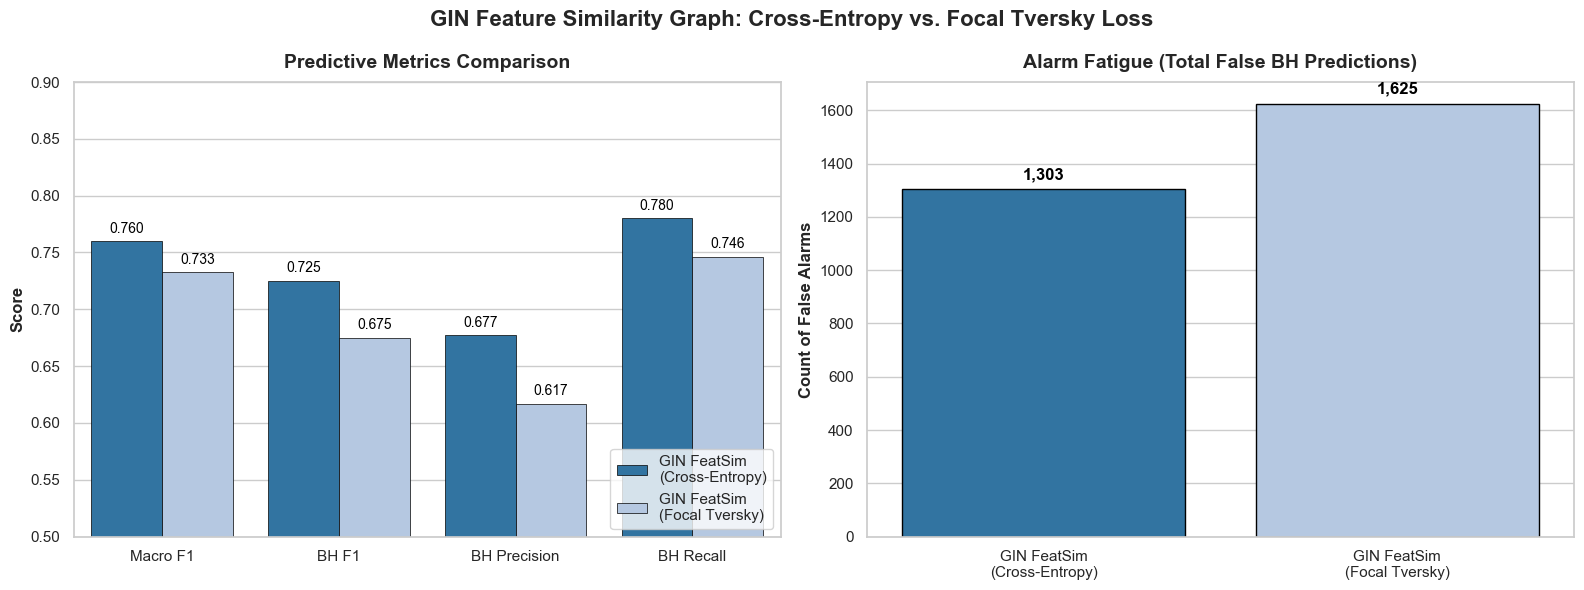

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_gin_featuresim_comparison():
    # Data extracted from the GIN Feature Similarity logs
    data = {
        'Model': ['GIN FeatSim\n(Cross-Entropy)', 'GIN FeatSim\n(Focal Tversky)'],
        'Accuracy': [0.8561, 0.8290],
        'Macro F1': [0.7598, 0.7325],
        'BH Precision': [0.677, 0.617],
        'BH Recall': [0.780, 0.746],
        'BH F1': [0.725, 0.675],
        'False Alarms': [1303, 1625] # Calculated from (NB->BH + DB->BH)
    }

    df = pd.DataFrame(data)

    # Set plotting style
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(16, 6))
    plt.suptitle('GIN Feature Similarity Graph: Cross-Entropy vs. Focal Tversky Loss', fontsize=16, fontweight='bold', y=0.98)

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 1: Predictive Metrics Comparison
    # ─────────────────────────────────────────────────────────────────────────────
    ax1 = plt.subplot(1, 2, 1)
    df_metrics = df[['Model', 'Macro F1', 'BH F1', 'BH Precision', 'BH Recall']].melt(id_vars='Model', var_name='Metric', value_name='Score')
    sns.barplot(data=df_metrics, x='Metric', y='Score', hue='Model', palette=['#1f77b4', '#aec7e8'], ax=ax1, edgecolor='black', linewidth=0.5)

    ax1.set_title('Predictive Metrics Comparison', fontsize=14, fontweight='bold', pad=10)
    ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax1.set_xlabel('')
    ax1.set_ylim(0.50, 0.90)

    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 4), textcoords='offset points')
    ax1.legend(loc='lower right')

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 2: Alarm Fatigue (False Alarms)
    # ─────────────────────────────────────────────────────────────────────────────
    ax2 = plt.subplot(1, 2, 2)
    sns.barplot(data=df, x='Model', y='False Alarms', palette=['#1f77b4', '#aec7e8'], ax=ax2, edgecolor='black', linewidth=1)

    ax2.set_title('Alarm Fatigue (Total False BH Predictions)', fontsize=14, fontweight='bold', pad=10)
    ax2.set_ylabel('Count of False Alarms', fontsize=12, fontweight='bold')
    ax2.set_xlabel('')

    for p in ax2.patches:
        ax2.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_gin_featuresim_comparison()

In [ ]:
"""
GIN WITH FEATURE SIMILARITY GRAPH + COMBO LOSS (CE + FTL)
═══════════════════════════════════════════════════════════════════════════
"""

def run_gin_fs_combo_loso(df: pd.DataFrame, features: list) -> None:
    subjects = sorted(df["Subject"].unique())
    all_y_true, all_y_prob, all_y_pred = [], [], []

    print("\n" + "═" * 115)
    print(f"  CLINICAL LOSO: GIN + FEATURE SIMILARITY GRAPH (k={K_NEIGHBORS_FS}) | DEVICE: {DEVICE_FS}")
    print(f"  Balanced NeighborLoader + Combo Loss ({int(COMBO_ALPHA_FS*100)}% CE, {int((1-COMBO_ALPHA_FS)*100)}% FTL)")
    print("═" * 115)

    header = (
        f"  {'Sub':6s} | {'N_NB':>5} | {'N_BH':>5} | {'N_DB':>5} | "
        f"{'Acc':>5} | {'Mac_P':>5} | {'Mac_R':>5} | {'Mac_F1':>6} | "
        f"{'BH_Rec':>6} | {'BH_Pre':>6} | {'BH_F1':>6}"
    )
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:
        tr_df = df[df["Subject"] != test_sub].copy()
        te_df = df[df["Subject"] == test_sub].copy()

        if WINSORISE_FS:
            X_tr_raw = tr_df[features].values
            X_te_raw = te_df[features].values
            X_tr_w, X_te_w = winsorise_fold_fs(X_tr_raw, X_te_raw, WINSOR_LO_FS, WINSOR_HI_FS)
            tr_df.loc[:, features] = X_tr_w
            te_df.loc[:, features] = X_te_w

        scaler = StandardScaler()
        
        train_graphs = []
        for sub in tr_df["Subject"].unique():
            sub_df = tr_df[tr_df["Subject"] == sub]
            is_first = (sub == tr_df["Subject"].unique()[0])
            train_graphs.append(build_similarity_subject_graph(
                sub_df, features, scaler, is_train=is_first, 
                k_neighbors=K_NEIGHBORS_FS, bidirectional=BIDIRECTIONAL_FS
            ))
            
        test_graph = build_similarity_subject_graph(
            te_df, features, scaler, is_train=False,
            k_neighbors=K_NEIGHBORS_FS, bidirectional=BIDIRECTIONAL_FS
        ).to(DEVICE_FS)
        
        train_loader = create_balanced_loader_fs(train_graphs, BATCH_SIZE_FS)

        model = ClinicalGINFeatureSimilarity(num_features=len(features), hidden_dim=HIDDEN_DIM_FS, num_classes=3).to(DEVICE_FS)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE_FS, weight_decay=WEIGHT_DECAY_FS)
        criterion = ComboLossFS(
            combo_alpha=COMBO_ALPHA_FS, 
            ftl_alpha=FTL_ALPHA_FS, 
            ftl_beta=FTL_BETA_FS, 
            ftl_gamma=FTL_GAMMA_FS
        ).to(DEVICE_FS)

        model.train()
        for epoch in range(EPOCHS_FS):
            for batch in train_loader:
                batch = batch.to(DEVICE_FS)
                optimizer.zero_grad()
                out = model(batch.x, batch.edge_index)
                loss = criterion(out[:batch.batch_size], batch.y[:batch.batch_size])
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            out = model(test_graph.x, test_graph.edge_index)
            probs = F.softmax(out, dim=1).cpu().numpy()
            raw_preds = np.argmax(probs, axis=1)

        pred_cal = enforce_minimum_duration_fs(raw_preds, target_class=1, min_length=5)
        pred_cal = enforce_minimum_duration_fs(pred_cal, target_class=2, min_length=3)

        y_te = test_graph.y.cpu().numpy()

        n_nb = int((y_te == 0).sum())
        n_bh = int((y_te == 1).sum())
        n_db = int((y_te == 2).sum())

        acc     = accuracy_score(y_te, pred_cal)
        mac_p   = precision_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_r   = recall_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_f1  = f1_score(y_te, pred_cal, average="macro", zero_division=0)

        bh_rec  = recall_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_pre  = precision_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_f1   = f1_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]

        print(
            f"  {test_sub:6s} | {n_nb:5d} | {n_bh:5d} | {n_db:5d} | "
            f"{acc:5.3f} | {mac_p:5.3f} | {mac_r:5.3f} | {mac_f1:6.3f} | "
            f"{bh_rec:6.3f} | {bh_pre:6.3f} | {bh_f1:6.3f}"
        )

        all_y_true.extend(y_te.tolist())
        all_y_prob.extend(probs.tolist())
        all_y_pred.extend(pred_cal.tolist())

    print("  " + "─" * (len(header) - 2))

    y_true = np.array(all_y_true)
    y_prob = np.array(all_y_prob)
    y_pred = np.array(all_y_pred)

    y_bin = label_binarize(y_true, classes=CLASSES_FS)

    auroc = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    auprc = average_precision_score(y_bin, y_prob, average="macro")

    acc     = accuracy_score(y_true, y_pred)
    mac_p   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    mac_r   = recall_score(y_true, y_pred, average="macro", zero_division=0)
    mac_f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)

    bh_rec  = recall_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_pre  = precision_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_f1   = f1_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]

    db_rec  = recall_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_pre  = precision_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_f1   = f1_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]

    nb_rec  = recall_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]
    nb_pre  = precision_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]

    print()
    print("  ── GIN FEATURE SIMILARITY + COMBO OVERALL RESULTS ──")
    print(f"     AUROC (OVR)     = {auroc:.4f}")
    print(f"     AUPRC           = {auprc:.4f}")
    print(f"     Accuracy        = {acc:.4f}")
    print(f"     Macro Precision = {mac_p:.4f}")
    print(f"     Macro Recall    = {mac_r:.4f}")
    print(f"     Macro F1        = {mac_f1:.4f}")
    print()
    print("  ── PER-CLASS BREAKDOWN ──")
    print(f"     NB  : Recall={nb_rec:.3f}  Precision={nb_pre:.3f}")
    print(f"     BH  : Recall={bh_rec:.3f}  Precision={bh_pre:.3f}  F1={bh_f1:.3f}")
    print(f"     DB  : Recall={db_rec:.3f}  Precision={db_pre:.3f}  F1={db_f1:.3f}")

    cm = confusion_matrix(y_true, y_pred, labels=CLASSES_FS)
    print()
    print("  ── CONFUSION MATRIX ──")
    print(f"  {'':20s}  {'Pred NB':>10}  {'Pred BH':>10}  {'Pred DB':>10}")
    for i, name in CLASS_NAMES_FS.items():
        row = cm[i]
        print(f"  Actual {name} ({i})         {row[0]:>10}  {row[1]:>10}  {row[2]:>10}")
    print("═" * 115)


# EXECUTE
if __name__ == "__main__":
    if not os.path.exists(INPUT_CSV_FS):
        raise FileNotFoundError(f"Dataset not found: {INPUT_CSV_FS}")

    df = pd.read_csv(INPUT_CSV_FS)
    df["y"] = df["Category"].map(CLASS_MAP_FS)
    features = G_LIST_FS

    print(f"  [+] Running GIN Feature Similarity + Combo Loss...")
    run_gin_fs_combo_loso(df, features)


  [+] Running GIN Feature Similarity + Combo Loss...

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  CLINICAL LOSO: GIN + FEATURE SIMILARITY GRAPH (k=5) | DEVICE: cpu
  Balanced NeighborLoader + Combo Loss (50% CE, 50% FTL)
═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Sub    |  N_NB |  N_BH |  N_DB |   Acc | Mac_P | Mac_R | Mac_F1 | BH_Rec | BH_Pre |  BH_F1
  ──────────────────────────────────────────────────────────────────────────────────────────
  S_10   |   469 |    40 |    75 | 0.866 | 0.680 | 0.761 |  0.697 |  0.825 |  0.429 |  0.564
  S_11   |   497 |    90 |    72 | 0.825 | 0.693 | 0.800 |  0.733 |  1.000 |  0.687 |  0.814
  S_14   |   497 |    90 |    79 | 0.863 | 0.751 | 0.757 |  0.754 |  0.867 |  0.821 |  0.843
  S_15   |   512 |    90 |    71 | 0.947 | 0.916 | 0.915 |  0.907 |  0.789 |  1.000 |  0.882
  S_16   |   493 |    90 |    7

C:\Users\ejisg\AppData\Local\Temp\ipykernel_2572\3573419041.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Model', y='False Alarms', palette=['#2ca02c', '#d62728', '#9467bd'], ax=ax3, edgecolor='black', linewidth=1)


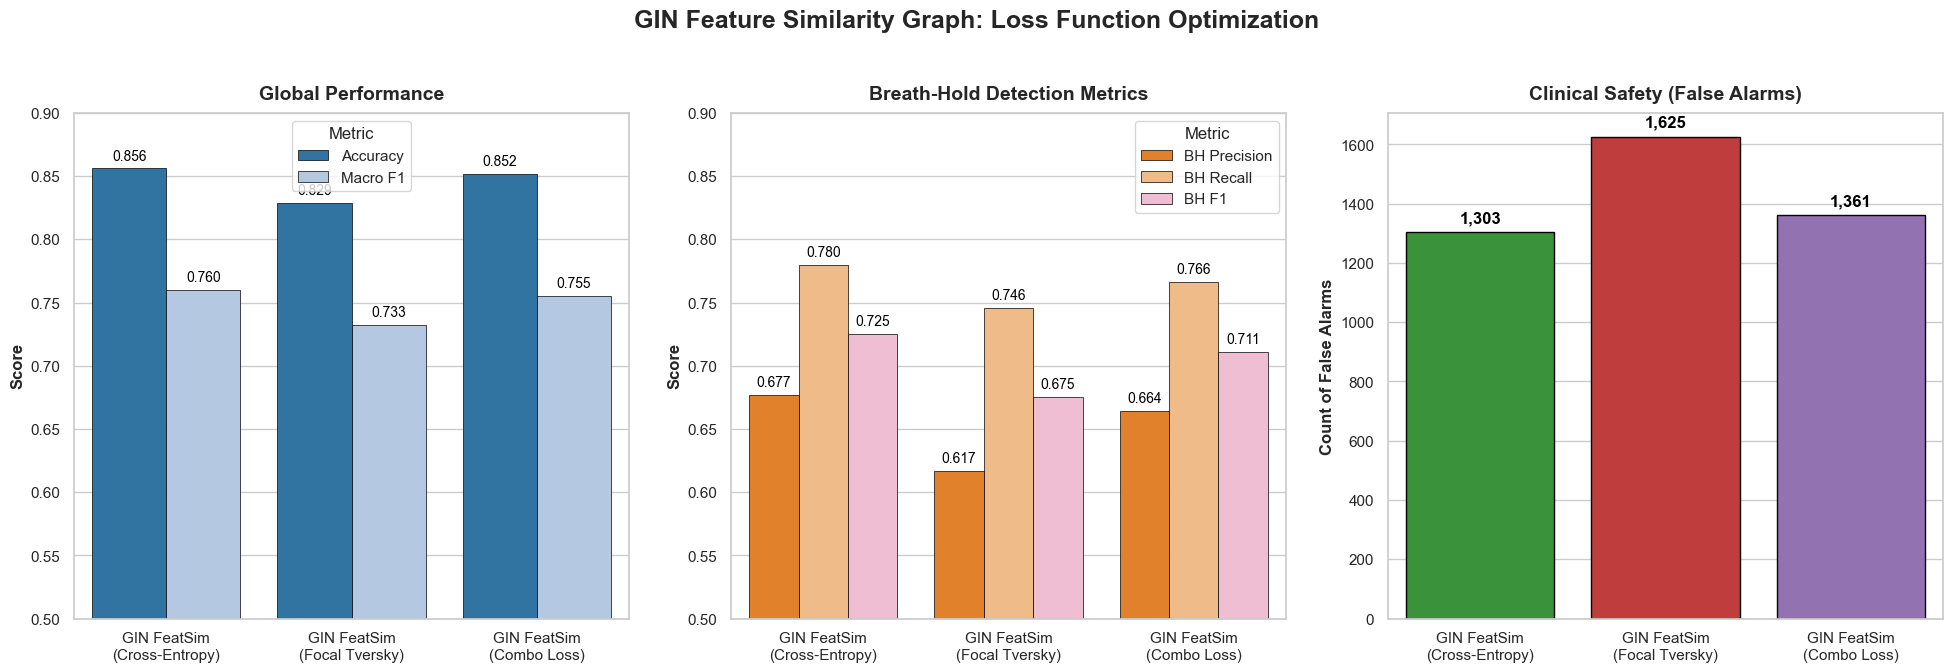

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_gin_featsim_comprehensive():
    # Data extracted exactly from your three GIN Feature Similarity logs
    data = {
        'Model': ['GIN FeatSim\n(Cross-Entropy)', 'GIN FeatSim\n(Focal Tversky)', 'GIN FeatSim\n(Combo Loss)'],
        'Accuracy': [0.8561, 0.8290, 0.8518],
        'Macro F1': [0.7598, 0.7325, 0.7553],
        'BH Precision': [0.677, 0.617, 0.664],
        'BH Recall': [0.780, 0.746, 0.766],
        'BH F1': [0.725, 0.675, 0.711],
        'False Alarms': [1303, 1625, 1361] # Calculated from (NB->BH + DB->BH)
    }

    df = pd.DataFrame(data)

    # Set plotting style
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(20, 7))
    plt.suptitle('GIN Feature Similarity Graph: Loss Function Optimization', fontsize=18, fontweight='bold', y=0.98)

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 1: Overall Performance (Macro F1 & Accuracy)
    # ─────────────────────────────────────────────────────────────────────────────
    ax1 = plt.subplot(1, 3, 1)
    df_global = df[['Model', 'Accuracy', 'Macro F1']].melt(id_vars='Model', var_name='Metric', value_name='Score')
    sns.barplot(data=df_global, x='Model', y='Score', hue='Metric', palette=['#1f77b4', '#aec7e8'], ax=ax1, edgecolor='black', linewidth=0.5)

    ax1.set_title('Global Performance', fontsize=14, fontweight='bold', pad=10)
    ax1.set_ylim(0.50, 0.90)
    ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax1.set_xlabel('')

    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 4), textcoords='offset points')

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 2: Breath-Hold Detection Power
    # ─────────────────────────────────────────────────────────────────────────────
    ax2 = plt.subplot(1, 3, 2)
    df_bh = df[['Model', 'BH Precision', 'BH Recall', 'BH F1']].melt(id_vars='Model', var_name='Metric', value_name='Score')
    sns.barplot(data=df_bh, x='Model', y='Score', hue='Metric', palette=['#ff7f0e', '#ffbb78', '#f7b6d2'], ax=ax2, edgecolor='black', linewidth=0.5)

    ax2.set_title('Breath-Hold Detection Metrics', fontsize=14, fontweight='bold', pad=10)
    ax2.set_ylim(0.50, 0.90)
    ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax2.set_xlabel('')

    for p in ax2.patches:
        ax2.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 4), textcoords='offset points')

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 3: Alarm Fatigue (False Alarms)
    # ─────────────────────────────────────────────────────────────────────────────
    ax3 = plt.subplot(1, 3, 3)
    sns.barplot(data=df, x='Model', y='False Alarms', palette=['#2ca02c', '#d62728', '#9467bd'], ax=ax3, edgecolor='black', linewidth=1)

    ax3.set_title('Clinical Safety (False Alarms)', fontsize=14, fontweight='bold', pad=10)
    ax3.set_ylabel('Count of False Alarms', fontsize=12, fontweight='bold')
    ax3.set_xlabel('')

    for p in ax3.patches:
        ax3.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

    plt.tight_layout(pad=2.0)
    plt.show()

if __name__ == "__main__":
    plot_gin_featsim_comprehensive()